In [1]:
import mplhep as hep
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

helpers_path = os.path.abspath('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))

from validation_script import run_full_validation
# Apply ROOT style via mplhep
# hep.style.use(hep.style.ROOT)

SCALER_PATH = f"Final_Dataset_ATLAS/minmax_scaler.joblib"
N_ENSEMBLE = 10
scaler = joblib.load(SCALER_PATH)

var_names = {
    'met_recalc_pt': r'$E_{\mathrm{T}}^{\mathrm{miss}}$',
    'ht': r'$H_{\mathrm{T}}$',
    'ljet1_tau21': r'Lead jet $\tau_{21}$',
    'ljet1_tau32': r'Lead jet $\tau_{32}$',
    'ljet2_tau21': r'Sublead jet $\tau_{21}$',
    'ljet2_tau32': r'Sublead jet $\tau_{32}$',
    'mjj': r'$m_{jj}$'
}

NOM_WEIGHT_COL = "final_weight"
RW_WEIGHT_COL = "rw_median_weights"
GEN_WEIGHT_COL = "total_weight"

context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']


/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Load Events
eval_dir_cr = f"Eval_CWoLa_CR_ATLAS_ver2"
eval_dir_sr = f"Eval_CWoLa_SR_ATLAS_ver2"
# Load CR events
df_data_cr = pd.read_parquet(f"{eval_dir_cr}/cr_datasets/DATA_CR_events.parquet")
df_mc_rw_cr = pd.read_parquet(f"{eval_dir_cr}/cr_datasets/MC_CR_RW_events.parquet")
df_mc_gen_cr = pd.read_parquet(f"{eval_dir_cr}/cr_datasets/MC_CR_GEN_events.parquet")
# Load SR events
df_data_sr = pd.read_parquet(f"{eval_dir_sr}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw_sr = pd.read_parquet(f"{eval_dir_sr}/scored_datasets/MC_SR_RW_scored.parquet")
df_mc_gen_sr = pd.read_parquet(f"{eval_dir_sr}/scored_datasets/MC_SR_GEN_scored.parquet")

In [3]:
def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

def signed_wasserstein_distance(u_values, v_values, u_weights, v_weights):
    """
    Computes the 1D Wasserstein distance allowing for negative weights.
    """
    # 1. Sort the values and their corresponding weights
    u_sorter = np.argsort(u_values)
    v_sorter = np.argsort(v_values)
    
    u_val_sorted = np.asarray(u_values)[u_sorter]
    v_val_sorted = np.asarray(v_values)[v_sorter]
    u_wt_sorted = np.asarray(u_weights)[u_sorter]
    v_wt_sorted = np.asarray(v_weights)[v_sorter]

    # 2. Combine all unique values to create the integration grid
    all_values = np.concatenate((u_val_sorted, v_val_sorted))
    all_values.sort(kind='mergesort')

    # 3. Compute deltas (dx for the integral)
    deltas = np.diff(all_values)

    # 4. Find the positions to evaluate the CDFs
    u_cdf_indices = np.searchsorted(u_val_sorted, all_values[:-1], side='right')
    v_cdf_indices = np.searchsorted(v_val_sorted, all_values[:-1], side='right')

    # 5. Compute the empirical CDFs (normalized by the total sum of weights)
    u_cumweights = np.concatenate(([0], np.cumsum(u_wt_sorted)))
    v_cumweights = np.concatenate(([0], np.cumsum(v_wt_sorted)))

    # Prevent division by zero if weights sum perfectly to 0
    u_total = u_cumweights[-1]
    v_total = v_cumweights[-1]
    if u_total == 0 or v_total == 0:
        raise ValueError("Total sum of weights cannot be zero.")

    u_cdf = u_cumweights[u_cdf_indices] / u_total
    v_cdf = v_cumweights[v_cdf_indices] / v_total

    # 6. Compute the integral of the absolute difference
    return np.sum(np.abs(u_cdf - v_cdf) * deltas)


### GEN and REWEIGHT VALIDATION

In [4]:
data_unscaled_cr = transform(df_data_cr, scale = False)
mc_gen_unscaled_cr = transform(df_mc_gen_cr, scale = False)
mc_rw_unscaled_cr = transform(df_mc_rw_cr, scale = False)


bounds = {
    "mjj": (0, None),
    "ljet1_tau21": (0, 1), "ljet1_tau32": (0, 1),
    "ljet2_tau21": (0, 1), "ljet2_tau32": (0, 1),
}

print("\n\n########## CASE 1: CR GEN ##########")
report_cr_gen = run_full_validation(
    data_unscaled_cr, mc_gen_unscaled_cr, weight_col=GEN_WEIGHT_COL, feature_list=features_vars,
    bounds=bounds, out_dir="VALIDATION_GEN_CR", n_classifier_runs=3)

print("\n\n########## CASE 2: CR RW ##########")
report_cr_rw = run_full_validation(
    data_unscaled_cr, mc_rw_unscaled_cr, weight_col=RW_WEIGHT_COL, feature_list=features_vars,
    bounds=bounds, out_dir="VALIDATION_RW_CR", n_classifier_runs=3)



########## CASE 1: CR GEN ##########


/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts/validation_script.py:77: UserWarning: Negative weights found in column 'total_weight'; 55712 events affected.
  warnings.warn(f"Negative weights found in column '{weight_col}'; "
/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts/validation_script.py:77: UserWarning: Negative weights found in column 'total_weight'; 55712 events affected.
  warnings.warn(f"Negative weights found in column '{weight_col}'; "


GEN VALIDATION SUMMARY

[1] Physical bounds: OK

[2] Marginal shape (weighted KS test, per feature):
         ljet1_tau21: KS p=0.0256  Wasserstein(norm)=0.0151  tail ratio(gen/data)=0.939  [OK]
         ljet1_tau32: KS p=0.5300  Wasserstein(norm)=0.0180  tail ratio(gen/data)=1.045  [OK]
         ljet2_tau21: KS p=0.0041  Wasserstein(norm)=0.0217  tail ratio(gen/data)=0.930  [WARN]
         ljet2_tau32: KS p=0.1286  Wasserstein(norm)=0.0228  tail ratio(gen/data)=1.002  [OK]
                 mjj: KS p=0.0000  Wasserstein(norm)=0.0248  tail ratio(gen/data)=1.052  [FAIL]

[3] Correlations: max |corr_gen - corr_data)| = 0.046  [OK]

[4] Classifier two-sample test: AUC = 0.533 +/- 0.002 (0.5 = indistinguishable)  [OK]
      per-feature AUC               mjj: 0.520
      per-feature AUC       ljet2_tau21: 0.509
      per-feature AUC       ljet2_tau32: 0.506
      per-feature AUC       ljet1_tau21: 0.505
      per-feature AUC       ljet1_tau32: 0.498

[5] Weight diagnostics: effective sample 

/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts/validation_script.py:77: UserWarning: Negative weights found in column 'rw_median_weights'; 5603 events affected.
  warnings.warn(f"Negative weights found in column '{weight_col}'; "
/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts/validation_script.py:77: UserWarning: Negative weights found in column 'rw_median_weights'; 5603 events affected.
  warnings.warn(f"Negative weights found in column '{weight_col}'; "


GEN VALIDATION SUMMARY

[1] Physical bounds: OK

[2] Marginal shape (weighted KS test, per feature):
         ljet1_tau21: KS p=0.1022  Wasserstein(norm)=0.0213  tail ratio(gen/data)=0.974  [OK]
         ljet1_tau32: KS p=0.0032  Wasserstein(norm)=0.0352  tail ratio(gen/data)=1.155  [WARN]
         ljet2_tau21: KS p=0.6564  Wasserstein(norm)=0.0076  tail ratio(gen/data)=0.980  [OK]
         ljet2_tau32: KS p=0.0395  Wasserstein(norm)=0.0366  tail ratio(gen/data)=1.136  [OK]
                 mjj: KS p=0.0000  Wasserstein(norm)=0.0479  tail ratio(gen/data)=1.089  [FAIL]

[3] Correlations: max |corr_gen - corr_data)| = 0.018  [OK]

[4] Classifier two-sample test: AUC = 0.519 +/- 0.002 (0.5 = indistinguishable)  [OK]
      per-feature AUC       ljet1_tau32: 0.515
      per-feature AUC               mjj: 0.509
      per-feature AUC       ljet2_tau32: 0.504
      per-feature AUC       ljet2_tau21: 0.503
      per-feature AUC       ljet1_tau21: 0.491

[5] Weight diagnostics: effective sample 

In [5]:
data_unscaled_sr = transform(df_data_sr, scale = False)
mc_gen_unscaled_sr = transform(df_mc_gen_sr, scale = False)
mc_rw_unscaled_sr = transform(df_mc_rw_sr, scale = False)


bounds = {
    "mjj": (0, None),
    "ljet1_tau21": (0, 1), "ljet1_tau32": (0, 1),
    "ljet2_tau21": (0, 1), "ljet2_tau32": (0, 1),
}

print("\n\n########## CASE 1: SR GEN ##########")
report_sr_gen = run_full_validation(
    data_unscaled_sr, mc_gen_unscaled_sr, weight_col=GEN_WEIGHT_COL, feature_list=features_vars,
    bounds=bounds, out_dir="VALIDATION_GEN_SR", n_classifier_runs=3)

print("\n\n########## CASE 2: SR RW ##########")
report_sr_rw = run_full_validation(
    data_unscaled_sr, mc_rw_unscaled_sr, weight_col=RW_WEIGHT_COL, feature_list=features_vars,
    bounds=bounds, out_dir="VALIDATION_RW_SR", n_classifier_runs=3)



########## CASE 1: SR GEN ##########


/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts/validation_script.py:77: UserWarning: Negative weights found in column 'total_weight'; 306875 events affected.
  warnings.warn(f"Negative weights found in column '{weight_col}'; "
/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts/validation_script.py:77: UserWarning: Negative weights found in column 'total_weight'; 306875 events affected.
  warnings.warn(f"Negative weights found in column '{weight_col}'; "


GEN VALIDATION SUMMARY

[1] Physical bounds: OK

[2] Marginal shape (weighted KS test, per feature):
         ljet1_tau21: KS p=0.0000  Wasserstein(norm)=0.0157  tail ratio(gen/data)=1.002  [FAIL]
         ljet1_tau32: KS p=0.0000  Wasserstein(norm)=0.0430  tail ratio(gen/data)=1.010  [FAIL]
         ljet2_tau21: KS p=0.0000  Wasserstein(norm)=0.0274  tail ratio(gen/data)=0.931  [FAIL]
         ljet2_tau32: KS p=0.0000  Wasserstein(norm)=0.0481  tail ratio(gen/data)=1.028  [FAIL]
                 mjj: KS p=0.0000  Wasserstein(norm)=0.0159  tail ratio(gen/data)=1.035  [FAIL]

[3] Correlations: max |corr_gen - corr_data)| = 0.077  [WARN]

[4] Classifier two-sample test: AUC = 0.550 +/- 0.001 (0.5 = indistinguishable)  [OK]
      per-feature AUC               mjj: 0.522
      per-feature AUC       ljet2_tau21: 0.511
      per-feature AUC       ljet2_tau32: 0.510
      per-feature AUC       ljet1_tau32: 0.508
      per-feature AUC       ljet1_tau21: 0.507

[5] Weight diagnostics: effective

/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts/validation_script.py:77: UserWarning: Negative weights found in column 'rw_median_weights'; 30850 events affected.
  warnings.warn(f"Negative weights found in column '{weight_col}'; "
/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts/validation_script.py:77: UserWarning: Negative weights found in column 'rw_median_weights'; 30850 events affected.
  warnings.warn(f"Negative weights found in column '{weight_col}'; "


GEN VALIDATION SUMMARY

[1] Physical bounds: OK

[2] Marginal shape (weighted KS test, per feature):
         ljet1_tau21: KS p=0.1477  Wasserstein(norm)=0.0062  tail ratio(gen/data)=1.057  [OK]
         ljet1_tau32: KS p=0.0000  Wasserstein(norm)=0.0247  tail ratio(gen/data)=1.151  [FAIL]
         ljet2_tau21: KS p=0.0000  Wasserstein(norm)=0.0227  tail ratio(gen/data)=1.096  [FAIL]
         ljet2_tau32: KS p=0.0000  Wasserstein(norm)=0.0298  tail ratio(gen/data)=1.180  [FAIL]
                 mjj: KS p=0.0000  Wasserstein(norm)=0.0199  tail ratio(gen/data)=1.020  [FAIL]

[3] Correlations: max |corr_gen - corr_data)| = 0.013  [OK]

[4] Classifier two-sample test: AUC = 0.526 +/- 0.000 (0.5 = indistinguishable)  [OK]
      per-feature AUC       ljet2_tau32: 0.515
      per-feature AUC       ljet1_tau32: 0.513
      per-feature AUC               mjj: 0.507
      per-feature AUC       ljet2_tau21: 0.506
      per-feature AUC       ljet1_tau21: 0.501

[5] Weight diagnostics: effective sam

In [6]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

### W1 Distance

In [ ]:
# Data
w1_cr_results = pd.read_csv("Results/w1_cr_results.csv")
w1_sr_results = pd.read_csv("Results/w1_sr_results.csv")

w1_cr_results = w1_cr_results.set_index('Unnamed: 0').to_dict(orient='index')
w1_sr_results = w1_sr_results.set_index('Unnamed: 0').to_dict(orient='index')
# Proper Variable Naming

variables = list(w1_cr_results['nom'].keys())
formatted_vars = [var_names[v] for v in variables]

# Calculate Deltas
records_delta = []
for region_name, results_dict in [('CR', w1_cr_results), ('SR', w1_sr_results)]:
    for var in variables:
        nom_val = results_dict['nom'][var]
        records_delta.append({'Region': region_name, 'Variable': var_names[var], 'Method': 'Reweight', 'DeltaW1': results_dict['rw'][var] - nom_val})
        records_delta.append({'Region': region_name, 'Variable': var_names[var], 'Method': 'Generate', 'DeltaW1': results_dict['gen'][var] - nom_val})
df_delta = pd.DataFrame(records_delta)

bound = max(abs(df_delta['DeltaW1'].min()), abs(df_delta['DeltaW1'].max())) * 1.05

fig, (ax_cr, ax_sr) = plt.subplots(1, 2, figsize=(16, 8), sharey=True, gridspec_kw={'wspace': 0.03})

def draw_panel(region, title, ax, show_cbar):
    df_pivot = df_delta[df_delta['Region'] == region].pivot(index='Variable', columns='Method', values='DeltaW1')
    df_pivot = df_pivot.reindex(formatted_vars)
    df_pivot = df_pivot[['Generate', 'Reweight']] # Enforce order
    
    sns.heatmap(df_pivot, annot=True, cmap='coolwarm', center=0, fmt=".4f",
                vmin=-bound, vmax=bound, linewidths=1.5, linecolor='black',
                cbar=show_cbar, ax=ax, annot_kws={'fontsize': 15})
    
    ax.set_title(title, pad=20, fontsize=24)
    ax.set_ylabel("")
    ax.set_xlabel("")

show_colorbar = True
draw_panel('CR', "Control Region", ax_cr, False)
draw_panel('SR', "Signal Region", ax_sr, True)

# Adjust colorbar
cbar = ax_sr.collections[0].colorbar
cbar.set_label(r'$\Delta W_1$ (Modification $-$ Nominal)', fontsize=22, labelpad=20)
cbar.ax.tick_params(labelsize=18)

plt.savefig("Results/w1_delta_heatmap.pdf", bbox_inches='tight')

### Correlation Plot

In [ ]:
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wasserstein_distance
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier


# ============================================================
# BASIC HELPERS
# ============================================================

def _check_data_columns(df, feature_list, name="data_events"):
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"{name} must be a pandas DataFrame.")

    missing = [c for c in feature_list if c not in df.columns]

    if missing:
        raise ValueError(
            f"{name} is missing feature columns: {missing}"
        )


def _check_gen_columns(
    df,
    feature_list,
    weight_col,
    name="gen_events"
):
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"{name} must be a pandas DataFrame.")

    required = list(feature_list) + [weight_col]

    missing = [c for c in required if c not in df.columns]

    if missing:
        raise ValueError(
            f"{name} is missing required columns: {missing}"
        )


def _clean_data_sample(
    df,
    feature_list
):
    """
    DATA has implicit unit weight = 1.
    """

    out = df[feature_list].copy()

    finite_mask = np.isfinite(
        out.to_numpy(dtype=float)
    ).all(axis=1)

    n_before = len(out)

    out = out.loc[
        finite_mask
    ].copy()

    weights = np.ones(
        len(out),
        dtype=float
    )

    info = {
        "n_before": int(n_before),
        "n_after": int(len(out)),
        "removed_nonfinite": int(
            n_before - len(out)
        ),
        "sum_weights": float(
            weights.sum()
        ),
        "effective_n": float(
            len(out)
        ),
        "has_negative_weights": False,
    }

    return out, weights, info


def _clean_gen_sample(
    df,
    feature_list,
    weight_col
):
    """
    GENERATED events can have signed weights.
    """

    cols = list(feature_list) + [weight_col]

    out = df[cols].copy()

    finite_mask = np.isfinite(
        out.to_numpy(dtype=float)
    ).all(axis=1)

    n_before = len(out)

    out = out.loc[
        finite_mask
    ].copy()

    weights = out[
        weight_col
    ].to_numpy(dtype=float)

    if len(weights) == 0:
        raise ValueError(
            "GEN sample contains no finite events."
        )

    positive_mask = weights > 0
    negative_mask = weights < 0
    zero_mask = weights == 0

    sum_w = np.sum(weights)
    sum_abs_w = np.sum(np.abs(weights))

    if sum_abs_w <= 0:
        raise ValueError(
            "GEN sample has zero total absolute weight."
        )

    # Signed-weight effective N.
    # This is a diagnostic quantity, not a probability-sample N_eff.
    effective_n_signed = (
        sum_w ** 2
        /
        np.sum(weights ** 2)
        if np.sum(weights ** 2) > 0
        else 0.0
    )

    info = {
        "n_before": int(n_before),
        "n_after": int(len(out)),
        "removed_nonfinite": int(
            n_before - len(out)
        ),

        "n_positive_weight": int(
            np.sum(positive_mask)
        ),

        "n_negative_weight": int(
            np.sum(negative_mask)
        ),

        "n_zero_weight": int(
            np.sum(zero_mask)
        ),

        "fraction_positive_weight_events": float(
            np.mean(positive_mask)
        ),

        "fraction_negative_weight_events": float(
            np.mean(negative_mask)
        ),

        "sum_weights": float(sum_w),

        "sum_absolute_weights": float(
            sum_abs_w
        ),

        "cancellation_factor": float(
            abs(sum_w) / sum_abs_w
        ),

        "effective_n_signed": float(
            effective_n_signed
        ),

        "has_negative_weights": bool(
            np.any(negative_mask)
        ),
    }

    return out, weights, info


# ============================================================
# WEIGHT HELPERS
# ============================================================

def _normalize_positive_weights(w):
    """
    Normalize non-negative weights to sum to 1.
    """
    w = np.asarray(w, dtype=float)

    if np.any(w < 0):
        raise ValueError(
            "This operation requires non-negative weights."
        )

    total = np.sum(w)

    if total <= 0:
        raise ValueError(
            "Total weight must be positive."
        )

    return w / total


def _weighted_mean(
    x,
    w
):
    """
    Works with signed weights.

    This is a signed-weight expectation:
        sum(w x) / sum(w)

    It should only be interpreted when sum(w) is sensible.
    """

    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    denominator = np.sum(w)

    if np.isclose(denominator, 0):
        return np.nan

    return float(
        np.sum(w * x) / denominator
    )


def _weighted_variance_signed(
    x,
    w
):
    """
    Signed-weight variance diagnostic.
    """
    mu = _weighted_mean(x, w)

    if not np.isfinite(mu):
        return np.nan

    denominator = np.sum(w)

    if np.isclose(denominator, 0):
        return np.nan

    variance = (
        np.sum(
            w * (x - mu) ** 2
        )
        /
        denominator
    )

    return float(variance)


def _weighted_std_signed(
    x,
    w
):
    variance = _weighted_variance_signed(
        x,
        w
    )

    if not np.isfinite(variance):
        return np.nan

    if variance < 0:
        return np.nan

    return float(
        np.sqrt(variance)
    )


def _weighted_quantile_positive(
    x,
    w,
    q
):
    """
    Quantile requiring non-negative weights.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    if np.any(w < 0):
        raise ValueError(
            "Weighted quantiles require non-negative weights."
        )

    order = np.argsort(x)

    x = x[order]
    w = w[order]

    cumulative = np.cumsum(w)

    total = cumulative[-1]

    if total <= 0:
        return np.nan

    cumulative /= total

    return float(
        np.interp(
            q,
            cumulative,
            x
        )
    )


def _weighted_corr_signed(
    x,
    y,
    w
):
    """
    Signed-weight Pearson correlation diagnostic.
    """
    denominator = np.sum(w)

    if np.isclose(denominator, 0):
        return np.nan

    mx = _weighted_mean(x, w)
    my = _weighted_mean(y, w)

    cov = np.sum(
        w
        * (x - mx)
        * (y - my)
    ) / denominator

    vx = np.sum(
        w
        * (x - mx) ** 2
    ) / denominator

    vy = np.sum(
        w
        * (y - my) ** 2
    ) / denominator

    denom = np.sqrt(
        vx * vy
    )

    if denom <= 0 or not np.isfinite(denom):
        return np.nan

    return float(
        cov / denom
    )


def _weighted_spearman_positive(
    x,
    y,
    w
):
    """
    Spearman correlation using absolute weights
    when signed weights are present.
    """
    rx = pd.Series(x).rank(
        method="average"
    ).to_numpy()

    ry = pd.Series(y).rank(
        method="average"
    ).to_numpy()

    return _weighted_corr_signed(
        rx,
        ry,
        np.abs(w)
    )


def _weighted_covariance_signed(
    X,
    w
):
    """
    Signed-weight covariance matrix.
    """

    denominator = np.sum(w)

    if np.isclose(denominator, 0):
        return np.full(
            (X.shape[1], X.shape[1]),
            np.nan
        )

    mean = np.sum(
        X * w[:, None],
        axis=0
    ) / denominator

    Xc = X - mean

    return (
        Xc * w[:, None]
    ).T @ Xc / denominator


# ============================================================
# POSITIVE-WEIGHT METRICS
# ============================================================

def _weighted_cdf(
    x,
    w,
    grid
):
    """
    CDF requiring non-negative weights.
    """

    w = np.asarray(w, dtype=float)

    if np.any(w < 0):
        raise ValueError(
            "CDF requires non-negative weights."
        )

    order = np.argsort(x)

    x_sorted = np.asarray(x)[order]
    w_sorted = w[order]

    cumulative = np.cumsum(
        w_sorted
    )

    total = cumulative[-1]

    if total <= 0:
        return np.zeros_like(
            grid,
            dtype=float
        )

    cumulative /= total

    return np.interp(
        grid,
        x_sorted,
        cumulative,
        left=0.0,
        right=1.0
    )


def _weighted_ks(
    x1,
    w1,
    x2,
    w2,
    n_grid=2000
):
    """
    Weighted KS statistic.

    Requires non-negative weights.
    """

    q_grid = np.linspace(
        0,
        1,
        n_grid
    )

    grid = np.unique(
        np.concatenate([
            np.quantile(
                x1,
                q_grid
            ),
            np.quantile(
                x2,
                q_grid
            )
        ])
    )

    cdf1 = _weighted_cdf(
        x1,
        w1,
        grid
    )

    cdf2 = _weighted_cdf(
        x2,
        w2,
        grid
    )

    return float(
        np.max(
            np.abs(
                cdf1 - cdf2
            )
        )
    )


def _hist_probability(
    values,
    weights,
    bins
):
    """
    Histogram normalized to probability.

    Requires non-negative weights.
    """

    hist, _ = np.histogram(
        values,
        bins=bins,
        weights=weights
    )

    total = np.sum(
        hist
    )

    if total <= 0:
        return np.zeros_like(
            hist,
            dtype=float
        )

    return hist / total


def _js_divergence(
    p,
    q,
    eps=1e-12
):
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps

    p /= p.sum()
    q /= q.sum()

    m = 0.5 * (
        p + q
    )

    return float(
        0.5
        * np.sum(
            p * np.log(
                p / m
            )
        )
        +
        0.5
        * np.sum(
            q * np.log(
                q / m
            )
        )
    )


# ============================================================
# SAMPLING
# ============================================================

def _sample_for_classifier(
    df,
    weights,
    max_events,
    random_state
):
    """
    Select events for plotting/classification.

    Uses absolute weights for signed-weight GEN samples.
    """

    if len(df) <= max_events:
        return (
            df.copy(),
            np.asarray(
                weights,
                dtype=float
            )
        )

    abs_weights = np.abs(
        np.asarray(
            weights,
            dtype=float
        )
    )

    if np.sum(abs_weights) <= 0:
        probabilities = None
    else:
        probabilities = (
            abs_weights
            /
            abs_weights.sum()
        )

    rng = np.random.default_rng(
        random_state
    )

    indices = rng.choice(
        len(df),
        size=max_events,
        replace=False,
        p=probabilities
    )

    return (
        df.iloc[indices].copy(),
        np.asarray(
            weights,
            dtype=float
        )[indices]
    )


# ============================================================
# MAIN VALIDATION FUNCTION
# ============================================================

def validate_generate_events(
    data_events,
    gen_events,
    weight_col,
    feature_list,
    n_bins=50,
    conditional_bins=5,
    classifier_max_events=100_000,
    plot_max_events=100_000,
    random_state=42,
    make_plots=True,
    classifier=True,
):
    """
    Comprehensive validation of GENERATE against DATA.

    ------------------------------------------------------------
    DATA
    ------------------------------------------------------------

    Every DATA event has implicit weight:

        w_data = 1

    ------------------------------------------------------------
    GENERATE
    ------------------------------------------------------------

    GEN events use `weight_col`.

    Signed GEN weights are allowed.

    Distribution metrics requiring positive weights
    (KS, Wasserstein, quantiles, JS) are calculated using
    ABSOLUTE GEN weights when signed weights are present.

    Signed-weight observables (mean, covariance, histogram yield)
    retain the actual signed weights.

    ------------------------------------------------------------
    IMPORTANT
    ------------------------------------------------------------

    Using abs(weights) for shape metrics is a diagnostic choice.
    It is NOT equivalent to treating signed-weight events as an
    ordinary probability distribution.

    """

    # ========================================================
    # 1. INPUT VALIDATION
    # ========================================================

    _check_data_columns(
        data_events,
        feature_list,
        "data_events"
    )

    _check_gen_columns(
        gen_events,
        feature_list,
        weight_col,
        "gen_events"
    )

    if len(feature_list) == 0:
        raise ValueError(
            "feature_list cannot be empty."
        )

    # ========================================================
    # 2. CLEAN SAMPLES
    # ========================================================

    data, wd, data_info = (
        _clean_data_sample(
            data_events,
            feature_list
        )
    )

    gen, wg, gen_info = (
        _clean_gen_sample(
            gen_events,
            feature_list,
            weight_col
        )
    )

    # Positive weights used only for probability metrics.
    wg_abs = np.abs(wg)

    # Data are already positive.
    wd_positive = wd.copy()

    results = {

        "input": {
            "features": feature_list,
            "weight_column": weight_col,
            "data_weight_definition":
                "1 per event",
        },

        "sample_information": {
            "data": data_info,
            "generated": gen_info,
        },

        "sanity_checks": {},
        "univariate": {},
        "pairwise": {},
        "conditional": {},
        "multivariate": {},
        "classifier": {},
        "warnings": [],
    }

    # ========================================================
    # 3. WEIGHT DIAGNOSTICS
    # ========================================================

    results[
        "sanity_checks"
    ]["weights"] = {

        "data": {
            "all_weights_equal_one": True,
            "sum_weights": float(
                wd.sum()
            ),
        },

        "generated": {
            "contains_negative_weights":
                bool(
                    np.any(wg < 0)
                ),

            "sum_signed_weights":
                float(
                    wg.sum()
                ),

            "sum_absolute_weights":
                float(
                    np.abs(wg).sum()
                ),

            "cancellation_factor":
                float(
                    abs(wg.sum())
                    /
                    max(
                        np.abs(wg).sum(),
                        1e-12
                    )
                ),
        }
    }

    if np.any(wg < 0):
        results["warnings"].append(
            "GEN contains signed event weights. "
            "Probability-based metrics (KS, Wasserstein, "
            "quantiles, JS) use |weight| for GEN. "
            "Signed-weight quantities are reported separately."
        )

    # ========================================================
    # 4. PHYSICAL / NUMERICAL SANITY CHECKS
    # ========================================================

    physical = {}

    for feature in feature_list:

        d = data[
            feature
        ].to_numpy(dtype=float)

        g = gen[
            feature
        ].to_numpy(dtype=float)

        feature_lower = feature.lower()

        checks = {

            "data_min":
                float(np.min(d)),

            "data_max":
                float(np.max(d)),

            "generated_min":
                float(np.min(g)),

            "generated_max":
                float(np.max(g)),
        }

        # ----------------------------------------------------
        # m_jj
        # ----------------------------------------------------

        if feature_lower in [
            "m_jj",
            "mjj",
            "dijet_mass",
            "mass",
        ]:

            checks[
                "data_negative_fraction"
            ] = (
                np.sum(
                    wd[d < 0]
                )
                /
                wd.sum()
            )

            checks[
                "generated_negative_signed_yield"
            ] = (
                np.sum(
                    wg[g < 0]
                )
                /
                max(
                    abs(wg.sum()),
                    1e-12
                )
            )

        # ----------------------------------------------------
        # N-subjettiness
        # ----------------------------------------------------

        if feature_lower in [
            "tau21",
            "tau_21",
            "tau32",
            "tau_32",
        ]:

            checks[
                "data_below_zero_fraction"
            ] = (
                np.sum(
                    wd[d < 0]
                )
                /
                wd.sum()
            )

            checks[
                "data_above_one_fraction"
            ] = (
                np.sum(
                    wd[d > 1]
                )
                /
                wd.sum()
            )

            # Signed GEN:
            # report both event fraction and signed yield.
            checks[
                "generated_below_zero_event_fraction"
            ] = float(
                np.mean(
                    g < 0
                )
            )

            checks[
                "generated_above_one_event_fraction"
            ] = float(
                np.mean(
                    g > 1
                )
            )

            checks[
                "generated_below_zero_abs_weight_fraction"
            ] = float(
                np.sum(
                    wg_abs[g < 0]
                )
                /
                max(
                    wg_abs.sum(),
                    1e-12
                )
            )

            checks[
                "generated_above_one_abs_weight_fraction"
            ] = float(
                np.sum(
                    wg_abs[g > 1]
                )
                /
                max(
                    wg_abs.sum(),
                    1e-12
                )
            )

        # ----------------------------------------------------
        # Empirical support
        # ----------------------------------------------------

        empirical_outside = (
            (g < np.min(d))
            |
            (g > np.max(d))
        )

        checks[
            "generated_outside_empirical_data_support"
        ] = float(
            np.sum(
                wg_abs[
                    empirical_outside
                ]
            )
            /
            max(
                wg_abs.sum(),
                1e-12
            )
        )

        physical[
            feature
        ] = checks

    results[
        "sanity_checks"
    ]["physical"] = physical

    # ========================================================
    # 5. UNIVARIATE VALIDATION
    # ========================================================

    for feature in feature_list:

        d = data[
            feature
        ].to_numpy(dtype=float)

        g = gen[
            feature
        ].to_numpy(dtype=float)

        # DATA-defined bins
        bins = np.quantile(
            d,
            np.linspace(
                0,
                1,
                n_bins + 1
            )
        )

        bins = np.unique(
            bins
        )

        if len(bins) < 3:
            results["warnings"].append(
                f"{feature}: insufficient unique values."
            )
            continue

        # Probability metrics
        p_data = _hist_probability(
            d,
            wd_positive,
            bins
        )

        p_gen = _hist_probability(
            g,
            wg_abs,
            bins
        )

        js = _js_divergence(
            p_data,
            p_gen
        )

        ks = _weighted_ks(
            d,
            wd_positive,
            g,
            wg_abs
        )

        wasserstein = (
            wasserstein_distance(
                d,
                g,
                u_weights=wd_positive,
                v_weights=wg_abs
            )
        )

        # Signed moments
        mean_data = _weighted_mean(
            d,
            wd
        )

        mean_gen_signed = _weighted_mean(
            g,
            wg
        )

        std_data = _weighted_std_signed(
            d,
            wd
        )

        std_gen_signed = _weighted_std_signed(
            g,
            wg
        )

        # Absolute-weight moments for shape
        mean_gen_abs = _weighted_mean(
            g,
            wg_abs
        )

        std_gen_abs = _weighted_std_signed(
            g,
            wg_abs
        )

        # Quantiles
        q_levels = [
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]

        q_data = {
            str(q):
                _weighted_quantile_positive(
                    d,
                    wd,
                    q
                )
            for q in q_levels
        }

        q_gen = {
            str(q):
                _weighted_quantile_positive(
                    g,
                    wg_abs,
                    q
                )
            for q in q_levels
        }

        # Tail tests
        tail_results = {}

        for q in [
            0.90,
            0.95,
            0.99
        ]:

            threshold = (
                _weighted_quantile_positive(
                    d,
                    wd,
                    q
                )
            )

            data_fraction = (
                np.sum(
                    wd[
                        d > threshold
                    ]
                )
                /
                wd.sum()
            )

            gen_abs_fraction = (
                np.sum(
                    wg_abs[
                        g > threshold
                    ]
                )
                /
                max(
                    wg_abs.sum(),
                    1e-12
                )
            )

            gen_signed_fraction = (
                np.sum(
                    wg[
                        g > threshold
                    ]
                )
                /
                max(
                    abs(
                        wg.sum()
                    ),
                    1e-12
                )
            )

            tail_results[
                f"above_data_{int(q*100)}percentile"
            ] = {

                "threshold":
                    float(threshold),

                "data_fraction":
                    float(data_fraction),

                "generated_absolute_weight_fraction":
                    float(
                        gen_abs_fraction
                    ),

                "generated_signed_weight_fraction":
                    float(
                        gen_signed_fraction
                    ),

                "absolute_weight_ratio":
                    float(
                        gen_abs_fraction
                        /
                        max(
                            data_fraction,
                            1e-12
                        )
                    ),
            }

        results[
            "univariate"
        ][feature] = {

            "data": {

                "mean":
                    mean_data,

                "std":
                    std_data,

                "median":
                    q_data["0.5"],

                "quantiles":
                    q_data,
            },

            "generated_signed": {

                "mean":
                    mean_gen_signed,

                "std":
                    std_gen_signed,
            },

            "generated_absolute_weight_shape": {

                "mean":
                    mean_gen_abs,

                "std":
                    std_gen_abs,

                "quantiles":
                    q_gen,
            },

            "comparison": {

                "weighted_KS_abs_weights":
                    float(ks),

                "Wasserstein_abs_weights":
                    float(wasserstein),

                "Jensen_Shannon_abs_weights":
                    float(js),

                "signed_mean_difference":
                    float(
                        mean_gen_signed
                        -
                        mean_data
                    ),

                "abs_weight_mean_difference":
                    float(
                        mean_gen_abs
                        -
                        mean_data
                    ),

                "signed_std_difference":
                    float(
                        std_gen_signed
                        -
                        std_data
                    ),

                "abs_weight_std_difference":
                    float(
                        std_gen_abs
                        -
                        std_data
                    ),
            },

            "tails":
                tail_results,
        }

        # ====================================================
        # 6. 1D PLOT
        # ====================================================

        if make_plots:

            d_plot, wd_plot = (
                _sample_for_classifier(
                    data,
                    wd,
                    plot_max_events,
                    random_state
                )
            )

            g_plot, wg_plot = (
                _sample_for_classifier(
                    gen,
                    wg,
                    plot_max_events,
                    random_state + 1
                )
            )

            # ------------------------------------------------
            # Signed histogram
            # ------------------------------------------------

            plt.figure(
                figsize=(8, 5)
            )

            plt.hist(
                d_plot[feature],
                bins=bins,
                weights=wd_plot,
                density=True,
                histtype="step",
                linewidth=2,
                label="Data"
            )

            plt.hist(
                g_plot[feature],
                bins=bins,
                weights=wg_plot,
                density=True,
                histtype="step",
                linewidth=2,
                label="GENERATE (signed)"
            )

            plt.xlabel(feature)
            plt.ylabel(
                "Normalized signed density"
            )

            plt.title(
                f"{feature}: signed-weight comparison"
            )

            plt.legend()
            plt.tight_layout()
            plt.show()

            # ------------------------------------------------
            # Absolute-weight shape
            # ------------------------------------------------

            plt.figure(
                figsize=(8, 5)
            )

            plt.hist(
                d_plot[feature],
                bins=bins,
                weights=np.abs(wd_plot),
                density=True,
                histtype="step",
                linewidth=2,
                label="Data"
            )

            plt.hist(
                g_plot[feature],
                bins=bins,
                weights=np.abs(wg_plot),
                density=True,
                histtype="step",
                linewidth=2,
                label="GENERATE (|w|)"
            )

            plt.xlabel(feature)
            plt.ylabel(
                "Normalized density"
            )

            plt.title(
                f"{feature}\n"
                f"KS={ks:.4f}, "
                f"W={wasserstein:.4f}, "
                f"JS={js:.6f}"
            )

            plt.legend()
            plt.tight_layout()
            plt.show()

    # ========================================================
    # 7. PAIRWISE VALIDATION
    # ========================================================

    for f1, f2 in combinations(
        feature_list,
        2
    ):

        xd = data[
            f1
        ].to_numpy(dtype=float)

        yd = data[
            f2
        ].to_numpy(dtype=float)

        xg = gen[
            f1
        ].to_numpy(dtype=float)

        yg = gen[
            f2
        ].to_numpy(dtype=float)

        pearson_data = (
            _weighted_corr_signed(
                xd,
                yd,
                wd
            )
        )

        pearson_gen_signed = (
            _weighted_corr_signed(
                xg,
                yg,
                wg
            )
        )

        pearson_gen_abs = (
            _weighted_corr_signed(
                xg,
                yg,
                wg_abs
            )
        )

        spearman_data = (
            _weighted_spearman_positive(
                xd,
                yd,
                wd
            )
        )

        spearman_gen = (
            _weighted_spearman_positive(
                xg,
                yg,
                wg_abs
            )
        )

        # ----------------------------------------------------
        # 2D histograms
        # ----------------------------------------------------

        xbins = np.quantile(
            xd,
            np.linspace(
                0,
                1,
                31
            )
        )

        ybins = np.quantile(
            yd,
            np.linspace(
                0,
                1,
                31
            )
        )

        xbins = np.unique(
            xbins
        )

        ybins = np.unique(
            ybins
        )

        if (
            len(xbins) >= 3
            and
            len(ybins) >= 3
        ):

            H_data, _, _ = np.histogram2d(
                xd,
                yd,
                bins=[
                    xbins,
                    ybins
                ],
                weights=wd
            )

            H_gen_signed, _, _ = (
                np.histogram2d(
                    xg,
                    yg,
                    bins=[
                        xbins,
                        ybins
                    ],
                    weights=wg
                )
            )

            H_gen_abs, _, _ = (
                np.histogram2d(
                    xg,
                    yg,
                    bins=[
                        xbins,
                        ybins
                    ],
                    weights=wg_abs
                )
            )

            H_data = (
                H_data
                /
                max(
                    H_data.sum(),
                    1e-12
                )
            )

            H_gen_abs = (
                H_gen_abs
                /
                max(
                    H_gen_abs.sum(),
                    1e-12
                )
            )

            H_gen_signed_plot = (
                H_gen_signed
                /
                max(
                    abs(
                        H_gen_signed
                    ).sum(),
                    1e-12
                )
            )

            js_2d = _js_divergence(
                H_data.ravel(),
                H_gen_abs.ravel()
            )

        else:

            H_data = None
            H_gen_abs = None
            H_gen_signed_plot = None
            js_2d = np.nan

        key = (
            f"{f1}__vs__{f2}"
        )

        results[
            "pairwise"
        ][key] = {

            "pearson": {

                "data":
                    float(
                        pearson_data
                    ),

                "generated_signed":
                    float(
                        pearson_gen_signed
                    ),

                "generated_absolute_weights":
                    float(
                        pearson_gen_abs
                    ),
            },

            "spearman": {

                "data":
                    float(
                        spearman_data
                    ),

                "generated_absolute_weights":
                    float(
                        spearman_gen
                    ),
            },

            "2D_Jensen_Shannon_abs_weights":
                float(js_2d),
        }

        # ====================================================
        # 8. 2D PLOTS
        # ====================================================

        if (
            make_plots
            and
            H_data is not None
        ):

            eps = 1e-12

            fig, axes = plt.subplots(
                1,
                3,
                figsize=(16, 4.5)
            )

            # DATA
            axes[0].imshow(
                np.log10(
                    H_data.T + eps
                ),
                origin="lower",
                aspect="auto"
            )

            axes[0].set_title(
                f"Data\n"
                f"Pearson = "
                f"{pearson_data:.3f}"
            )

            axes[0].set_xlabel(f1)
            axes[0].set_ylabel(f2)

            # GEN |w|
            axes[1].imshow(
                np.log10(
                    H_gen_abs.T + eps
                ),
                origin="lower",
                aspect="auto"
            )

            axes[1].set_title(
                f"GENERATE |w|\n"
                f"Pearson = "
                f"{pearson_gen_abs:.3f}"
            )

            axes[1].set_xlabel(f1)
            axes[1].set_ylabel(f2)

            # Ratio
            ratio = (
                H_gen_abs
                /
                (
                    H_data
                    +
                    eps
                )
            )

            axes[2].imshow(
                ratio.T,
                origin="lower",
                aspect="auto"
            )

            axes[2].set_title(
                "GENERATE |w| / Data"
            )

            axes[2].set_xlabel(f1)
            axes[2].set_ylabel(f2)

            plt.suptitle(
                f"{f1} vs {f2}\n"
                f"2D JS = {js_2d:.6f}"
            )

            plt.tight_layout()
            plt.show()

    # ========================================================
    # 9. CONDITIONAL VALIDATION
    # ========================================================

    if len(feature_list) >= 2:

        for condition_feature in feature_list:

            target_features = [
                f
                for f in feature_list
                if f != condition_feature
            ]

            c_data = data[
                condition_feature
            ].to_numpy(dtype=float)

            c_gen = gen[
                condition_feature
            ].to_numpy(dtype=float)

            edges = np.quantile(
                c_data,
                np.linspace(
                    0,
                    1,
                    conditional_bins + 1
                )
            )

            edges = np.unique(
                edges
            )

            if len(edges) < 3:
                continue

            for target_feature in target_features:

                key = (
                    f"{target_feature}"
                    f"|conditioned_on|"
                    f"{condition_feature}"
                )

                conditional_results = {}

                for i in range(
                    len(edges) - 1
                ):

                    lo = edges[i]
                    hi = edges[i + 1]

                    if i == len(edges) - 2:

                        data_mask = (
                            (c_data >= lo)
                            &
                            (c_data <= hi)
                        )

                        gen_mask = (
                            (c_gen >= lo)
                            &
                            (c_gen <= hi)
                        )

                    else:

                        data_mask = (
                            (c_data >= lo)
                            &
                            (c_data < hi)
                        )

                        gen_mask = (
                            (c_gen >= lo)
                            &
                            (c_gen < hi)
                        )

                    if (
                        np.sum(data_mask) < 10
                        or
                        np.sum(gen_mask) < 10
                    ):
                        continue

                    td = data.loc[
                        data_mask,
                        target_feature
                    ].to_numpy(dtype=float)

                    tg = gen.loc[
                        gen_mask,
                        target_feature
                    ].to_numpy(dtype=float)

                    wd_bin = wd[
                        data_mask
                    ]

                    wg_bin = wg[
                        gen_mask
                    ]

                    wg_abs_bin = np.abs(
                        wg_bin
                    )

                    conditional_results[
                        f"bin_{i}"
                    ] = {

                        "conditioning_range": [
                            float(lo),
                            float(hi)
                        ],

                        "data_mean":
                            _weighted_mean(
                                td,
                                wd_bin
                            ),

                        "generated_signed_mean":
                            _weighted_mean(
                                tg,
                                wg_bin
                            ),

                        "generated_abs_weight_mean":
                            _weighted_mean(
                                tg,
                                wg_abs_bin
                            ),

                        "data_std":
                            _weighted_std_signed(
                                td,
                                wd_bin
                            ),

                        "generated_signed_std":
                            _weighted_std_signed(
                                tg,
                                wg_bin
                            ),

                        "generated_abs_weight_std":
                            _weighted_std_signed(
                                tg,
                                wg_abs_bin
                            ),

                        "weighted_KS_abs_weights":
                            _weighted_ks(
                                td,
                                wd_bin,
                                tg,
                                wg_abs_bin
                            ),

                        "Wasserstein_abs_weights":
                            float(
                                wasserstein_distance(
                                    td,
                                    tg,
                                    u_weights=wd_bin,
                                    v_weights=wg_abs_bin
                                )
                            ),
                    }

                results[
                    "conditional"
                ][key] = (
                    conditional_results
                )

                # ------------------------------------------------
                # Conditional mean plot
                # ------------------------------------------------

                if (
                    make_plots
                    and
                    len(
                        conditional_results
                    ) > 0
                ):

                    centers = []
                    data_means = []
                    gen_means = []

                    for item in (
                        conditional_results.values()
                    ):

                        lo, hi = item[
                            "conditioning_range"
                        ]

                        centers.append(
                            0.5 * (
                                lo + hi
                            )
                        )

                        data_means.append(
                            item[
                                "data_mean"
                            ]
                        )

                        gen_means.append(
                            item[
                                "generated_abs_weight_mean"
                            ]
                        )

                    plt.figure(
                        figsize=(8, 5)
                    )

                    plt.plot(
                        centers,
                        data_means,
                        marker="o",
                        label="Data"
                    )

                    plt.plot(
                        centers,
                        gen_means,
                        marker="o",
                        label="GENERATE |w|"
                    )

                    plt.xlabel(
                        condition_feature
                    )

                    plt.ylabel(
                        f"<{target_feature}>"
                    )

                    plt.title(
                        f"{target_feature} "
                        f"conditioned on "
                        f"{condition_feature}"
                    )

                    plt.legend()
                    plt.tight_layout()
                    plt.show()

    # ========================================================
    # 10. MULTIVARIATE COVARIANCE
    # ========================================================

    X_data = data[
        feature_list
    ].to_numpy(dtype=float)

    X_gen = gen[
        feature_list
    ].to_numpy(dtype=float)

    mean_data = np.array([
        _weighted_mean(
            X_data[:, i],
            wd
        )
        for i in range(
            X_data.shape[1]
        )
    ])

    mean_gen_signed = np.array([
        _weighted_mean(
            X_gen[:, i],
            wg
        )
        for i in range(
            X_gen.shape[1]
        )
    ])

    mean_gen_abs = np.array([
        _weighted_mean(
            X_gen[:, i],
            wg_abs
        )
        for i in range(
            X_gen.shape[1]
        )
    ])

    cov_data = (
        _weighted_covariance_signed(
            X_data,
            wd
        )
    )

    cov_gen_signed = (
        _weighted_covariance_signed(
            X_gen,
            wg
        )
    )

    cov_gen_abs = (
        _weighted_covariance_signed(
            X_gen,
            wg_abs
        )
    )

    relative_cov_difference_abs = (
        np.linalg.norm(
            cov_gen_abs
            -
            cov_data
        )
        /
        (
            np.linalg.norm(
                cov_data
            )
            +
            1e-12
        )
    )

    results[
        "multivariate"
    ] = {

        "data_mean":
            dict(
                zip(
                    feature_list,
                    mean_data.tolist()
                )
            ),

        "generated_signed_mean":
            dict(
                zip(
                    feature_list,
                    mean_gen_signed.tolist()
                )
            ),

        "generated_absolute_weight_mean":
            dict(
                zip(
                    feature_list,
                    mean_gen_abs.tolist()
                )
            ),

        "mean_difference_absolute_weight":
            dict(
                zip(
                    feature_list,
                    (
                        mean_gen_abs
                        -
                        mean_data
                    ).tolist()
                )
            ),

        "data_covariance":
            cov_data.tolist(),

        "generated_signed_covariance":
            cov_gen_signed.tolist(),

        "generated_absolute_weight_covariance":
            cov_gen_abs.tolist(),

        "relative_covariance_difference_absolute_weights":
            float(
                relative_cov_difference_abs
            ),
    }

    # ========================================================
    # 11. MULTIVARIATE HISTOGRAM
    # ========================================================

    if len(feature_list) <= 4:

        n_multibins = 10

        multi_edges = {}

        for feature in feature_list:

            x = data[
                feature
            ].to_numpy(dtype=float)

            edges = np.quantile(
                x,
                np.linspace(
                    0,
                    1,
                    n_multibins + 1
                )
            )

            multi_edges[
                feature
            ] = np.unique(
                edges
            )

        if all(
            len(v) > 2
            for v in multi_edges.values()
        ):

            H_data, _ = np.histogramdd(
                X_data,
                bins=[
                    multi_edges[f]
                    for f in feature_list
                ],
                weights=wd
            )

            H_gen, _ = np.histogramdd(
                X_gen,
                bins=[
                    multi_edges[f]
                    for f in feature_list
                ],
                weights=wg_abs
            )

            H_data /= max(
                H_data.sum(),
                1e-12
            )

            H_gen /= max(
                H_gen.sum(),
                1e-12
            )

            multivariate_js = (
                _js_divergence(
                    H_data.ravel(),
                    H_gen.ravel()
                )
            )

            data_support = (
                H_data > 1e-8
            )

            gen_support = (
                H_gen > 1e-8
            )

            coverage = (
                np.sum(
                    data_support
                    &
                    gen_support
                )
                /
                max(
                    np.sum(
                        data_support
                    ),
                    1
                )
            )

            results[
                "multivariate"
            ][
                "binned_Jensen_Shannon_abs_weights"
            ] = float(
                multivariate_js
            )

            results[
                "multivariate"
            ][
                "generated_coverage_of_data_support"
            ] = float(
                coverage
            )

    # ========================================================
    # 12. DATA-vs-GENERATE CLASSIFIER
    # ========================================================

    if classifier:

        data_cls, wd_cls = (
            _sample_for_classifier(
                data,
                wd,
                classifier_max_events,
                random_state
            )
        )

        gen_cls, wg_cls = (
            _sample_for_classifier(
                gen,
                wg,
                classifier_max_events,
                random_state + 1
            )
        )

        X_cls = np.vstack([
            data_cls[
                feature_list
            ].to_numpy(dtype=float),

            gen_cls[
                feature_list
            ].to_numpy(dtype=float)
        ])

        y_cls = np.concatenate([
            np.zeros(
                len(data_cls)
            ),

            np.ones(
                len(gen_cls)
            ),
        ])

        # IMPORTANT:
        # classifier gets positive sample weights.
        # For signed GEN, use |w|.
        wd_classifier = np.abs(
            wd_cls
        )

        wg_classifier = np.abs(
            wg_cls
        )

        # Normalize classes equally.
        wd_classifier /= max(
            wd_classifier.sum(),
            1e-12
        )

        wg_classifier /= max(
            wg_classifier.sum(),
            1e-12
        )

        classifier_weights = np.concatenate([
            0.5 * wd_classifier,
            0.5 * wg_classifier,
        ])

        (
            X_train,
            X_test,
            y_train,
            y_test,
            w_train,
            w_test
        ) = train_test_split(
            X_cls,
            y_cls,
            classifier_weights,
            test_size=0.30,
            random_state=random_state,
            stratify=y_cls
        )

        clf = HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            random_state=random_state
        )

        clf.fit(
            X_train,
            y_train,
            sample_weight=w_train
        )

        probabilities = clf.predict_proba(
            X_test
        )[:, 1]

        auc = roc_auc_score(
            y_test,
            probabilities,
            sample_weight=w_test
        )

        results[
            "classifier"
        ] = {

            "AUC":
                float(auc),

            "ideal_AUC":
                0.5,

            "absolute_distance_from_0.5":
                float(
                    abs(
                        auc - 0.5
                    )
                ),

            "weight_convention":
                "absolute GEN weights",
        }

    # ========================================================
    # 13. AUTOMATIC DIAGNOSTIC WARNINGS
    # ========================================================

    # --------------------------------------------------------
    # 1D
    # --------------------------------------------------------

    for feature in feature_list:

        if feature not in results[
            "univariate"
        ]:
            continue

        comp = results[
            "univariate"
        ][feature][
            "comparison"
        ]

        ks = comp[
            "weighted_KS_abs_weights"
        ]

        js = comp[
            "Jensen_Shannon_abs_weights"
        ]

        if ks > 0.10:
            results["warnings"].append(
                f"{feature}: KS={ks:.3f}. "
                "Noticeable 1D shape disagreement."
            )

        if js > 0.02:
            results["warnings"].append(
                f"{feature}: JS={js:.4f}. "
                "Measurable 1D disagreement."
            )

    # --------------------------------------------------------
    # Correlation
    # --------------------------------------------------------

    for key, item in (
        results[
            "pairwise"
        ].items()
    ):

        p_data = item[
            "pearson"
        ]["data"]

        p_gen = item[
            "pearson"
        ]["generated_absolute_weights"]

        s_data = item[
            "spearman"
        ]["data"]

        s_gen = item[
            "spearman"
        ]["generated_absolute_weights"]

        if (
            np.isfinite(
                p_data
            )
            and
            np.isfinite(
                p_gen
            )
            and
            abs(
                p_gen - p_data
            ) > 0.10
        ):

            results["warnings"].append(
                f"{key}: Pearson correlation "
                f"changed by "
                f"{p_gen - p_data:+.3f}."
            )

        if (
            np.isfinite(
                s_data
            )
            and
            np.isfinite(
                s_gen
            )
            and
            abs(
                s_gen - s_data
            ) > 0.10
        ):

            results["warnings"].append(
                f"{key}: Spearman correlation "
                f"changed by "
                f"{s_gen - s_data:+.3f}."
            )

    # --------------------------------------------------------
    # Support
    # --------------------------------------------------------

    for feature in feature_list:

        fraction_outside = (
            results[
                "sanity_checks"
            ]["physical"][feature][
                "generated_outside_empirical_data_support"
            ]
        )

        if fraction_outside > 0.05:

            results["warnings"].append(
                f"{feature}: "
                f"{100*fraction_outside:.2f}% "
                "of GEN |w| lies outside "
                "the DATA empirical range."
            )

    # --------------------------------------------------------
    # Covariance
    # --------------------------------------------------------

    if (
        relative_cov_difference_abs
        > 0.20
    ):

        results["warnings"].append(
            "Relative covariance-matrix "
            "difference exceeds 20% "
            f"({relative_cov_difference_abs:.3f})."
        )

    # --------------------------------------------------------
    # Classifier
    # --------------------------------------------------------

    if (
        "AUC"
        in results["classifier"]
    ):

        auc = results[
            "classifier"
        ]["AUC"]

        if (
            auc > 0.60
            or
            auc < 0.40
        ):

            results["warnings"].append(
                f"Data-vs-GENERATE classifier "
                f"AUC={auc:.3f}. "
                "GEN is distinguishable from DATA "
                "in the supplied feature space."
            )

    # --------------------------------------------------------
    # Cancellation
    # --------------------------------------------------------

    cancellation = gen_info[
        "cancellation_factor"
    ]

    if cancellation < 0.5:

        results["warnings"].append(
            f"GEN weight cancellation factor = "
            f"{cancellation:.3f}. "
            "Signed-weight cancellation is substantial; "
            "interpret weighted moments and yields carefully."
        )

    # ========================================================
    # 14. SUMMARY
    # ========================================================

    results[
        "summary"
    ] = {

        "n_features":
            len(feature_list),

        "data_events":
            data_info["n_after"],

        "generated_events":
            gen_info["n_after"],

        "data_effective_N":
            data_info["effective_n"],

        "generated_effective_N_signed":
            gen_info[
                "effective_n_signed"
            ],

        "generated_contains_negative_weights":
            gen_info[
                "has_negative_weights"
            ],

        "generated_cancellation_factor":
            gen_info[
                "cancellation_factor"
            ],

        "number_of_warnings":
            len(
                results[
                    "warnings"
                ]
            ),
    }

    # ========================================================
    # 15. PRINT SUMMARY
    # ========================================================

    print("\n" + "=" * 80)
    print("GENERATE PHYSICS VALIDATION")
    print("=" * 80)

    print(
        f"\nFeatures: {feature_list}"
    )

    print(
        f"DATA:      "
        f"N = "
        f"{data_info['n_after']:,}"
    )

    print(
        f"GENERATE:  "
        f"N = "
        f"{gen_info['n_after']:,}"
    )

    print("\n--- GEN WEIGHTS ---")

    print(
        f"Sum signed weights     = "
        f"{gen_info['sum_weights']:.6g}"
    )

    print(
        f"Sum absolute weights   = "
        f"{gen_info['sum_absolute_weights']:.6g}"
    )

    print(
        f"Positive-weight events = "
        f"{gen_info['n_positive_weight']:,}"
    )

    print(
        f"Negative-weight events = "
        f"{gen_info['n_negative_weight']:,}"
    )

    print(
        f"Cancellation factor    = "
        f"{gen_info['cancellation_factor']:.4f}"
    )

    print("\n--- UNIVARIATE ---")

    for feature in feature_list:

        if feature not in results[
            "univariate"
        ]:
            continue

        comp = results[
            "univariate"
        ][feature][
            "comparison"
        ]

        print(
            f"{feature:15s} "
            f"KS={comp['weighted_KS_abs_weights']:.4f}   "
            f"W={comp['Wasserstein_abs_weights']:.4f}   "
            f"JS={comp['Jensen_Shannon_abs_weights']:.6f}"
        )

    print("\n--- PAIRWISE CORRELATIONS ---")

    for key, item in (
        results[
            "pairwise"
        ].items()
    ):

        print(
            f"\n{key}"
        )

        print(
            "  Pearson DATA              = "
            f"{item['pearson']['data']:+.4f}"
        )

        print(
            "  Pearson GEN (signed)      = "
            f"{item['pearson']['generated_signed']:+.4f}"
        )

        print(
            "  Pearson GEN (|w|)         = "
            f"{item['pearson']['generated_absolute_weights']:+.4f}"
        )

        print(
            "  Spearman DATA             = "
            f"{item['spearman']['data']:+.4f}"
        )

        print(
            "  Spearman GEN (|w|)        = "
            f"{item['spearman']['generated_absolute_weights']:+.4f}"
        )

    print("\n--- MULTIVARIATE ---")

    print(
        "Relative covariance difference "
        "(|w|) = "
        f"{relative_cov_difference_abs:.4f}"
    )

    if (
        "binned_Jensen_Shannon_abs_weights"
        in results["multivariate"]
    ):

        print(
            "Binned multivariate JS = "
            f"{results['multivariate']['binned_Jensen_Shannon_abs_weights']:.6f}"
        )

    if (
        "generated_coverage_of_data_support"
        in results["multivariate"]
    ):

        print(
            "Generated coverage of DATA support = "
            f"{100 * results['multivariate']['generated_coverage_of_data_support']:.2f}%"
        )

    if (
        "AUC"
        in results["classifier"]
    ):

        print(
            "\n--- CLASSIFIER TWO-SAMPLE TEST ---"
        )

        print(
            f"AUC = "
            f"{results['classifier']['AUC']:.4f}"
        )

        print(
            "Ideal AUC = 0.5"
        )

    print("\n--- WARNINGS ---")

    if results[
        "warnings"
    ]:

        for warning in (
            results[
                "warnings"
            ]
        ):
            print(
                f"WARNING: {warning}"
            )

    else:

        print(
            "No automatic warning "
            "thresholds were triggered."
        )

    print("=" * 80)

    return results

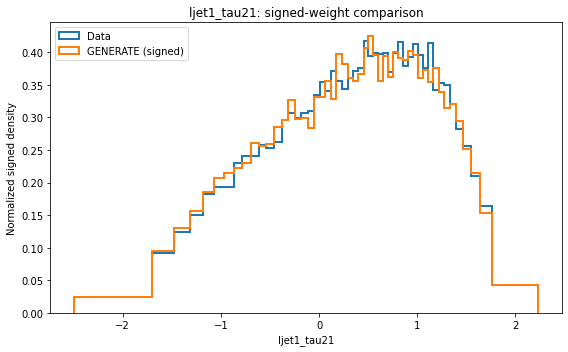

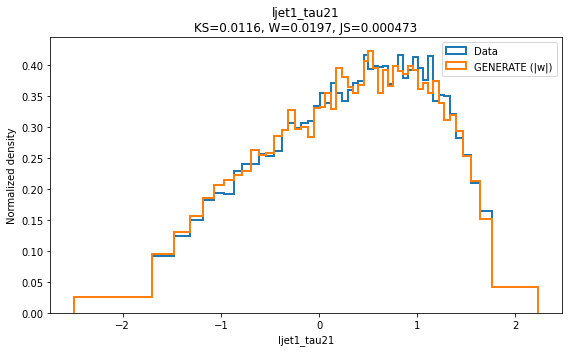

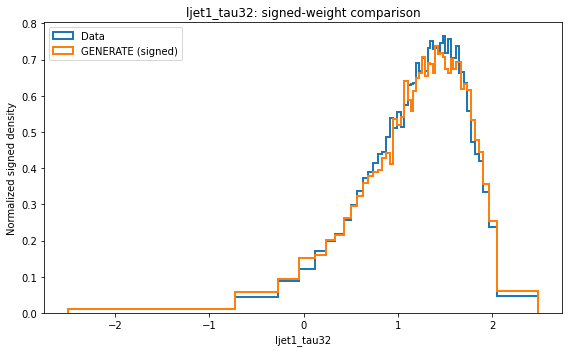

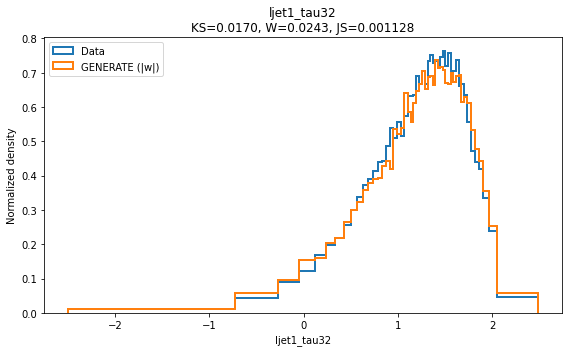

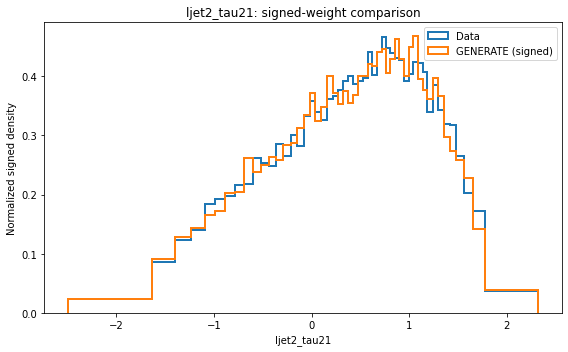

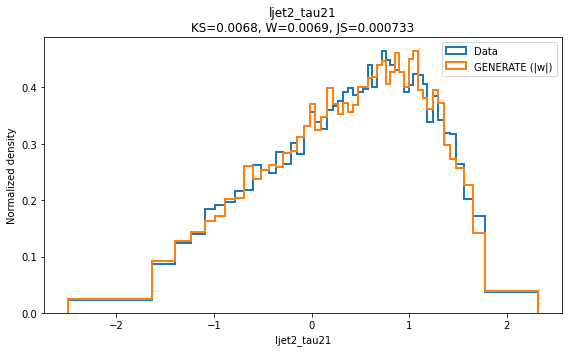

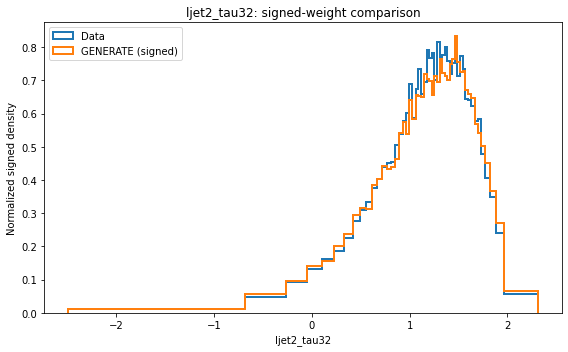

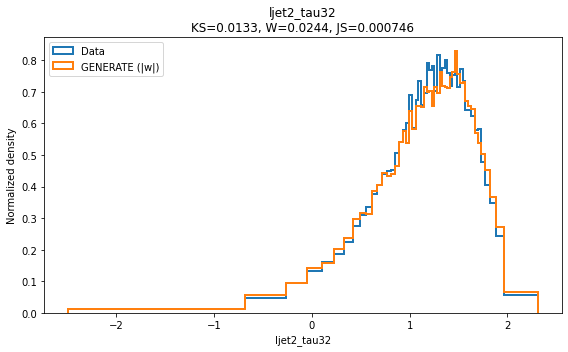

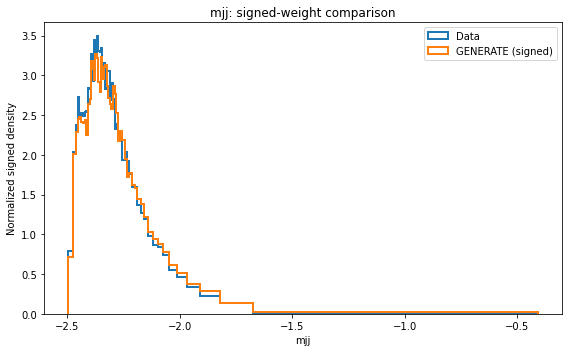

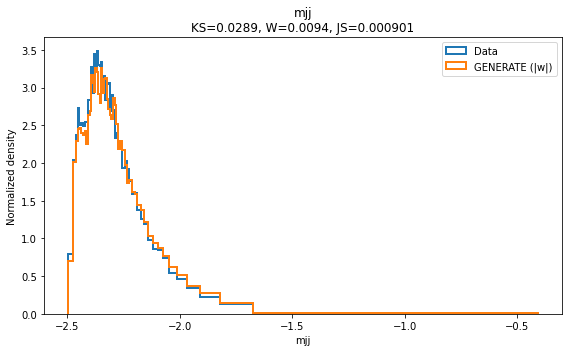

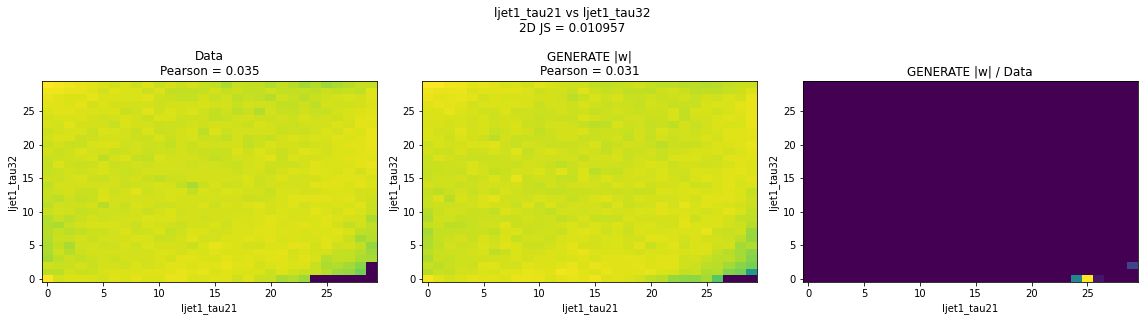

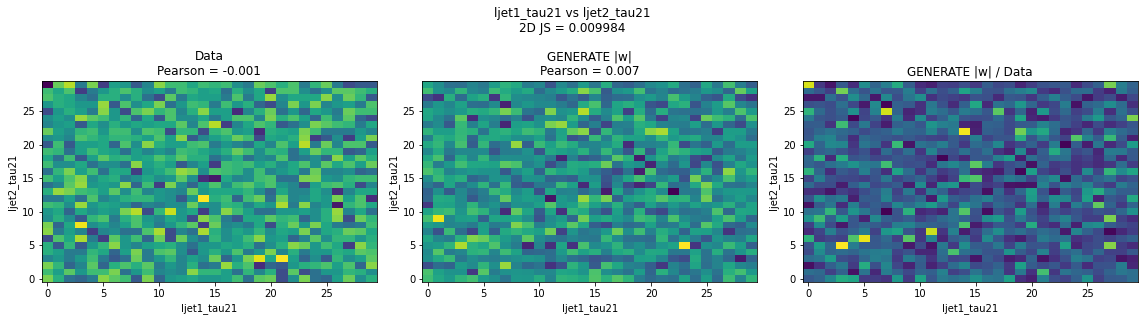

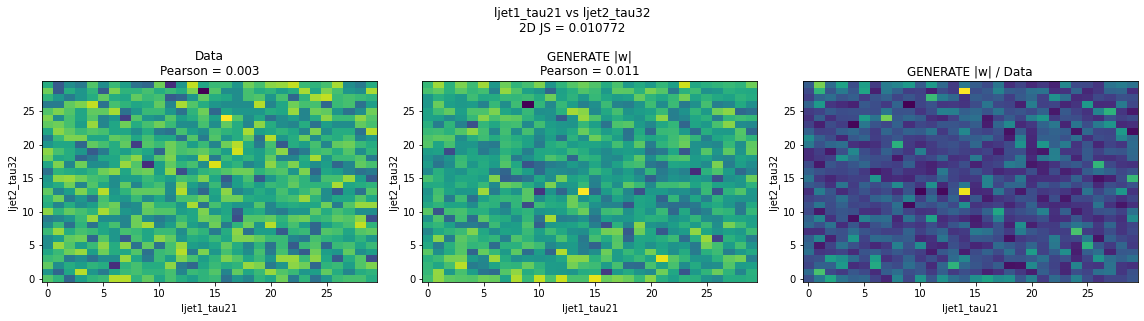

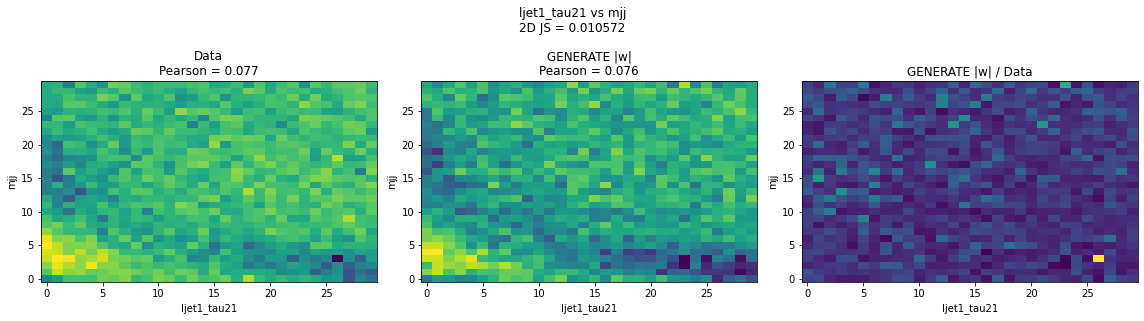

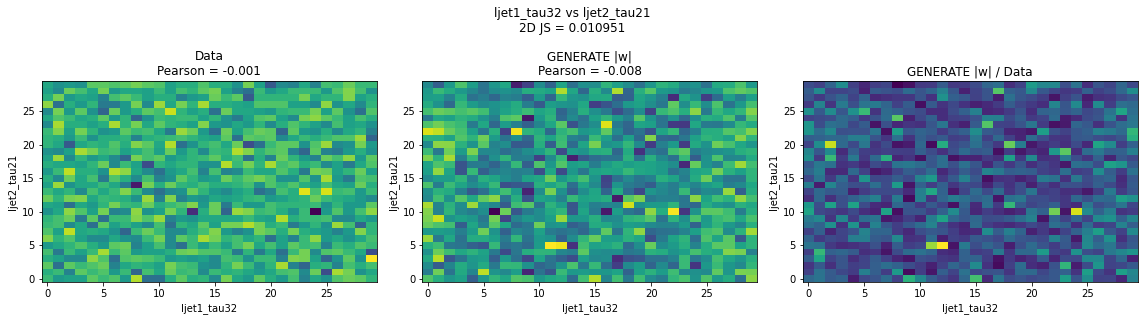

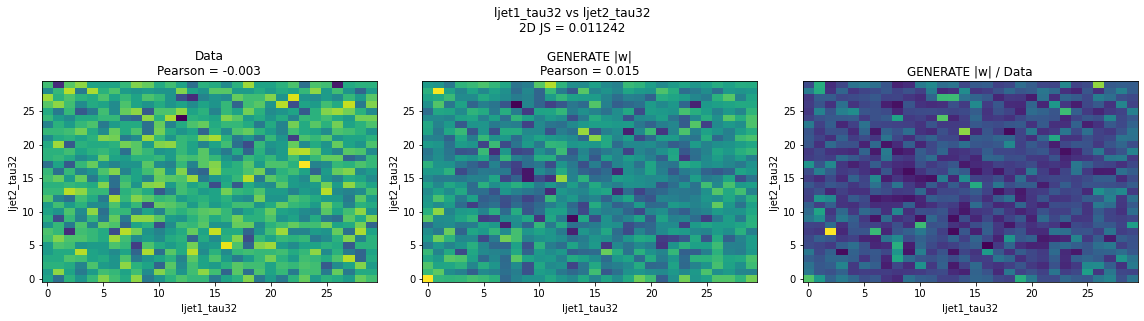

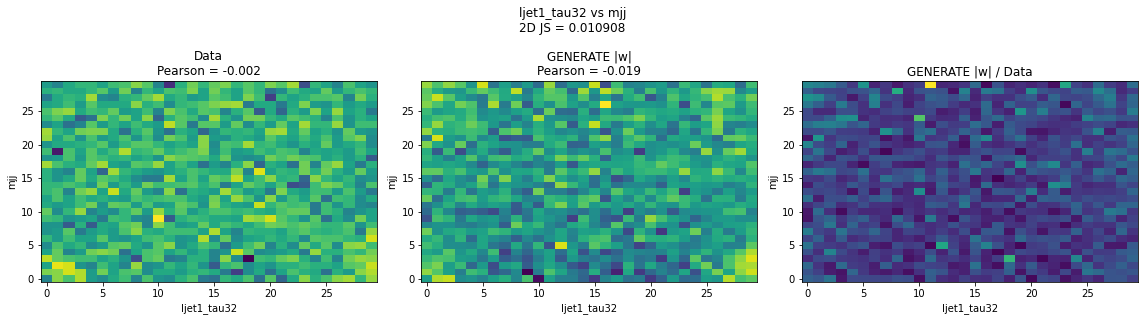

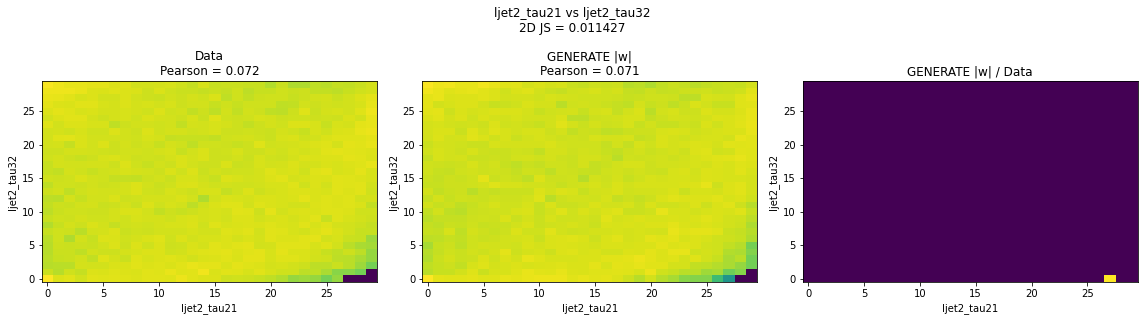

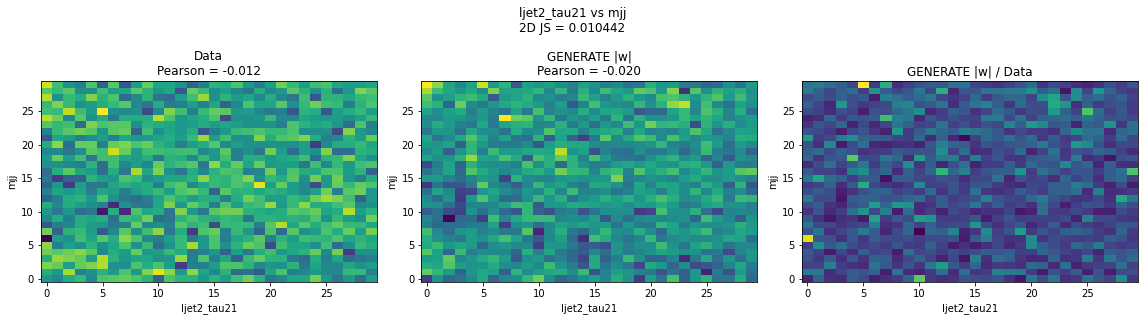

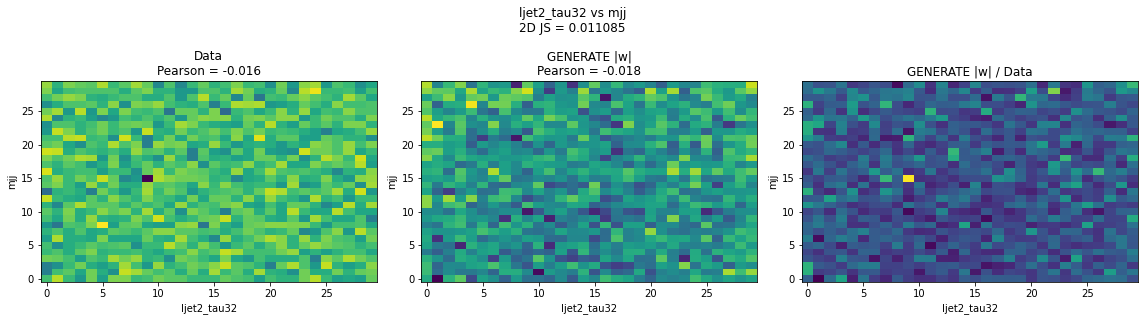

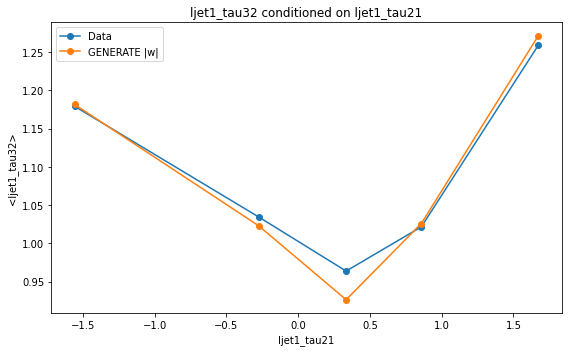

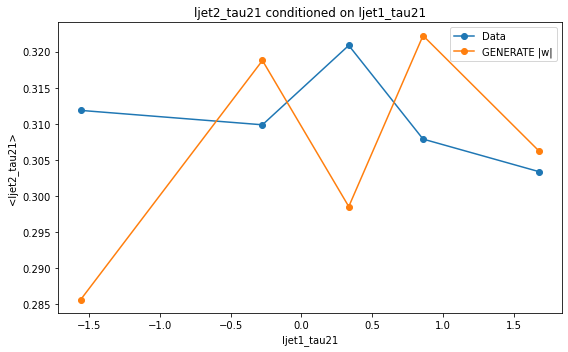

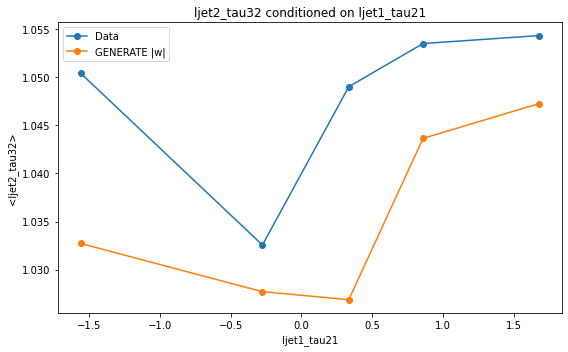

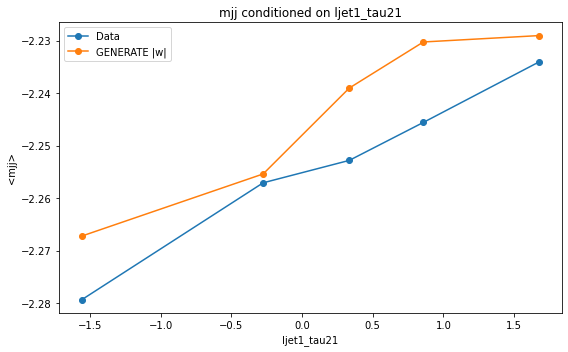

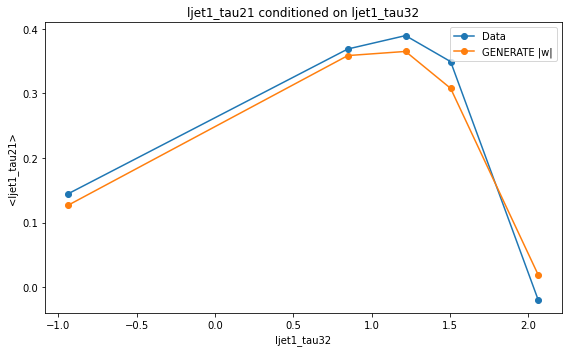

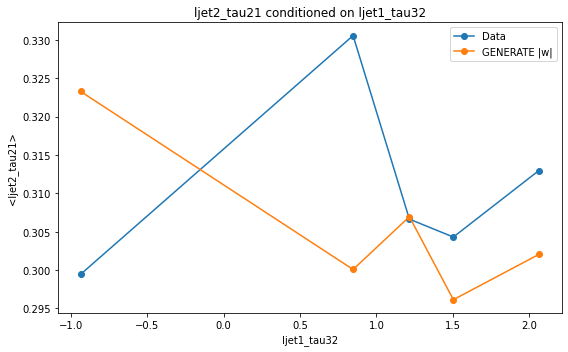

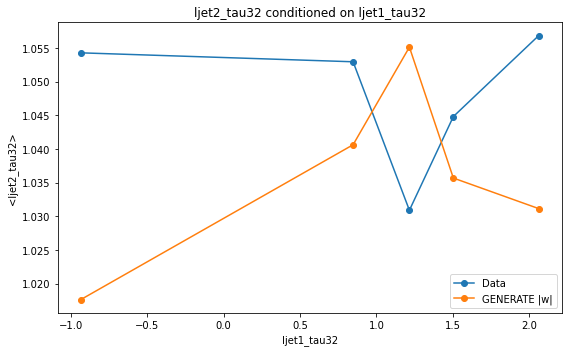

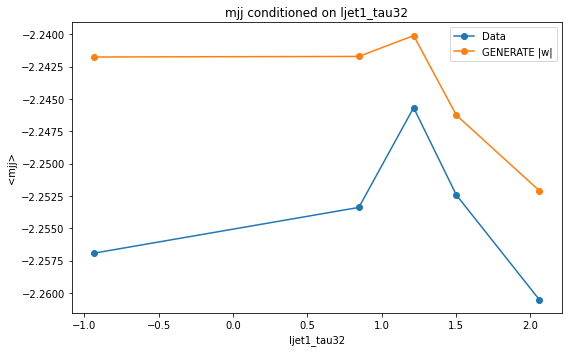

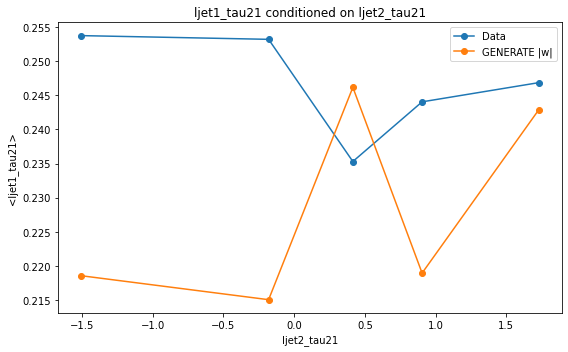

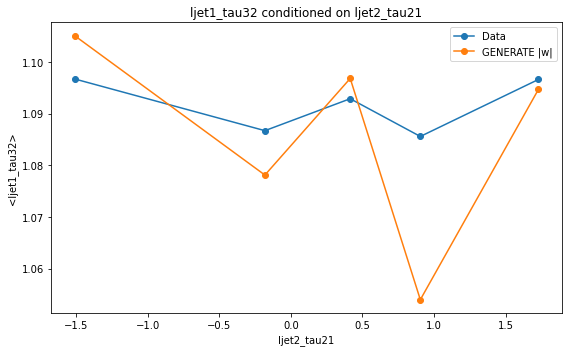

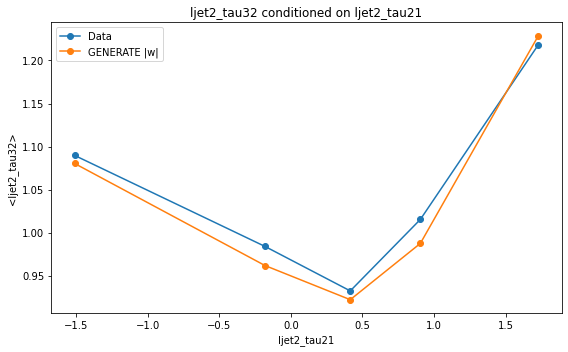

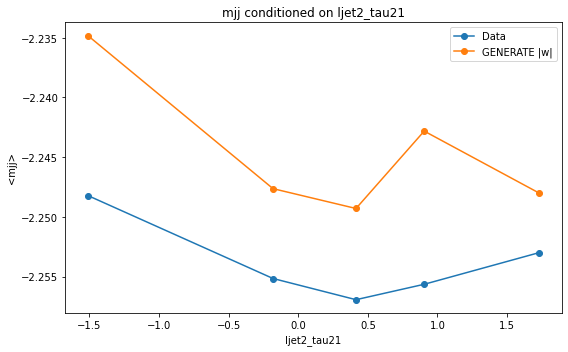

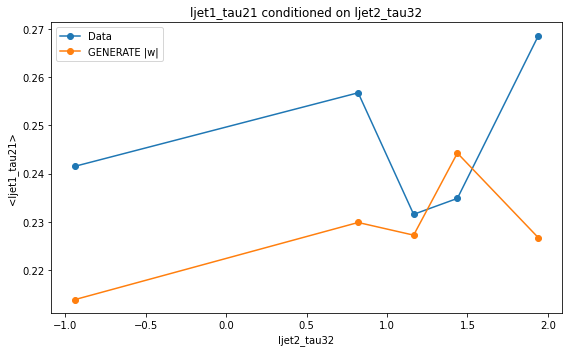

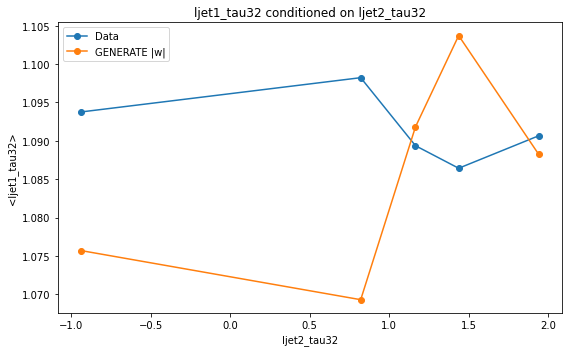

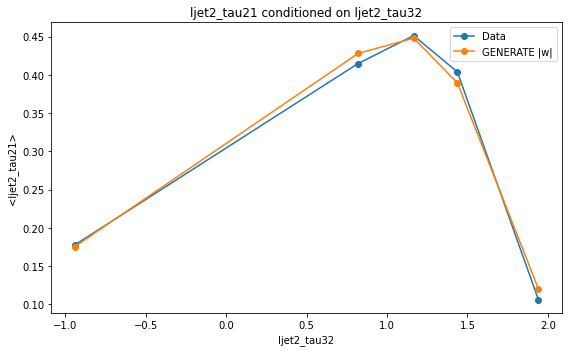

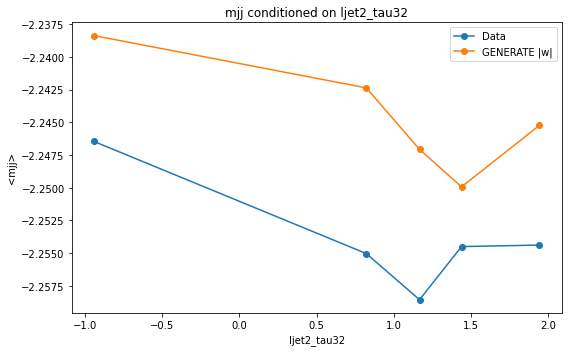

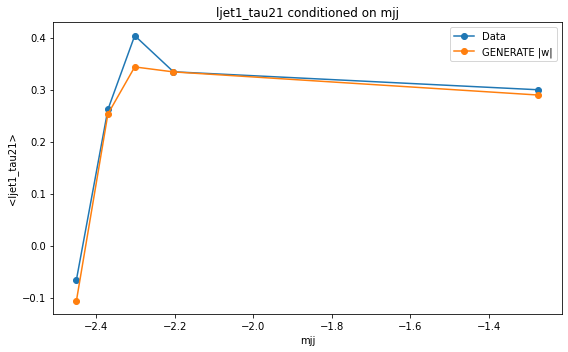

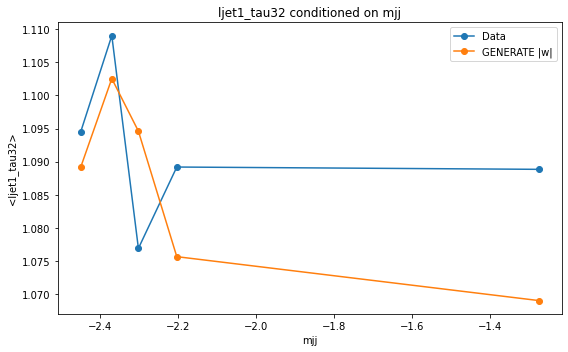

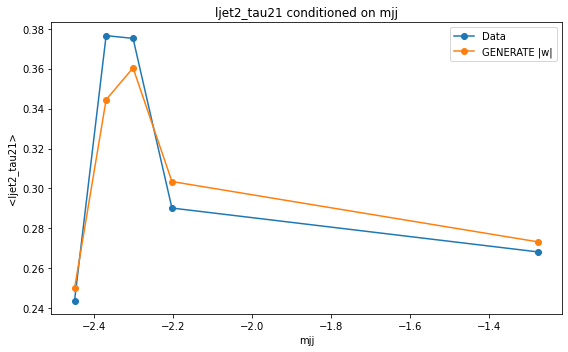

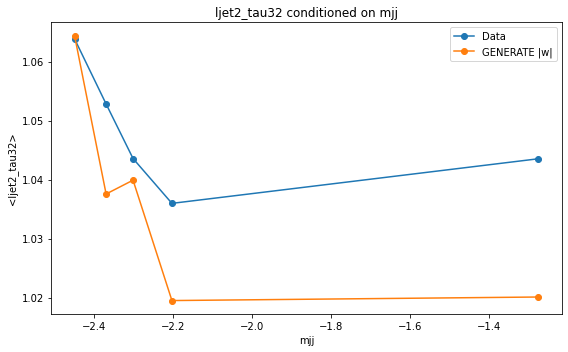


GENERATE PHYSICS VALIDATION

Features: ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']
DATA:      N = 21,983
GENERATE:  N = 84,161

--- GEN WEIGHTS ---
Sum signed weights     = 21880.5
Sum absolute weights   = 22148.2
Positive-weight events = 78,558
Negative-weight events = 5,603
Cancellation factor    = 0.9879

--- UNIVARIATE ---
ljet1_tau21     KS=0.0116   W=0.0197   JS=0.000473
ljet1_tau32     KS=0.0170   W=0.0243   JS=0.001128
ljet2_tau21     KS=0.0068   W=0.0069   JS=0.000733
ljet2_tau32     KS=0.0133   W=0.0244   JS=0.000746
mjj             KS=0.0289   W=0.0094   JS=0.000901

--- PAIRWISE CORRELATIONS ---

ljet1_tau21__vs__ljet1_tau32
  Pearson DATA              = +0.0348
  Pearson GEN (signed)      = +0.0316
  Pearson GEN (|w|)         = +0.0311
  Spearman DATA             = -0.0404
  Spearman GEN (|w|)        = -0.0308

ljet1_tau21__vs__ljet2_tau21
  Pearson DATA              = -0.0014
  Pearson GEN (signed)      = +0.0074
  Pearson GEN (|w|)         = +0.0

In [ ]:
results = validate_generate_events(
    data_events=df_data_cr,
    gen_events=df_mc_rw_cr,
    weight_col=RW_WEIGHT_COL,
    feature_list=features_vars,
    make_plots=True
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def calculate_kinematic_leakage(df_data, df_mc, var_x, var_y, weight_col_mc, weight_col_data=None, bins=50):
    """
    Calculates the percentage of MC events that fall into 'forbidden' regions
    (regions where the real Data has zero events).
    """
    print("Checking for leakage in variables:", var_x, "vs", var_y)
    print("Data Expected events:", len(df_data))
    print("MC Expected events:", df_mc[weight_col_mc].sum())
    # 1. Extract values
    x_data = df_data[var_x].values
    y_data = df_data[var_y].values
    w_data = df_data[weight_col_data].values if weight_col_data else np.ones(len(df_data))
    
    x_mc = df_mc[var_x].values
    y_mc = df_mc[var_y].values
    w_mc = df_mc[weight_col_mc].values
    
    # 2. Define a shared grid that covers the extreme bounds of BOTH datasets
    x_min = min(np.min(x_data), np.min(x_mc))
    x_max = max(np.max(x_data), np.max(x_mc))
    y_min = min(np.min(y_data), np.min(y_mc))
    y_max = max(np.max(y_data), np.max(y_mc))
    
    x_edges = np.linspace(x_min, x_max, bins + 1)
    y_edges = np.linspace(y_min, y_max, bins + 1)
    
    # 3. Histogram the Data to find the valid physical footprint
    hist_data, _, _ = np.histogram2d(x_data, y_data, bins=[x_edges, y_edges], weights=w_data)
    
    # Define the Forbidden Zone: Any bin where Data is exactly 0
    forbidden_mask = (hist_data == 0)
    
    # 4. Histogram the MC Generated data on the exact same grid
    hist_mc, _, _ = np.histogram2d(x_mc, y_mc, bins=[x_edges, y_edges], weights=w_mc)
    
    # 5. Calculate Leakage (Sum of MC weights in the forbidden mask)
    leaked_mc_weights = np.sum(hist_mc[forbidden_mask])
    total_mc_weight = np.sum(hist_mc)
    
    leakage_percent = (leaked_mc_weights / total_mc_weight) * 100
    vmax = max(np.max(hist_data), np.max(hist_mc))
    # --- VISUALIZATION ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: The Empirical Forbidden Zone
    # We transpose the masks for pcolormesh (x corresponds to columns, y to rows)
    cmap_forbidden = mcolors.ListedColormap(['white', 'red'])
    axes[0].pcolormesh(x_edges, y_edges, forbidden_mask.T, cmap=cmap_forbidden, alpha=0.3)
    
    # Overlay the actual data footprint in blue
    valid_mask = np.ma.masked_where(hist_data.T == 0, hist_data.T)
    axes[0].pcolormesh(x_edges, y_edges, valid_mask, cmap='viridis', norm=mcolors.LogNorm(vmin=1e-5, vmax=vmax))
    axes[0].set_title(f"Data Footprint & Forbidden Zone (Red)")
    axes[0].set_xlabel(var_x)
    axes[0].set_ylabel(var_y)
    
    # Plot 2: MC Leakage
    axes[1].pcolormesh(x_edges, y_edges, forbidden_mask.T, cmap=cmap_forbidden, alpha=0.3)
    
    # Overlay the MC data
    mc_valid_mask = np.ma.masked_where(hist_mc.T == 0, hist_mc.T)
    pc = axes[1].pcolormesh(x_edges, y_edges, mc_valid_mask, cmap='viridis', norm=mcolors.LogNorm(vmin=1e-5, vmax=vmax))
    axes[1].set_title(f"MC Data\nLeaked: {leakage_percent:.2f}% of Total Weight")
    axes[1].set_xlabel(var_x)
    fig.colorbar(pc, ax=axes[1], label='MC Weight (Log Scale)')
    
    plt.tight_layout()
    plt.show()
    
    return leakage_percent

Checking for leakage in variables: ljet1_tau21 vs ljet1_tau32
Data Expected events: 188757
MC Expected events: 183495.26017226576


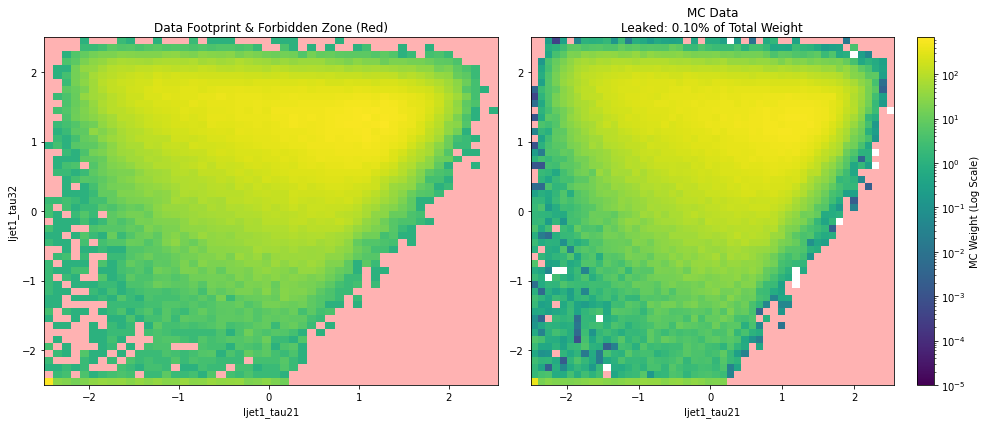

Checking for leakage in variables: ljet1_tau21 vs ljet1_tau32
Data Expected events: 188757
MC Expected events: 183843.72662708335


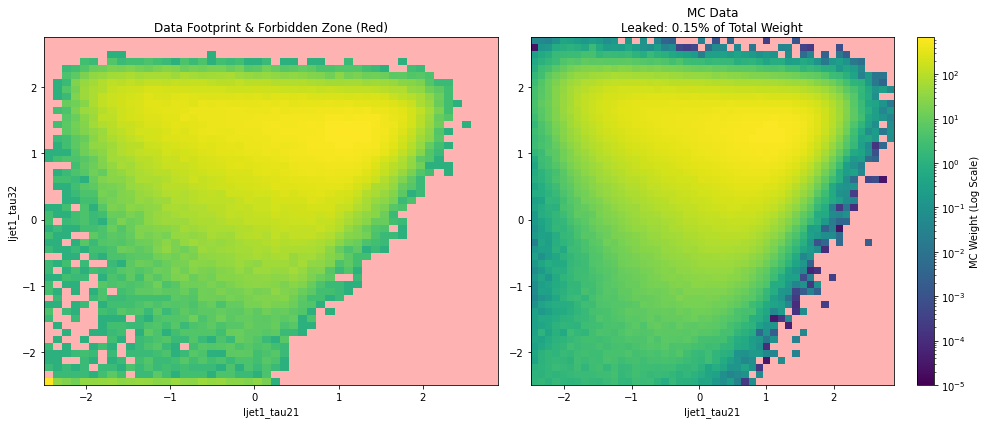

Total MC leaking into forbidden zones (RW): 0.10%
Total MC leaking into forbidden zones (GEN): 0.15%
Checking for leakage in variables: ljet1_tau21 vs ljet2_tau21
Data Expected events: 188757
MC Expected events: 183495.26017226576


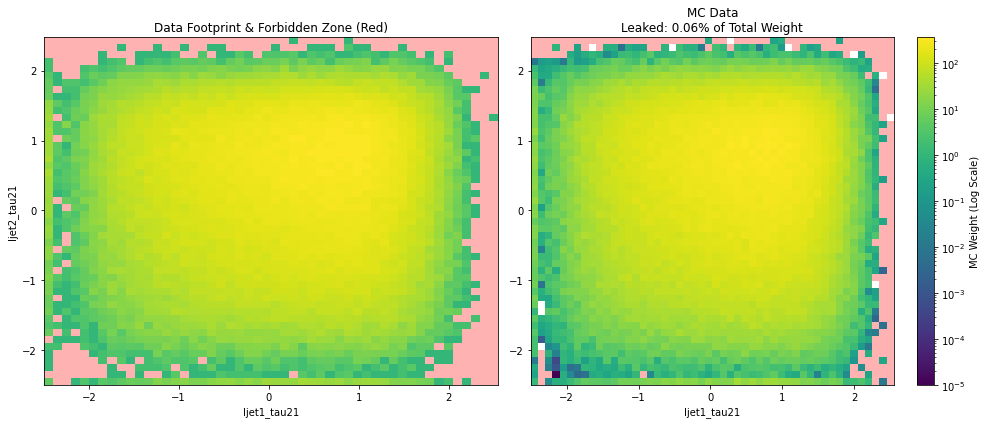

Checking for leakage in variables: ljet1_tau21 vs ljet2_tau21
Data Expected events: 188757
MC Expected events: 183843.72662708335


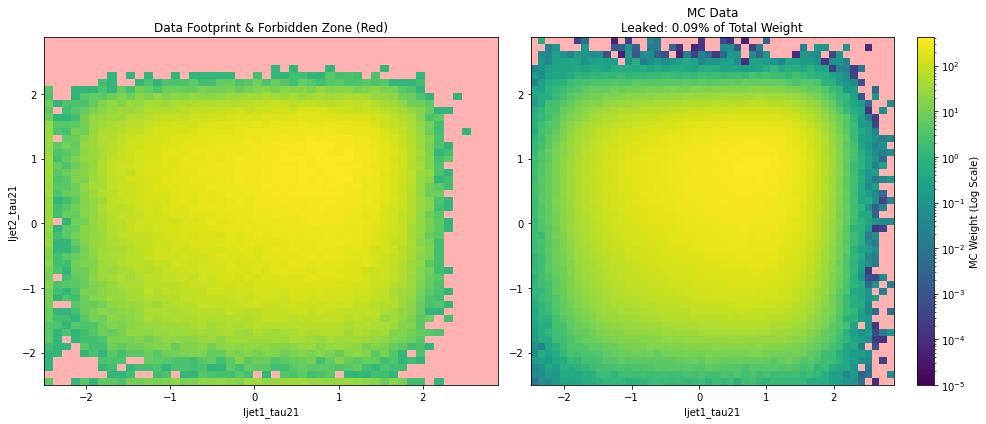

Total MC leaking into forbidden zones (RW): 0.06%
Total MC leaking into forbidden zones (GEN): 0.09%
Checking for leakage in variables: ljet1_tau21 vs ljet2_tau32
Data Expected events: 188757
MC Expected events: 183495.26017226576


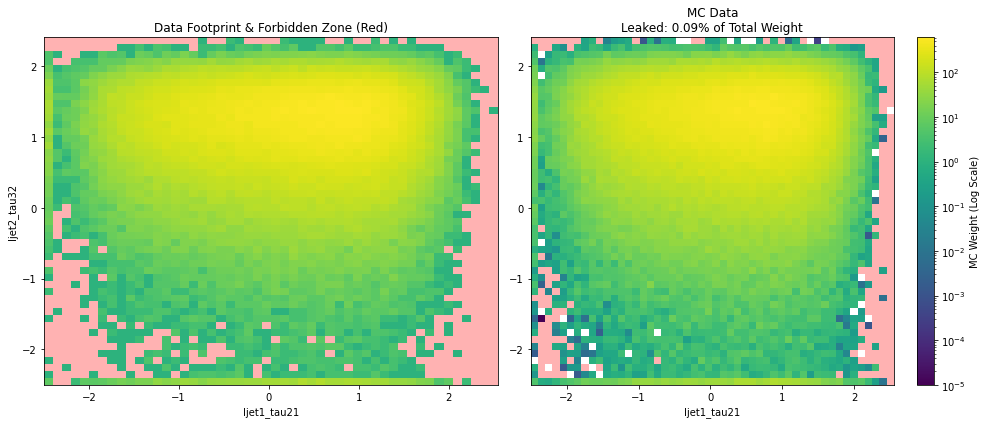

Checking for leakage in variables: ljet1_tau21 vs ljet2_tau32
Data Expected events: 188757
MC Expected events: 183843.72662708335


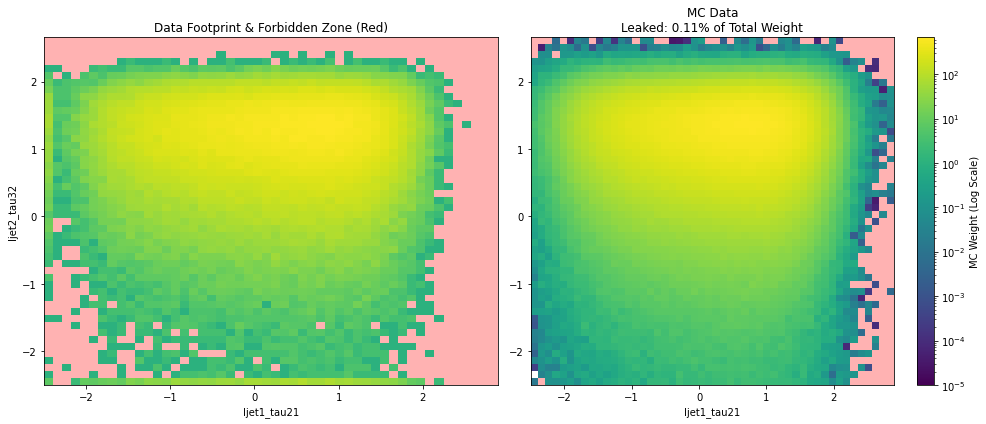

Total MC leaking into forbidden zones (RW): 0.09%
Total MC leaking into forbidden zones (GEN): 0.11%
Checking for leakage in variables: ljet1_tau21 vs mjj
Data Expected events: 188757
MC Expected events: 183495.26017226576


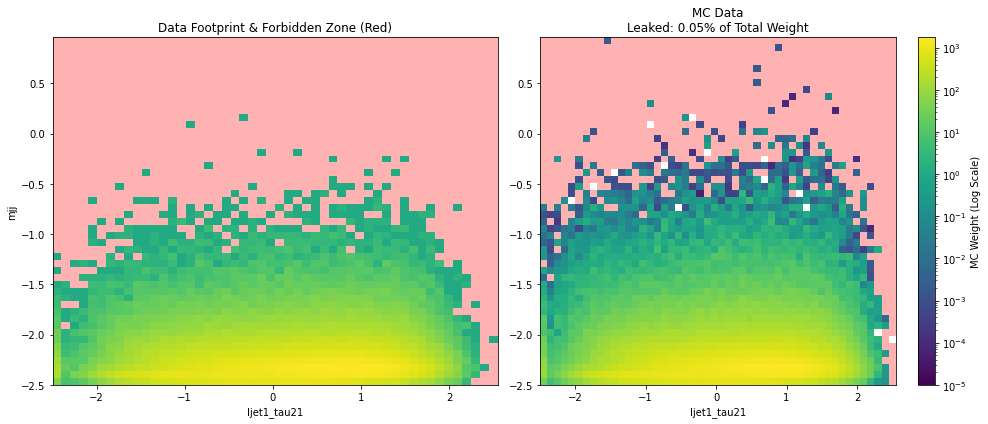

Checking for leakage in variables: ljet1_tau21 vs mjj
Data Expected events: 188757
MC Expected events: 183843.72662708335


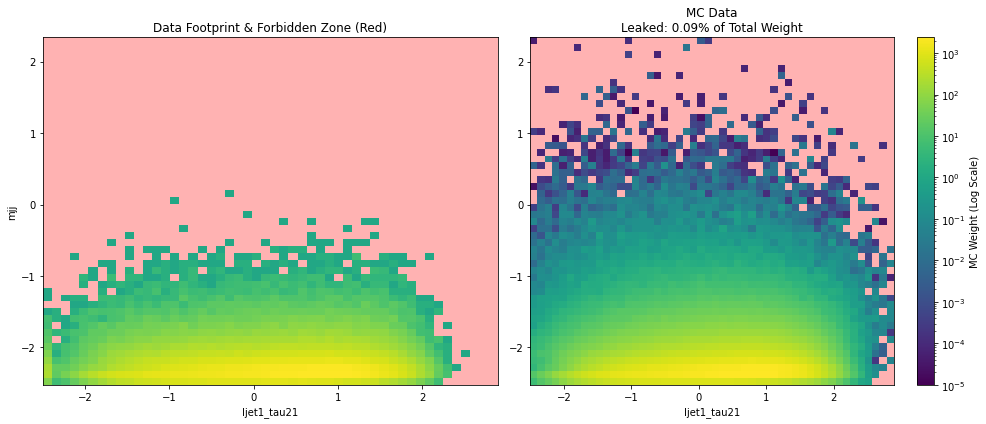

Total MC leaking into forbidden zones (RW): 0.05%
Total MC leaking into forbidden zones (GEN): 0.09%
Checking for leakage in variables: ljet1_tau32 vs ljet2_tau21
Data Expected events: 188757
MC Expected events: 183495.26017226576


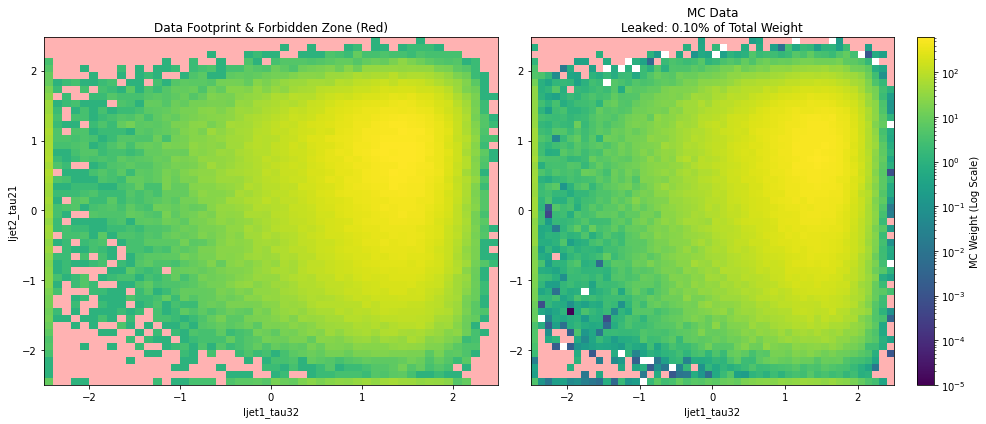

Checking for leakage in variables: ljet1_tau32 vs ljet2_tau21
Data Expected events: 188757
MC Expected events: 183843.72662708335


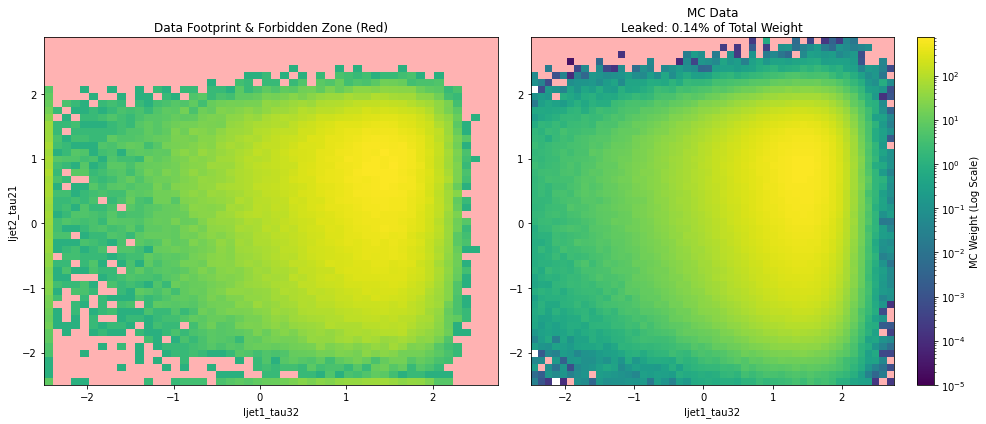

Total MC leaking into forbidden zones (RW): 0.10%
Total MC leaking into forbidden zones (GEN): 0.14%
Checking for leakage in variables: ljet1_tau32 vs ljet2_tau32
Data Expected events: 188757
MC Expected events: 183495.26017226576


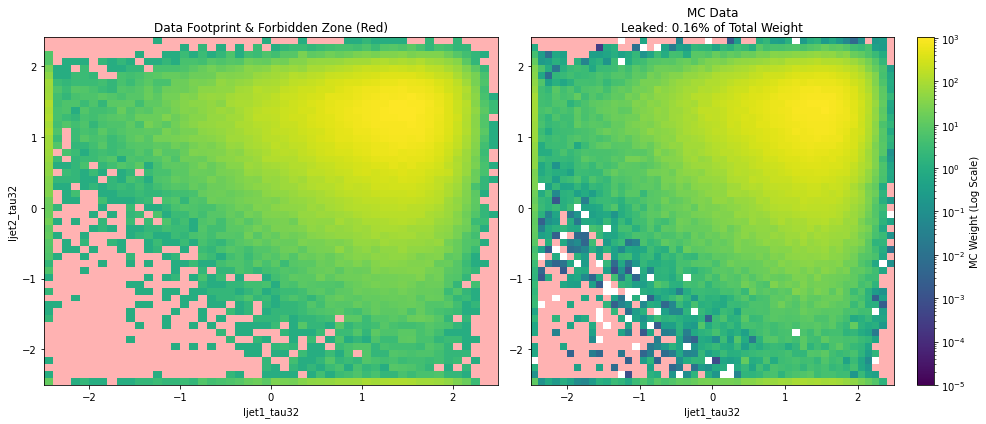

Checking for leakage in variables: ljet1_tau32 vs ljet2_tau32
Data Expected events: 188757
MC Expected events: 183843.72662708335


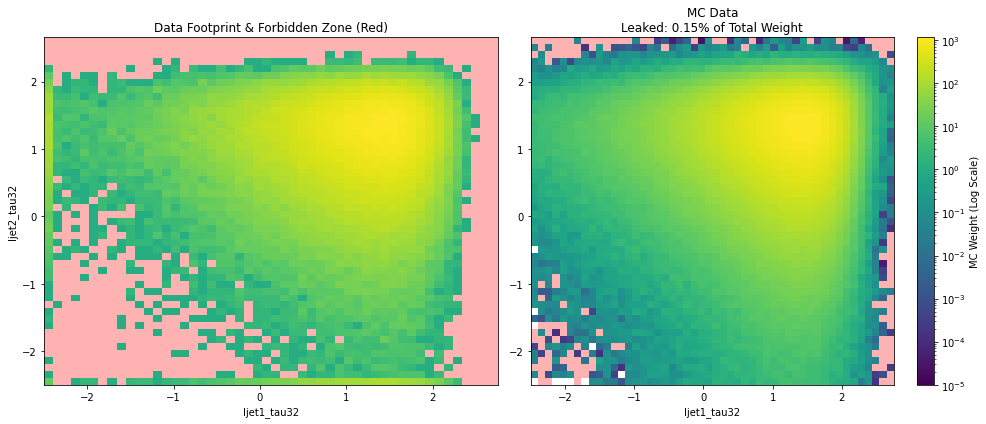

Total MC leaking into forbidden zones (RW): 0.16%
Total MC leaking into forbidden zones (GEN): 0.15%
Checking for leakage in variables: ljet1_tau32 vs mjj
Data Expected events: 188757
MC Expected events: 183495.26017226576


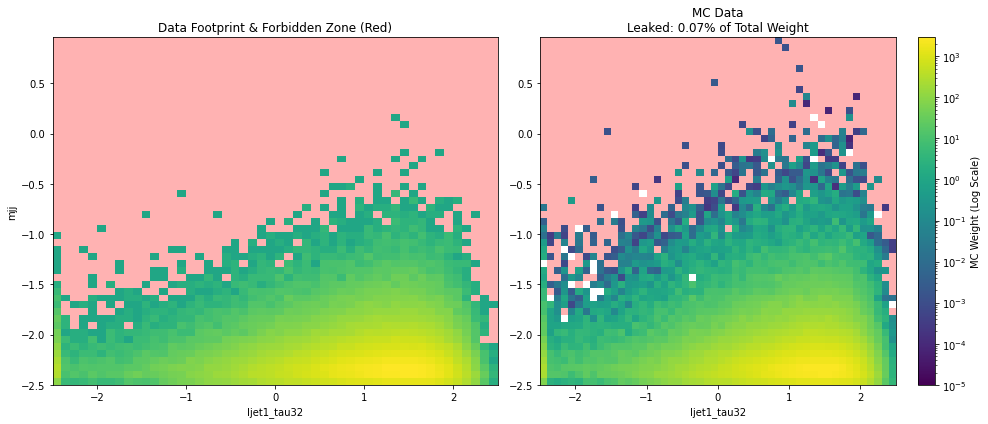

Checking for leakage in variables: ljet1_tau32 vs mjj
Data Expected events: 188757
MC Expected events: 183843.72662708335


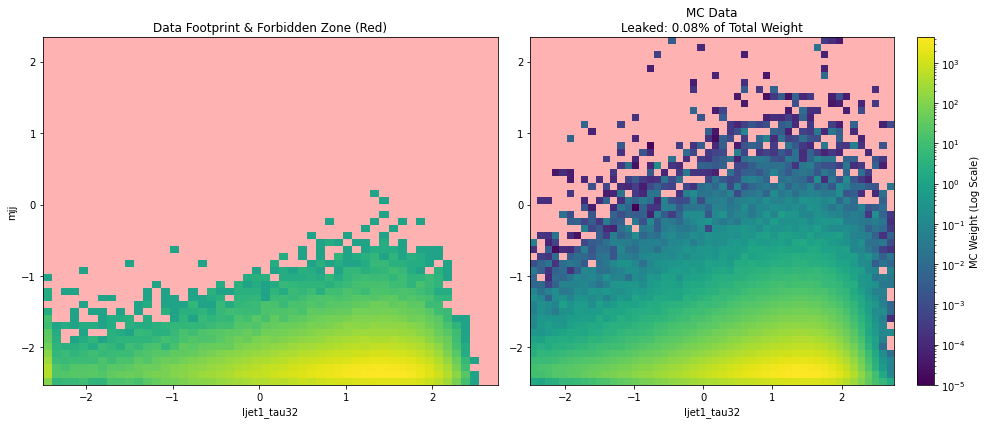

Total MC leaking into forbidden zones (RW): 0.07%
Total MC leaking into forbidden zones (GEN): 0.08%
Checking for leakage in variables: ljet2_tau21 vs ljet2_tau32
Data Expected events: 188757
MC Expected events: 183495.26017226576


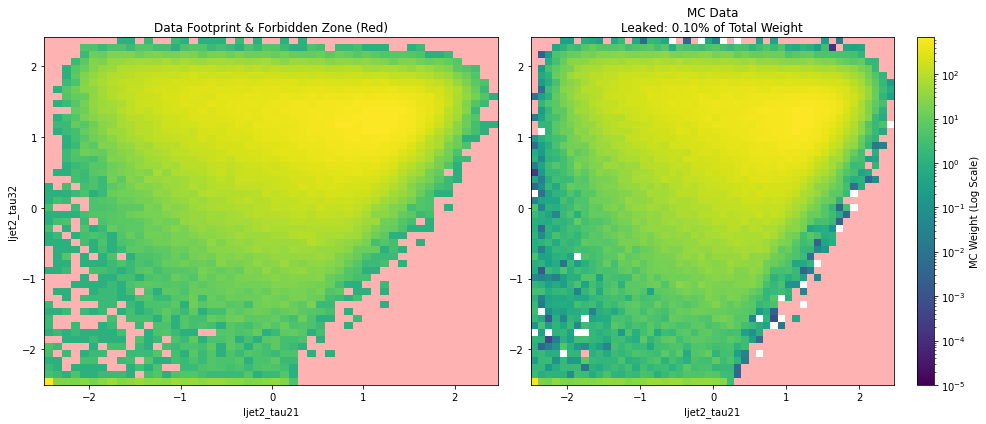

Checking for leakage in variables: ljet2_tau21 vs ljet2_tau32
Data Expected events: 188757
MC Expected events: 183843.72662708335


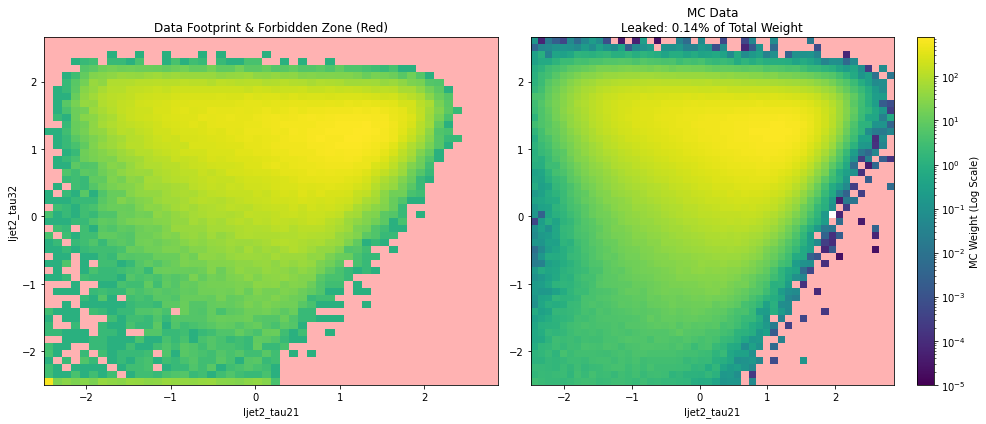

Total MC leaking into forbidden zones (RW): 0.10%
Total MC leaking into forbidden zones (GEN): 0.14%
Checking for leakage in variables: ljet2_tau21 vs mjj
Data Expected events: 188757
MC Expected events: 183495.26017226576


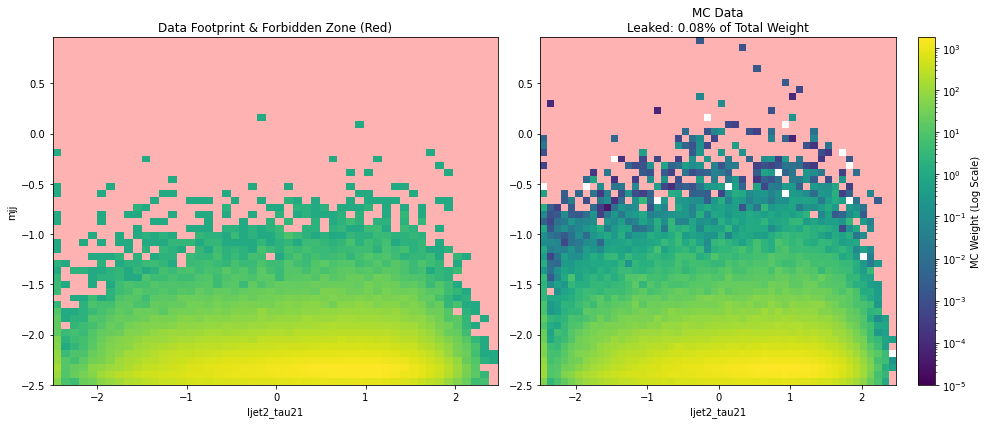

Checking for leakage in variables: ljet2_tau21 vs mjj
Data Expected events: 188757
MC Expected events: 183843.72662708335


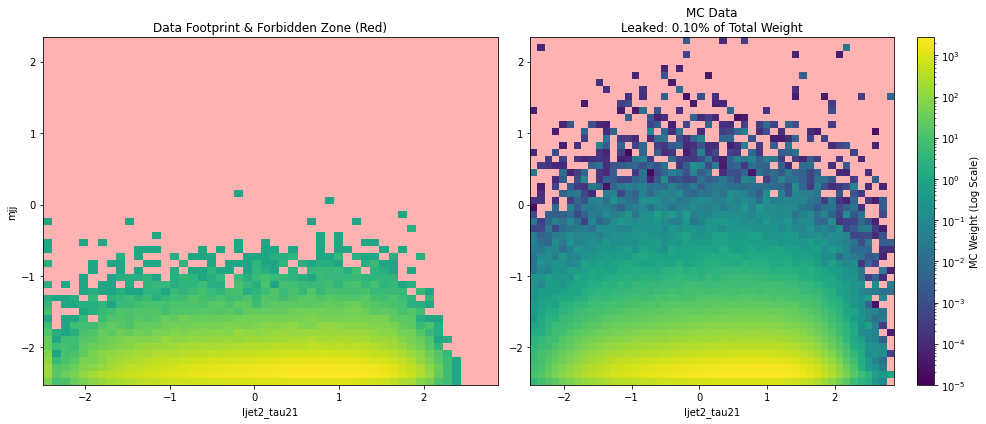

Total MC leaking into forbidden zones (RW): 0.08%
Total MC leaking into forbidden zones (GEN): 0.10%
Checking for leakage in variables: ljet2_tau32 vs mjj
Data Expected events: 188757
MC Expected events: 183495.26017226576


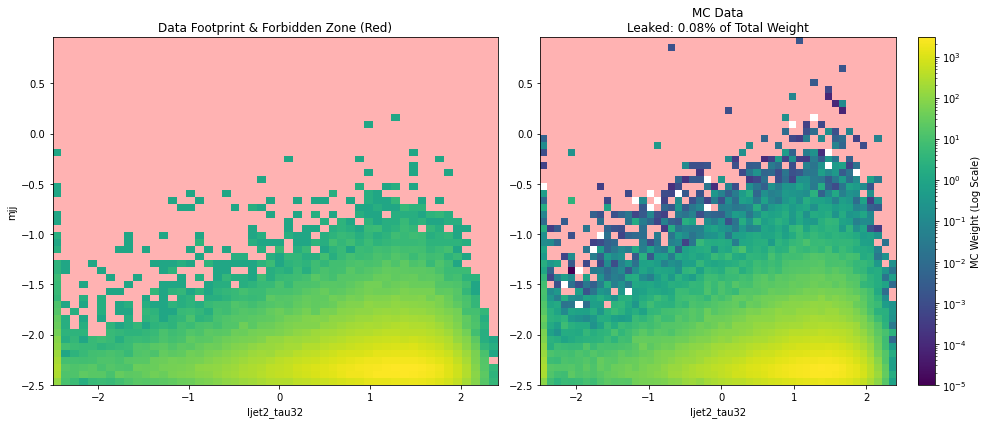

Checking for leakage in variables: ljet2_tau32 vs mjj
Data Expected events: 188757
MC Expected events: 183843.72662708335


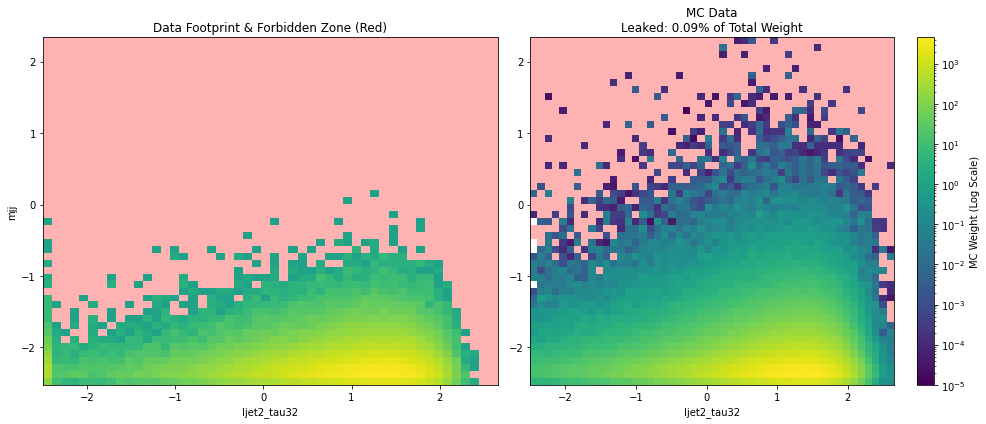

Total MC leaking into forbidden zones (RW): 0.08%
Total MC leaking into forbidden zones (GEN): 0.09%


In [ ]:
# Check leakage for substructure vs mass in the Signal Region
import itertools

combinations = list(itertools.combinations(features_vars, 2))

# print(combinations)

for var_x, var_y in combinations:

    leakage_rw = calculate_kinematic_leakage(
        df_data_sr, 
        df_mc_rw_sr, 
        var_x=var_x, 
        var_y=var_y, 
        weight_col_mc=RW_WEIGHT_COL
    )
    leakage_gen = calculate_kinematic_leakage(
        df_data_sr, 
        df_mc_gen_sr, 
        var_x=var_x, 
        var_y=var_y, 
        weight_col_mc=GEN_WEIGHT_COL
    )
    print(f"Total MC leaking into forbidden zones (RW): {leakage_rw:.2f}%")
    print(f"Total MC leaking into forbidden zones (GEN): {leakage_gen:.2f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

def weighted_pearson_1d(x, y, w):
    """Helper for weighted Pearson correlation."""
    mean_x = np.average(x, weights=w)
    mean_y = np.average(y, weights=w)
    cov = np.average((x - mean_x) * (y - mean_y), weights=w)
    var_x = np.average((x - mean_x)**2, weights=w)
    var_y = np.average((y - mean_y)**2, weights=w)
    if var_x == 0 or var_y == 0: return 0.0
    return cov / np.sqrt(var_x * var_y)

def plot_core_contours(df_data, df_mc, var_x, var_y, weight_col_mc, weight_col_data=None, bins=60, smooth_sigma=1.5):
    """
    Plots the MC Generated data as a heatmap and overlays the real Data as density contours
    to diagnose internal tilt and shape mismatches.
    """
    # 1. Extract values
    x_data = df_data[var_x].values
    y_data = df_data[var_y].values
    w_data = df_data[weight_col_data].values if weight_col_data else np.ones(len(df_data))
    
    x_mc = df_mc[var_x].values
    y_mc = df_mc[var_y].values
    w_mc = df_mc[weight_col_mc].values
    
    # Calculate correlations
    corr_data = weighted_pearson_1d(x_data, y_data, w_data)
    corr_mc = weighted_pearson_1d(x_mc, y_mc, w_mc)
    
    # 2. Define shared boundaries focusing on the bulk (1st to 99th percentile)
    x_min = min(np.percentile(x_data, 1), np.percentile(x_mc, 1))
    x_max = max(np.percentile(x_data, 99), np.percentile(x_mc, 99))
    y_min = min(np.percentile(y_data, 1), np.percentile(y_mc, 1))
    y_max = max(np.percentile(y_data, 99), np.percentile(y_mc, 99))
    
    x_edges = np.linspace(x_min, x_max, bins + 1)
    y_edges = np.linspace(y_min, y_max, bins + 1)
    
    # Grid centers for contour plotting
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    
    # 3. Create histograms
    hist_data, _, _ = np.histogram2d(x_data, y_data, bins=[x_edges, y_edges], weights=w_data)
    hist_mc, _, _ = np.histogram2d(x_mc, y_mc, bins=[x_edges, y_edges], weights=w_mc)
    
    # 4. Smooth the Data histogram to create clean contour lines
    # The transpose (.T) is required because histogram2d returns (x_bins, y_bins), 
    # but contour expects the y-axis to be the first dimension (rows).
    smoothed_data = gaussian_filter(hist_data.T, sigma=smooth_sigma)
    
    # Define contour levels (e.g., drawing lines at 20%, 40%, 60%, 80%, 95% of the max density)
    max_density = np.max(smoothed_data)
    levels = [max_density * 0.1, max_density * 0.3, max_density * 0.6, max_density * 0.9]

    # 5. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    vmax = max(np.max(hist_data), np.max(hist_mc)) # Shared color scale
    
    # --- Left Plot: Data (Heatmap) + Data (Contours) ---
    valid_data = np.ma.masked_where(hist_data.T == 0, hist_data.T)
    pc1 = axes[0].pcolormesh(x_edges, y_edges, valid_data, cmap='viridis', norm=mcolors.LogNorm(vmin=1e-3, vmax=vmax))
    axes[0].contour(X, Y, smoothed_data, levels=levels, colors='white', linewidths=2, alpha=0.8)
    
    axes[0].set_title(f"Data (Ground Truth)\nPearson: {corr_data:.3f}")
    axes[0].set_xlabel(var_x)
    axes[0].set_ylabel(var_y)
    
    # --- Right Plot: MC (Heatmap) + Data (Contours Overlay) ---
    valid_mc = np.ma.masked_where(hist_mc.T == 0, hist_mc.T)
    pc2 = axes[1].pcolormesh(x_edges, y_edges, valid_mc, cmap='viridis', norm=mcolors.LogNorm(vmin=1e-3, vmax=vmax))
    axes[1].contour(X, Y, smoothed_data, levels=levels, colors='white', linewidths=2, alpha=0.8, linestyles='dashed')
    
    axes[1].set_title(f"MC Generated + Data Contours\nPearson: {corr_mc:.3f}")
    axes[1].set_xlabel(var_x)
    fig.colorbar(pc2, ax=axes[1], label='Log(Sum of Weights)')
    
    plt.tight_layout()
    plt.show()

Plotting core contours for ljet1_tau21 vs ljet1_tau32


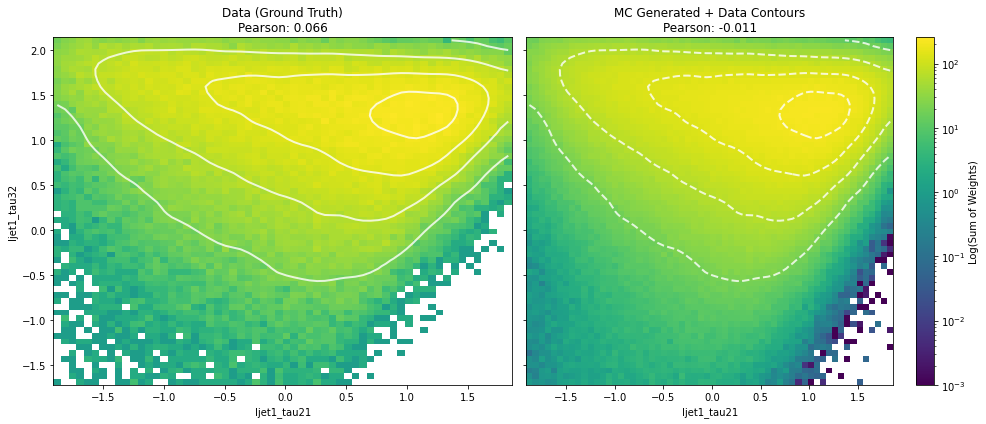

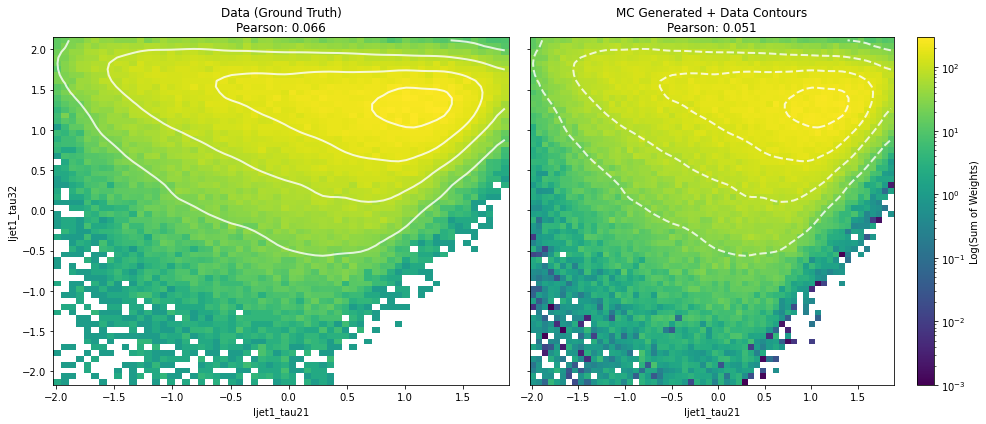

Plotting core contours for ljet1_tau21 vs ljet2_tau21


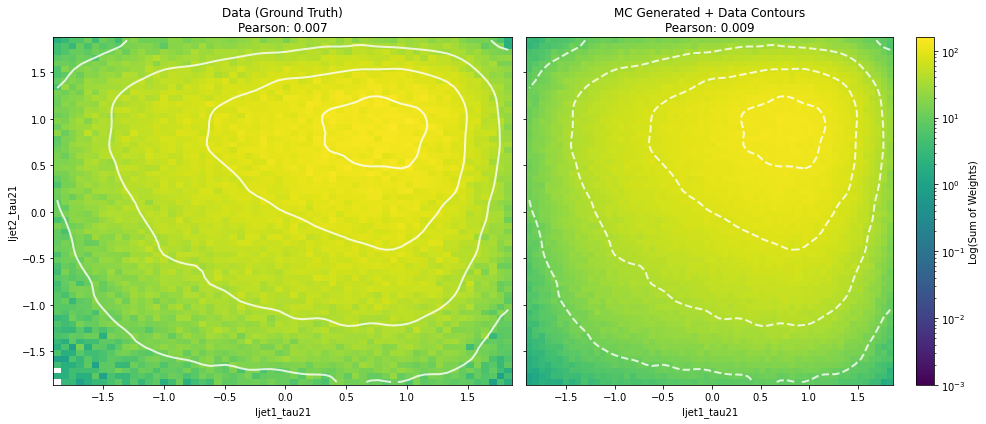

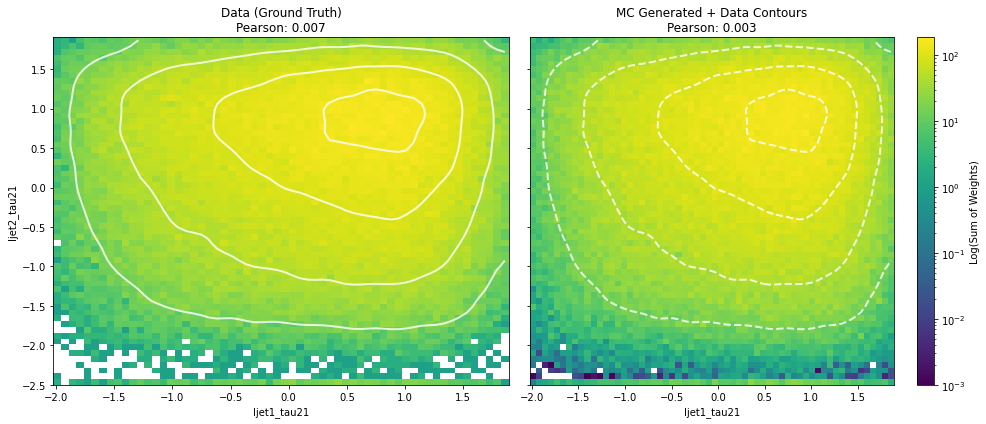

Plotting core contours for ljet1_tau21 vs ljet2_tau32


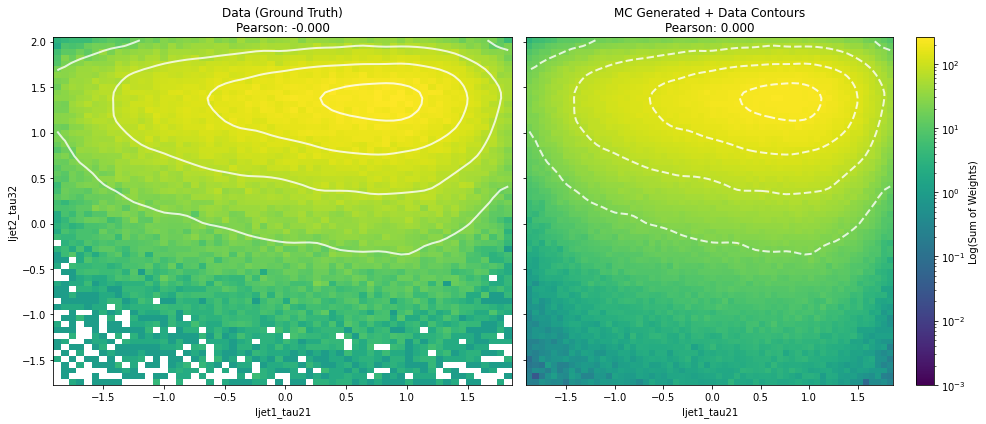

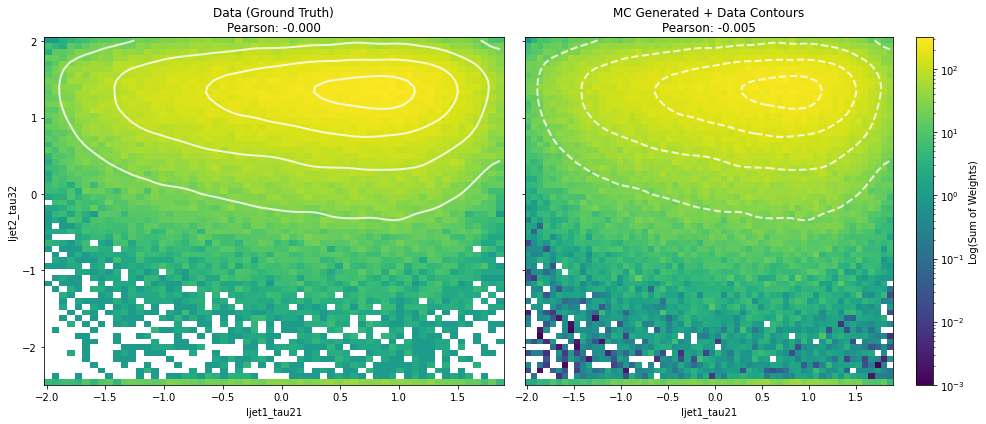

Plotting core contours for ljet1_tau21 vs mjj


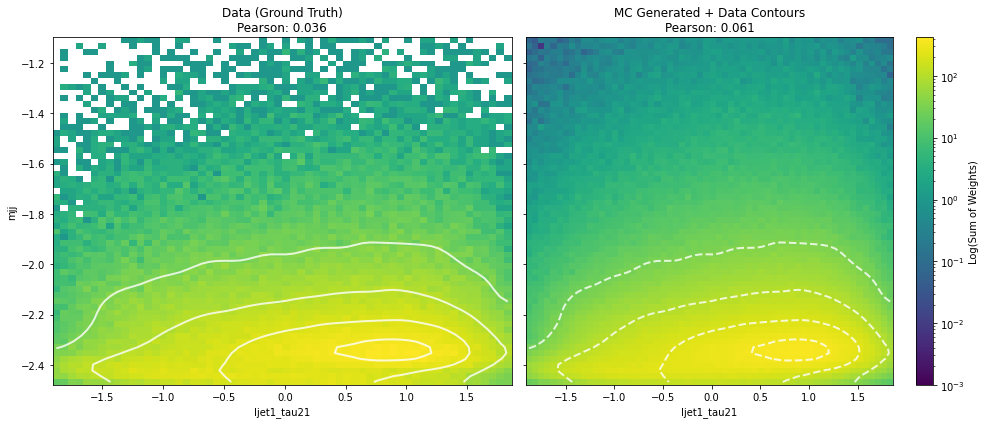

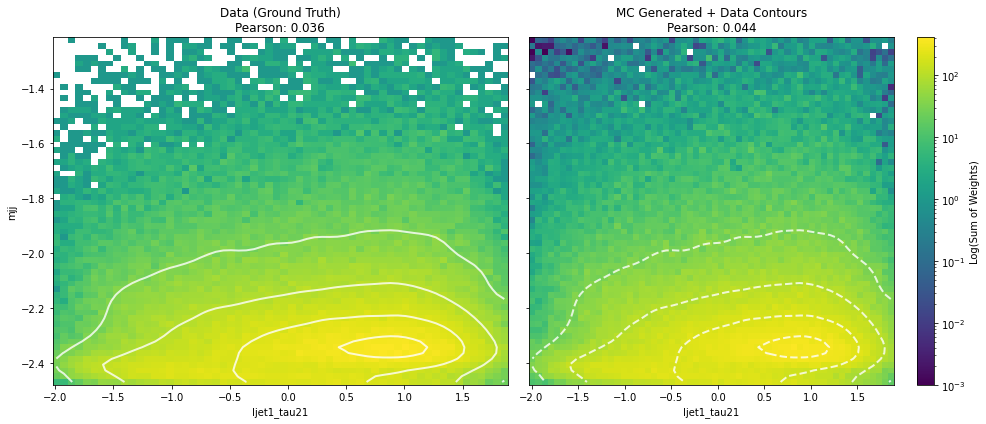

Plotting core contours for ljet1_tau32 vs ljet2_tau21


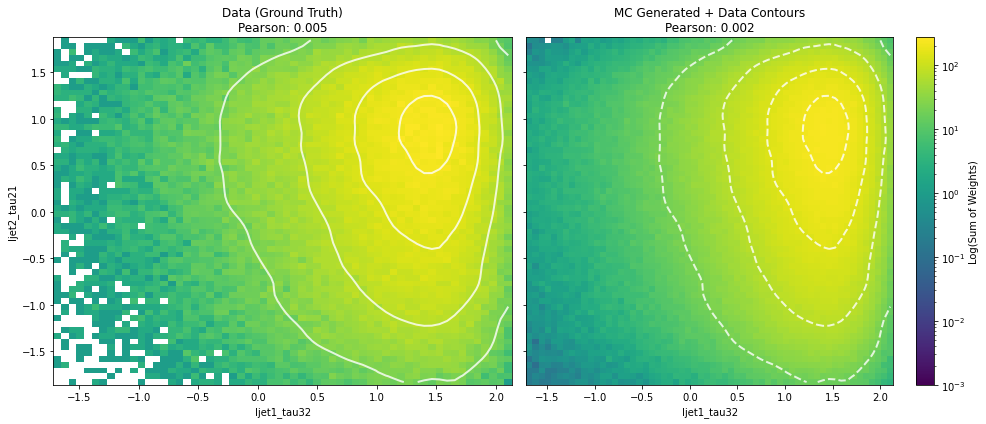

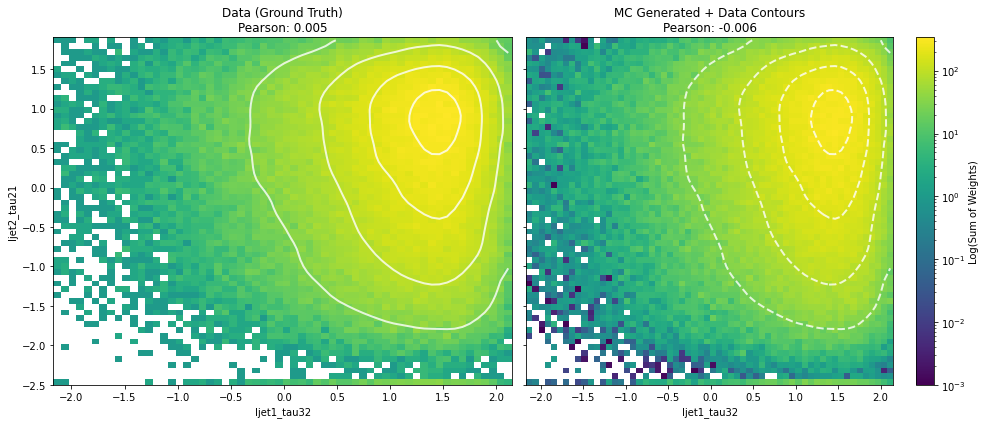

Plotting core contours for ljet1_tau32 vs ljet2_tau32


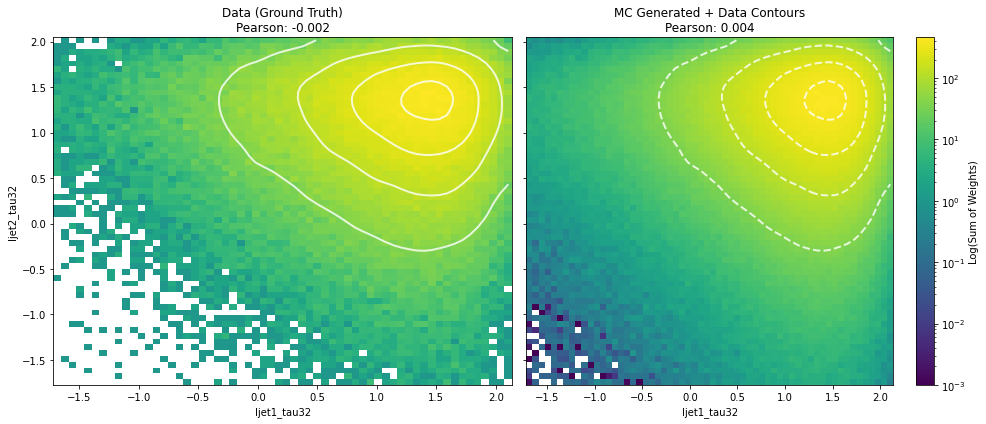

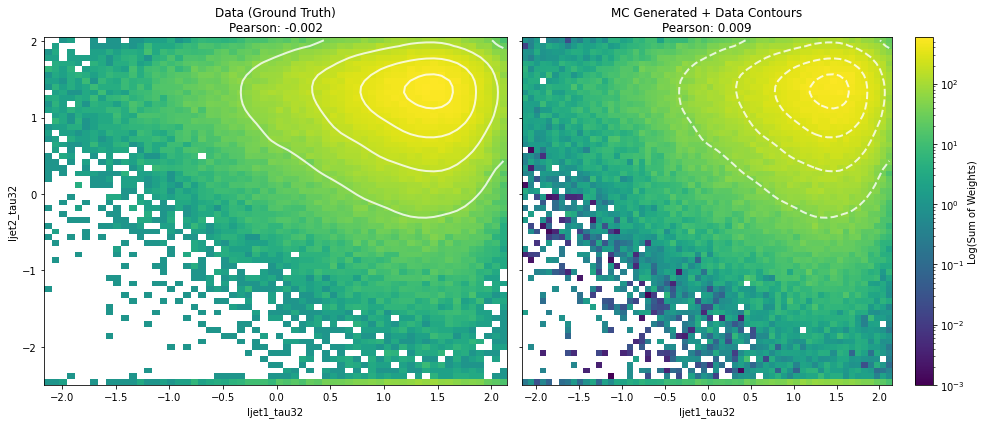

Plotting core contours for ljet1_tau32 vs mjj


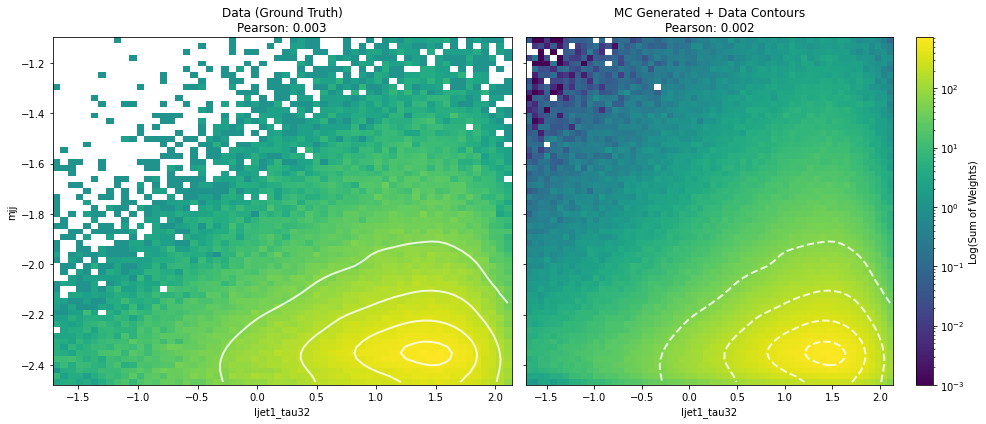

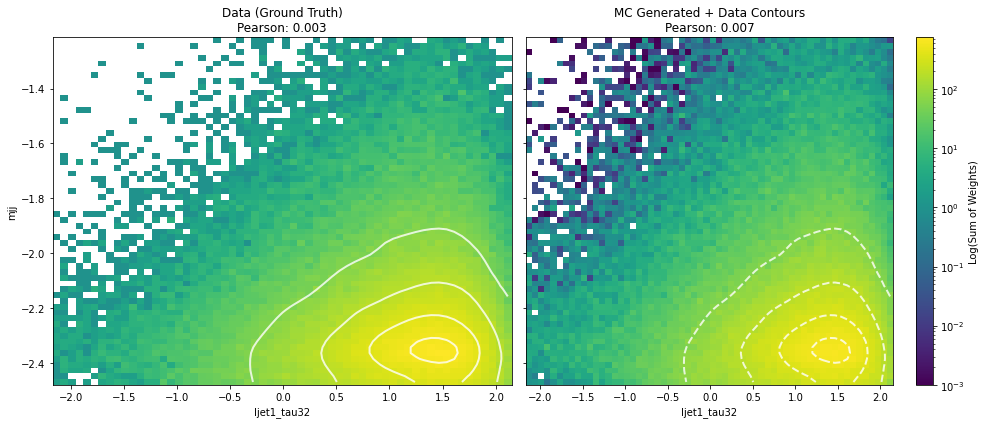

Plotting core contours for ljet2_tau21 vs ljet2_tau32


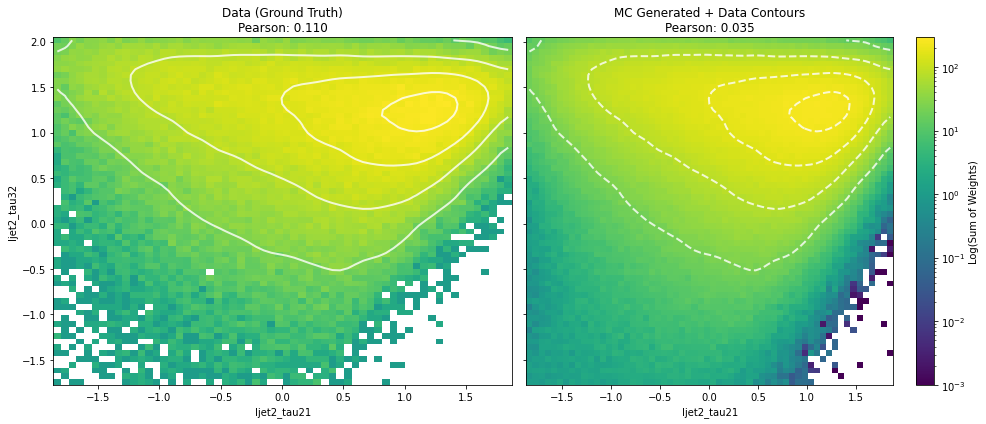

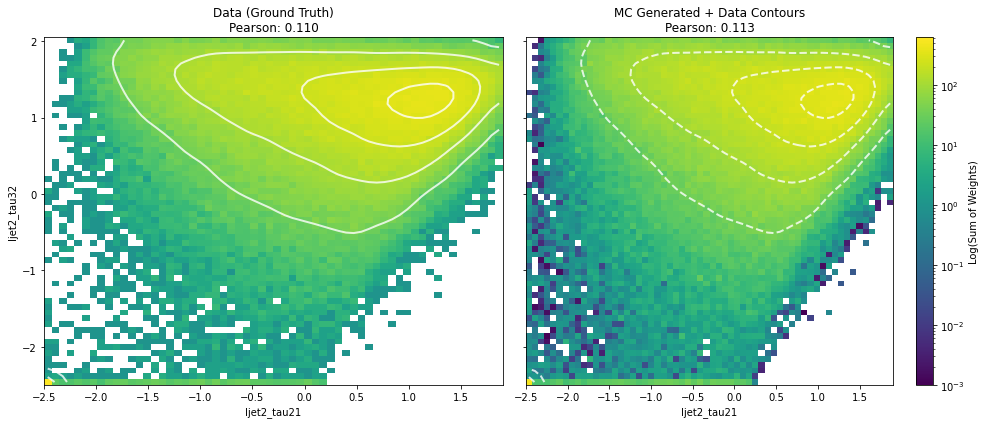

Plotting core contours for ljet2_tau21 vs mjj


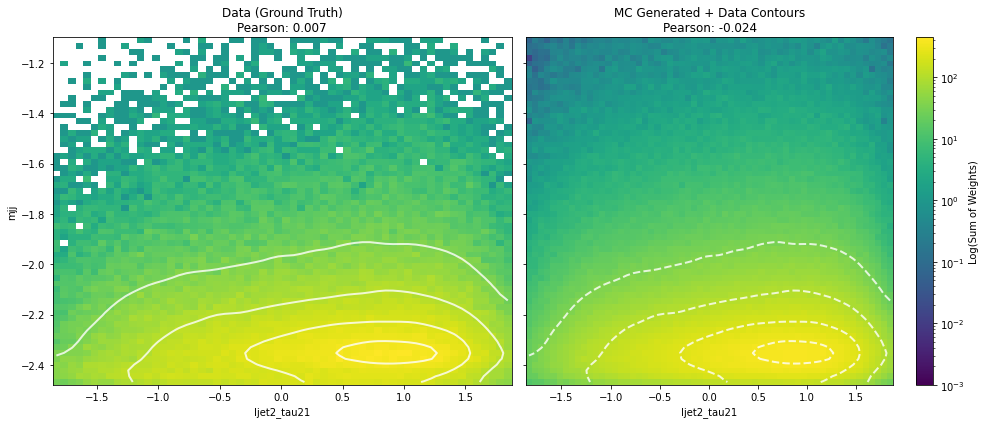

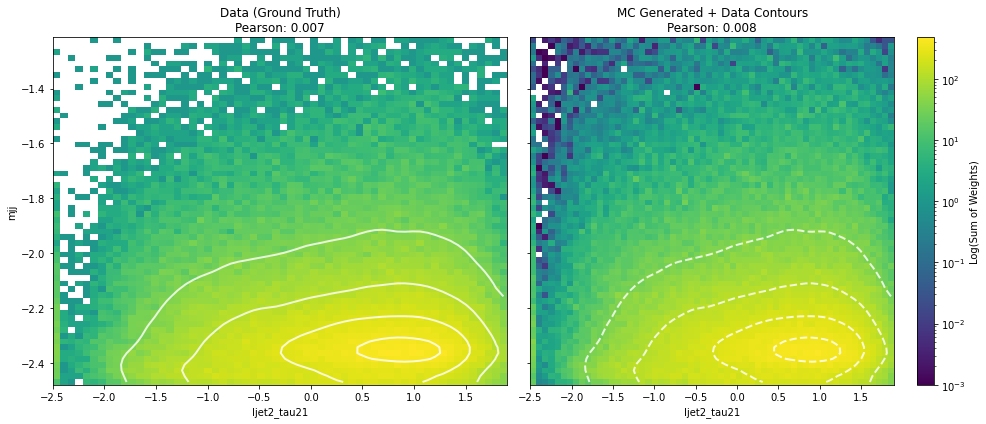

Plotting core contours for ljet2_tau32 vs mjj


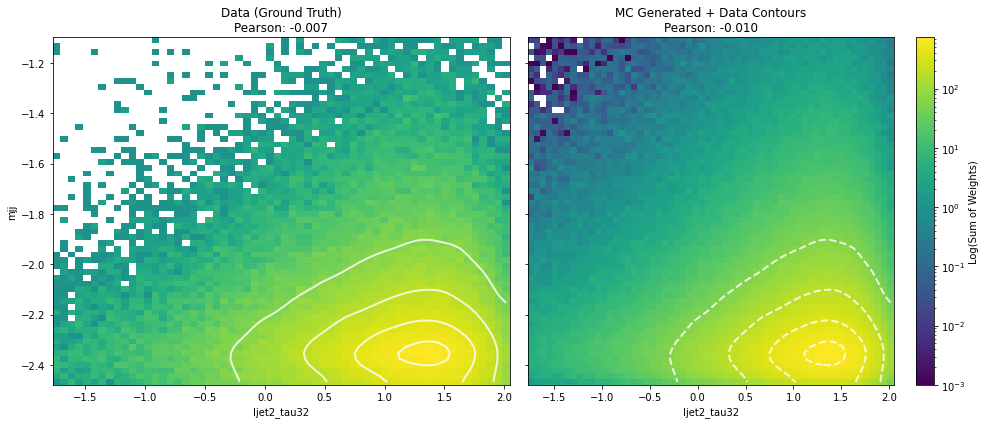

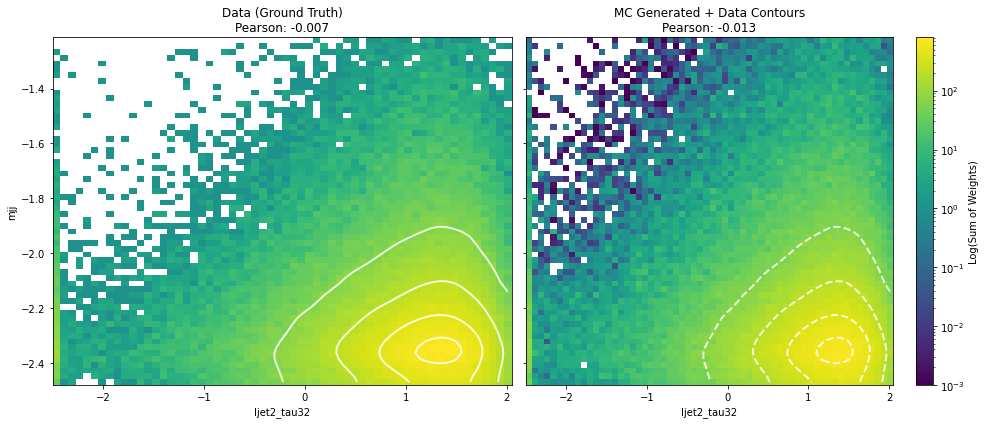

In [ ]:
for var_x, var_y in combinations:
    print(f"Plotting core contours for {var_x} vs {var_y}")
    plot_core_contours(df_data_sr, df_mc_gen_sr, var_x=var_x, var_y=var_y, weight_col_mc=GEN_WEIGHT_COL)
    plot_core_contours(df_data_sr, df_mc_rw_sr, var_x=var_x, var_y=var_y, weight_col_mc=RW_WEIGHT_COL)
# plot_core_contours(df_data_sr, df_mc_gen_sr, var_x='ljet1_tau21', var_y='mjj', weight_col_mc=GEN_WEIGHT_COL)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_conditional_profile(df_data, df_mc, var_x, var_y, weight_col_mc, weight_col_data=None, bins=15):
    """
    Slices var_x into bins and plots the weighted mean and standard deviation 
    of var_y inside each bin to test conditional relationships P(Y|X).
    """
    # Define the bin edges based on the bulk of the data (1st to 99th percentile)
    x_min = min(np.percentile(df_data[var_x], 1), np.percentile(df_mc[var_x], 1))
    x_max = max(np.percentile(df_data[var_x], 99), np.percentile(df_mc[var_x], 99))
    bin_edges = np.linspace(x_min, x_max, bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    def get_profile(df, w_col):
        means = []
        errs = []
        for i in range(bins):
            # Mask events that fall into this specific x-axis bin
            mask = (df[var_x] >= bin_edges[i]) & (df[var_x] < bin_edges[i+1])
            subset = df[mask]
            
            if len(subset) == 0:
                means.append(np.nan)
                errs.append(np.nan)
                continue
                
            y_vals = subset[var_y].values
            weights = subset[w_col].values if w_col else np.ones(len(subset))
            
            if np.sum(weights) == 0:
                means.append(np.nan)
                errs.append(np.nan)
                continue
            
            # Calculate weighted mean and standard deviation of Y in this bin
            mean_y = np.average(y_vals, weights=weights)
            variance = np.average((y_vals - mean_y)**2, weights=weights)
            std_y = np.sqrt(variance)
            
            means.append(mean_y)
            errs.append(std_y) # Plotting standard deviation to show the width of the distribution
            
        return np.array(means), np.array(errs)

    # Calculate profiles
    data_means, data_errs = get_profile(df_data, weight_col_data)
    mc_means, mc_errs = get_profile(df_mc, weight_col_mc)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Data as black points with error bars
    ax.errorbar(bin_centers, data_means, yerr=data_errs, fmt='ko', 
                label='Data (Mean ± Std)', capsize=4, markersize=6, zorder=3)
    
    # Plot MC as a shaded colored band and line
    ax.plot(bin_centers, mc_means, 'g-', label='MC Gen (Mean)', linewidth=2, zorder=2)
    ax.fill_between(bin_centers, mc_means - mc_errs, mc_means + mc_errs, 
                    color='green', alpha=0.2, label='MC Gen (Std Band)', zorder=1)

    ax.set_title(f"Conditional Profile: {var_y} as a function of {var_x}", fontsize=14)
    ax.set_xlabel(f"{var_x} Bins", fontsize=12)
    ax.set_ylabel(f"Average {var_y} inside bin", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Run it on your most important relationship (Mass vs Substructure)

Plotting conditional profile for ljet1_tau21 vs ljet1_tau32


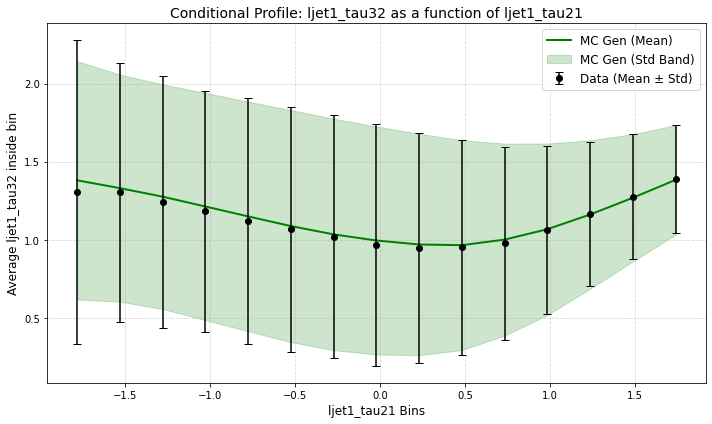

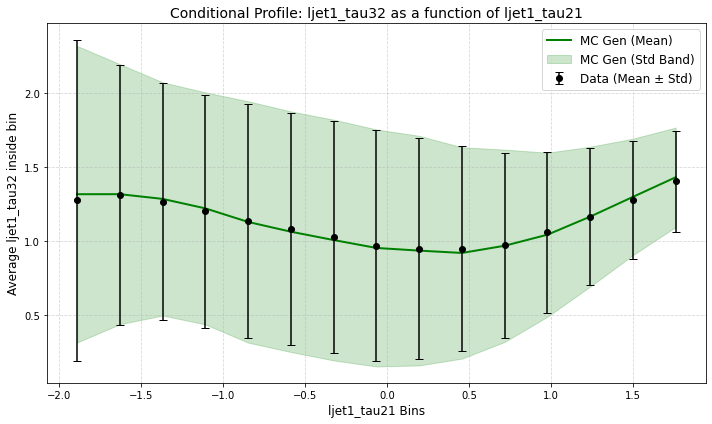

Plotting conditional profile for ljet1_tau21 vs ljet2_tau21


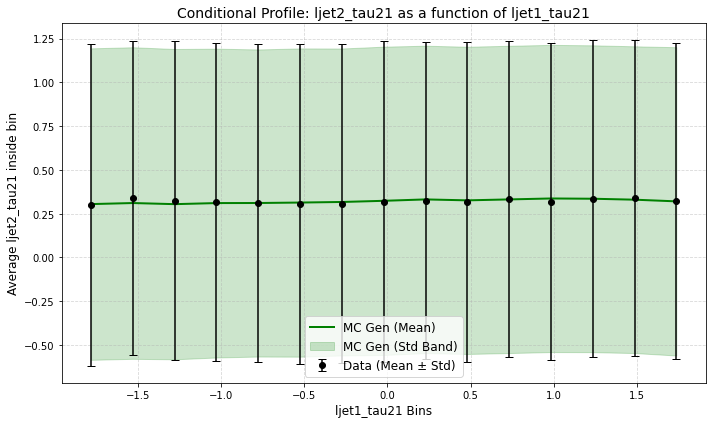

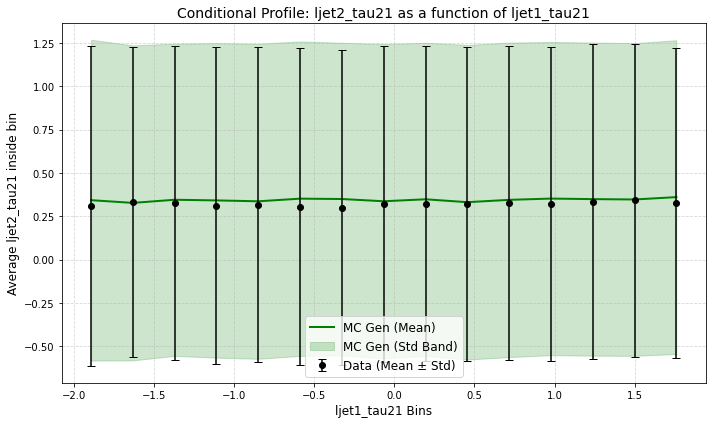

Plotting conditional profile for ljet1_tau21 vs ljet2_tau32


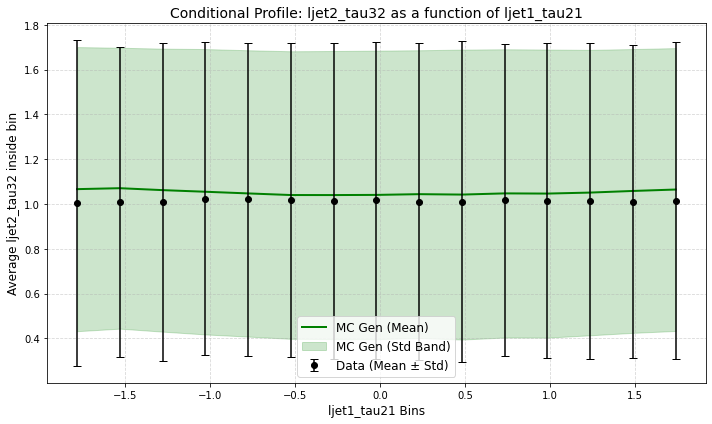

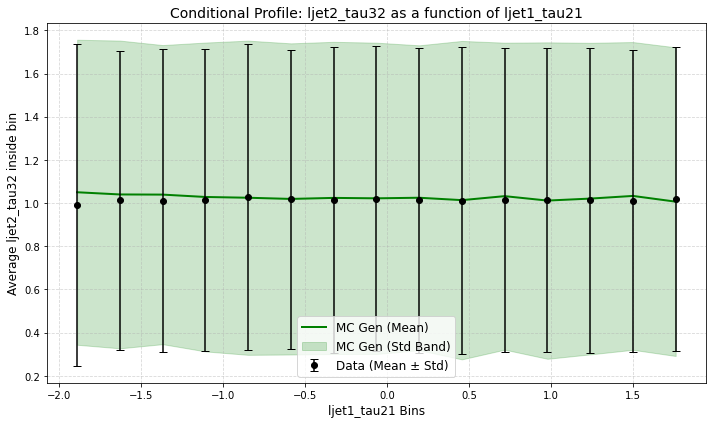

Plotting conditional profile for ljet1_tau21 vs mjj


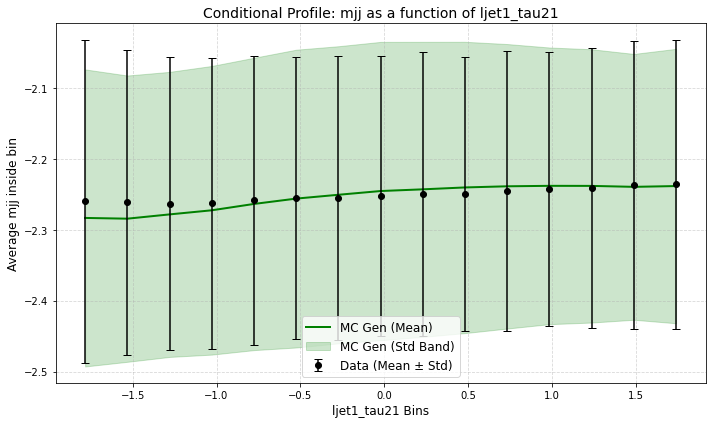

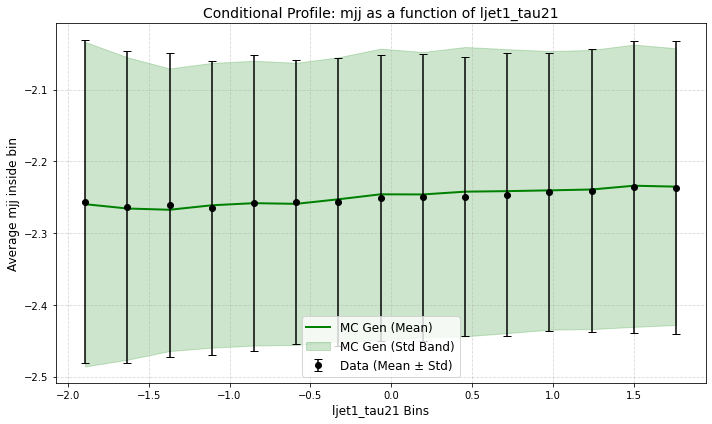

Plotting conditional profile for ljet1_tau32 vs ljet2_tau21


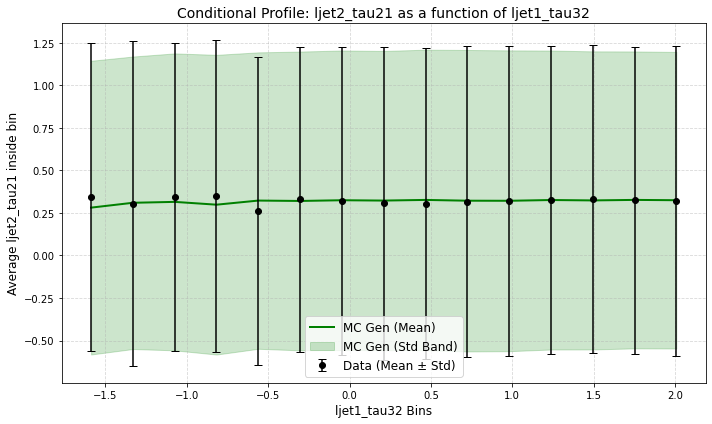

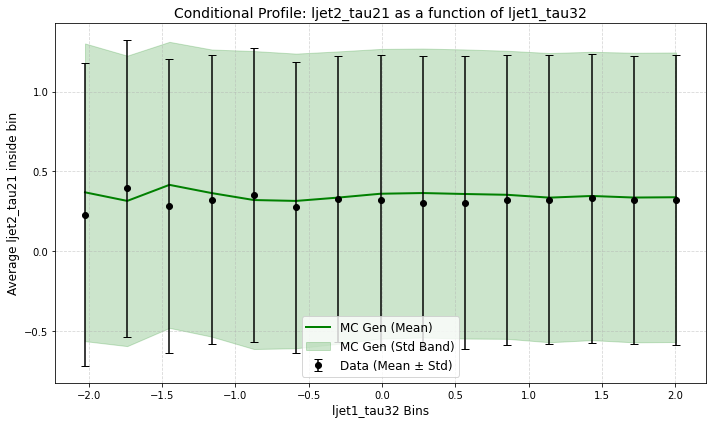

Plotting conditional profile for ljet1_tau32 vs ljet2_tau32


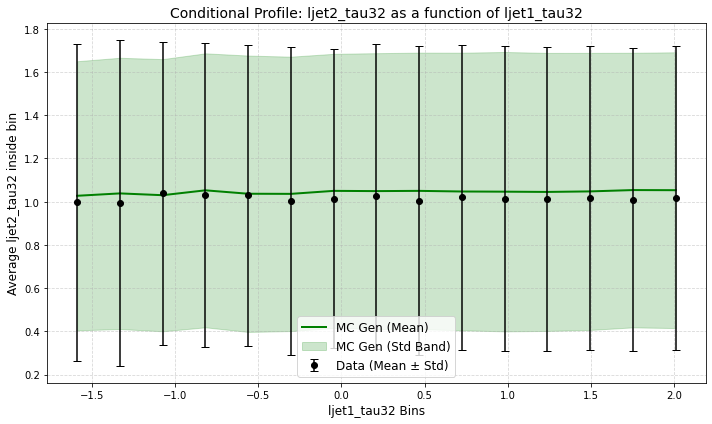

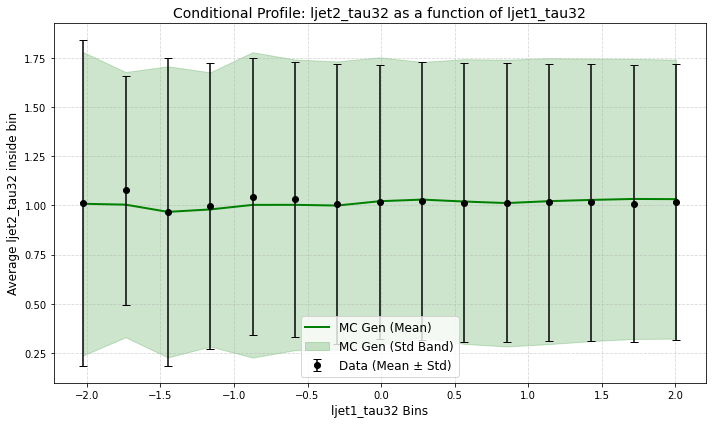

Plotting conditional profile for ljet1_tau32 vs mjj


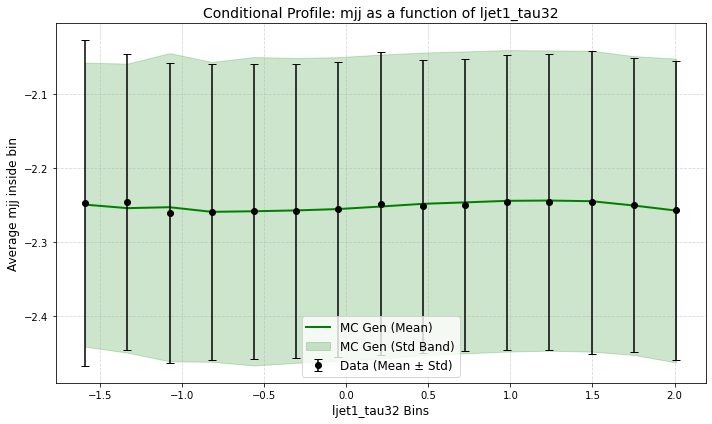

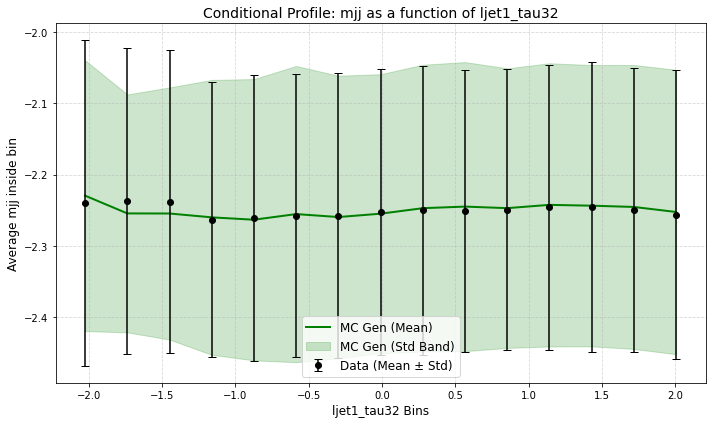

Plotting conditional profile for ljet2_tau21 vs ljet2_tau32


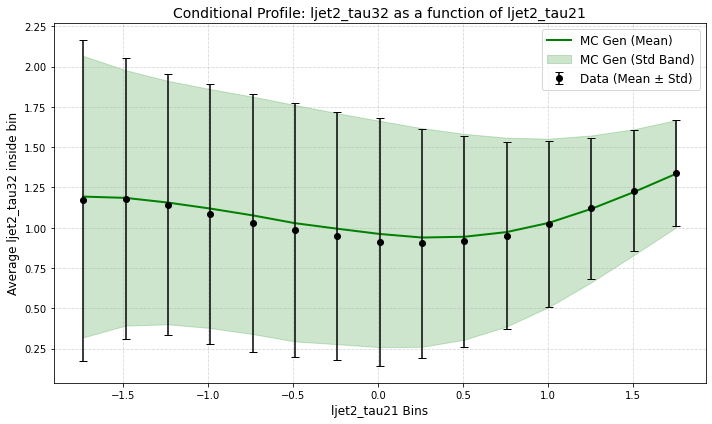

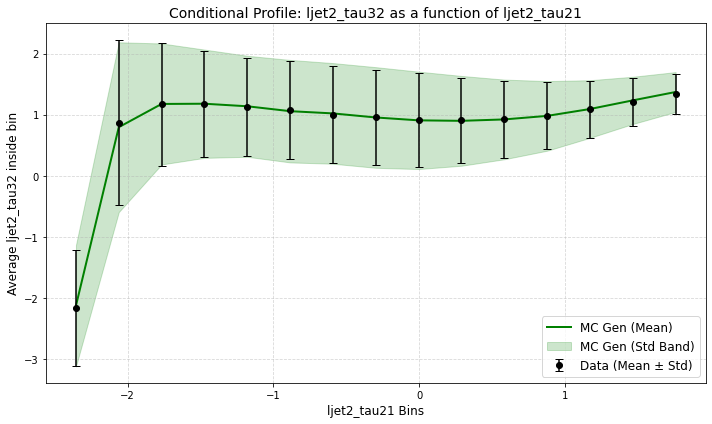

Plotting conditional profile for ljet2_tau21 vs mjj


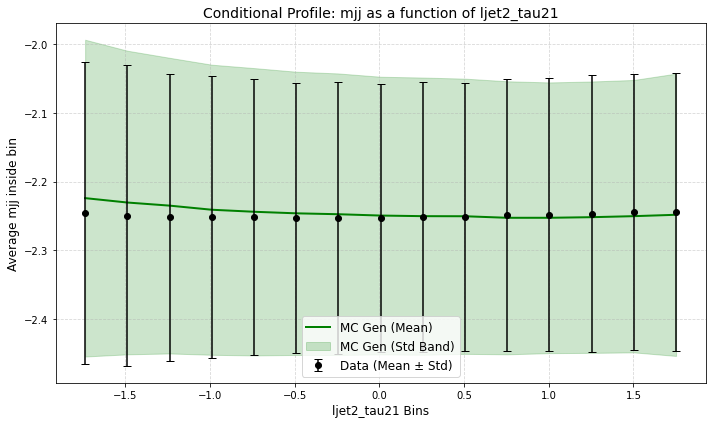

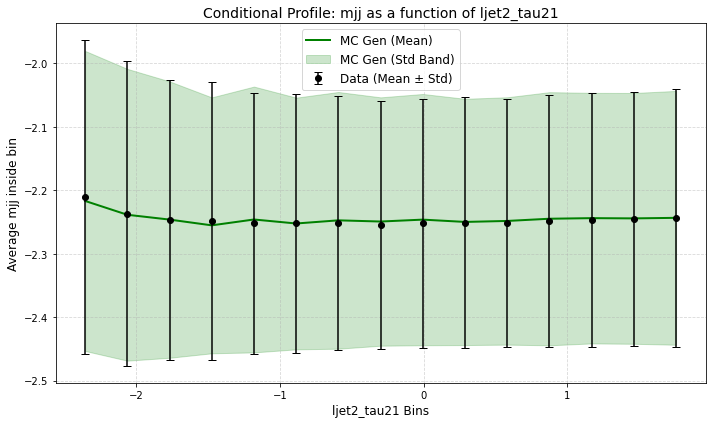

Plotting conditional profile for ljet2_tau32 vs mjj


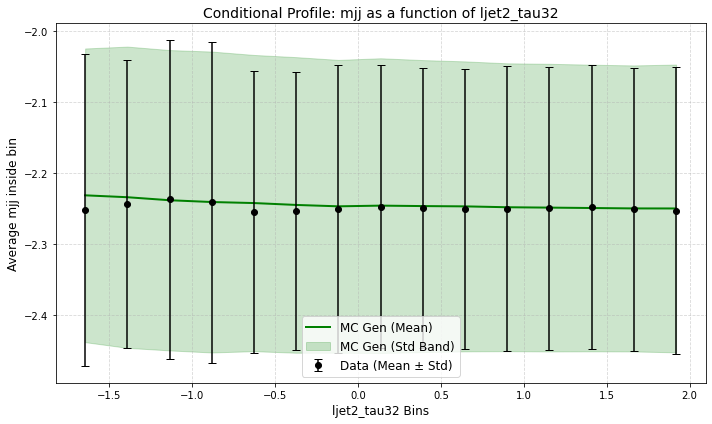

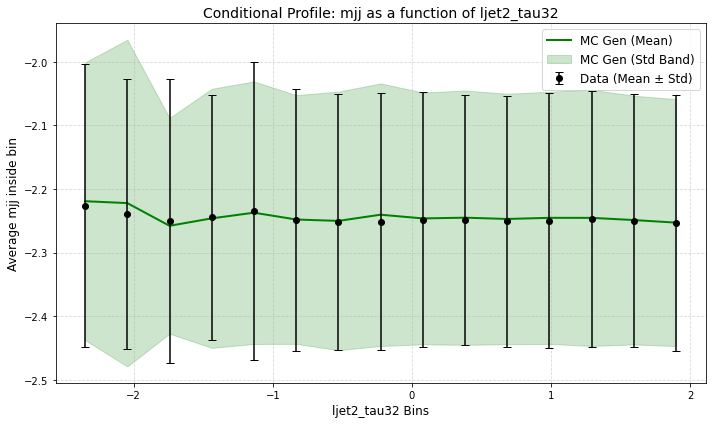

In [ ]:
for var_x, var_y in combinations:
    print(f"Plotting conditional profile for {var_x} vs {var_y}")
    plot_conditional_profile(df_data_sr, df_mc_gen_sr, var_x=var_x, var_y=var_y, weight_col_mc=GEN_WEIGHT_COL)
    plot_conditional_profile(df_data_sr, df_mc_rw_sr, var_x=var_x, var_y=var_y, weight_col_mc=RW_WEIGHT_COL)
# plot_conditional_profile(df_data_sr, df_mc_gen_sr, var_x='mjj', var_y='ljet1_tau32', weight_col_mc=GEN_WEIGHT_COL)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon

def calculate_nsubjettiness_rigor(df_data, df_mc, weight_col_mc, weight_col_data=None, jet_num=1):
    """
    Computes rigorous math/physics metrics to compare N-subjettiness distributions.
    """
    # 1. Extract the raw variables
    t21_col = f'ljet{jet_num}_tau21'
    t32_col = f'ljet{jet_num}_tau32'
    
    t21_data = df_data[t21_col].values
    t32_data = df_data[t32_col].values
    w_data = df_data[weight_col_data].values if weight_col_data else np.ones(len(df_data))
    
    t21_mc = df_mc[t21_col].values
    t32_mc = df_mc[t32_col].values
    w_mc = df_mc[weight_col_mc].values
    
    # ==========================================
    # TEST 1: The Physics-Math Proxy (tau31)
    # tau21 * tau32 = tau3 / tau1
    # ==========================================
    tau31_data = t21_data * t32_data
    tau31_mc = t21_mc * t32_mc
    
    w1_tau31 = signed_wasserstein_distance(tau31_data, tau31_mc, u_weights=w_data, v_weights=w_mc)
    
    # ==========================================
    # TEST 2: The 2D Jensen-Shannon Distance
    # Measures the exact divergence of the joint P(tau21, tau32)
    # ==========================================
    # Create matching 2D grids (bins=40 gives a high-resolution check)
    bins = 40
    edges_21 = np.linspace(0, 1.0, bins+1)
    edges_32 = np.linspace(0, 1.0, bins+1)
    
    hist_data, _, _ = np.histogram2d(t21_data, t32_data, bins=[edges_21, edges_32], weights=w_data)
    hist_mc, _, _ = np.histogram2d(t21_mc, t32_mc, bins=[edges_21, edges_32], weights=w_mc)
    
    # Flatten and normalize to create probability distributions P and Q
    p = hist_data.flatten()
    q = hist_mc.flatten()
    
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    # Calculate JS Distance (Base 2 log is standard for JS)
    js_dist = jensenshannon(p, q, base=2)
    
    print(f"--- Jet {jet_num} N-subjettiness Rigor ---")
    print(f"  Derived Tau31 W1 Distance: {w1_tau31:.5f}")
    print(f"  2D Jensen-Shannon Dist:    {js_dist:.5f}")
    
    return w1_tau31, js_dist

In [ ]:
print("=== Evaluating Reweighter (RW) ===")
rw_w1_j1, rw_js_j1 = calculate_nsubjettiness_rigor(df_data_sr, df_mc_rw_sr, RW_WEIGHT_COL, jet_num=1)
rw_w1_j2, rw_js_j2 = calculate_nsubjettiness_rigor(df_data_sr, df_mc_rw_sr, RW_WEIGHT_COL, jet_num=2)

print("\n=== Evaluating Generator (GEN) ===")
gen_w1_j1, gen_js_j1 = calculate_nsubjettiness_rigor(df_data_sr, df_mc_gen_sr, GEN_WEIGHT_COL, jet_num=1)
gen_w1_j2, gen_js_j2 = calculate_nsubjettiness_rigor(df_data_sr, df_mc_gen_sr, GEN_WEIGHT_COL, jet_num=2)

=== Evaluating Reweighter (RW) ===
--- Jet 1 N-subjettiness Rigor ---
  Derived Tau31 W1 Distance: 0.01397
  2D Jensen-Shannon Dist:    0.15355
--- Jet 2 N-subjettiness Rigor ---
  Derived Tau31 W1 Distance: 0.03359
  2D Jensen-Shannon Dist:    0.14494

=== Evaluating Generator (GEN) ===


--- Jet 1 N-subjettiness Rigor ---
  Derived Tau31 W1 Distance: 0.03244
  2D Jensen-Shannon Dist:    0.11538
--- Jet 2 N-subjettiness Rigor ---
  Derived Tau31 W1 Distance: 0.04572
  2D Jensen-Shannon Dist:    0.10757


In [ ]:
import numpy as np
import pandas as pd

def calculate_weighted_metrics(u_values, v_values, u_weights, v_weights):
    """
    Computes both the 1D Wasserstein distance and Kolmogorov-Smirnov distance
    for weighted datasets using their empirical CDFs.
    """
    # 1. Sort the values and their corresponding weights
    u_sorter = np.argsort(u_values)
    v_sorter = np.argsort(v_values)
    
    u_val_sorted = np.asarray(u_values)[u_sorter]
    v_val_sorted = np.asarray(v_values)[v_sorter]
    u_wt_sorted = np.asarray(u_weights)[u_sorter]
    v_wt_sorted = np.asarray(v_weights)[v_sorter]

    # 2. Combine all unique values to create the integration grid
    all_values = np.concatenate((u_val_sorted, v_val_sorted))
    all_values.sort(kind='mergesort')

    # 3. Compute deltas (dx for the W1 integral)
    deltas = np.diff(all_values)

    # 4. Find the positions to evaluate the CDFs
    u_cdf_indices = np.searchsorted(u_val_sorted, all_values[:-1], side='right')
    v_cdf_indices = np.searchsorted(v_val_sorted, all_values[:-1], side='right')

    # 5. Compute the empirical CDFs
    u_cumweights = np.concatenate(([0], np.cumsum(u_wt_sorted)))
    v_cumweights = np.concatenate(([0], np.cumsum(v_wt_sorted)))

    u_total = u_cumweights[-1]
    v_total = v_cumweights[-1]
    if u_total == 0 or v_total == 0:
        raise ValueError("Total sum of weights cannot be zero.")

    u_cdf = u_cumweights[u_cdf_indices] / u_total
    v_cdf = v_cumweights[v_cdf_indices] / v_total

    # 6. Calculate the absolute difference between the two CDF curves
    cdf_diff = np.abs(u_cdf - v_cdf)

    # W1 is the integral (area between curves)
    w1 = np.sum(cdf_diff * deltas)
    
    # KS is the supremum (maximum vertical distance between curves)
    ks_dist = np.max(cdf_diff)

    return w1, ks_dist

def rank_model_features(df_data, df_mc_rw, df_mc_gen, features, data_weight_col, rw_weight_col, gen_weight_col):
    """
    Evaluates Normalized W1 and KS distance for all features across both models
    and returns a ranked DataFrame.
    """
    results = []
    
    for var in features:
        # Extract Data
        x_data = df_data[var].values
        w_data = df_data[data_weight_col].values if data_weight_col else np.ones(len(df_data))
        
        # Calculate Data Standard Deviation for W1 Normalization
        mean_data = np.average(x_data, weights=w_data)
        std_data = np.sqrt(np.average((x_data - mean_data)**2, weights=w_data))
        
        # Extract MCs
        x_rw = df_mc_rw[var].values
        w_rw = df_mc_rw[rw_weight_col].values
        
        x_gen = df_mc_gen[var].values
        w_gen = df_mc_gen[gen_weight_col].values
        
        # Calculate Metrics
        w1_rw, ks_rw = calculate_weighted_metrics(x_data, x_rw, w_data, w_rw)
        w1_gen, ks_gen = calculate_weighted_metrics(x_data, x_gen, w_data, w_gen)
        
        # Normalize W1
        norm_w1_rw = w1_rw / std_data if std_data > 0 else 0
        norm_w1_gen = w1_gen / std_data if std_data > 0 else 0
        
        results.append({
            'Feature': var,
            'RW_Norm_W1': norm_w1_rw,
            'GEN_Norm_W1': norm_w1_gen,
            'RW_KS_Dist': ks_rw,
            'GEN_KS_Dist': ks_gen
        })
        
    df_results = pd.DataFrame(results)
    
    # Sort the dataframe primarily by the Generator's Normalized W1 error
    df_results = df_results.sort_values(by='GEN_Norm_W1', ascending=False).reset_index(drop=True)
    
    return df_results

# --- EXECUTION ---
all_vars = context_vars + features_vars

# Replace 'None' with your actual data weight column name if you have one
df_rankings = rank_model_features(
    df_data=df_data_sr, 
    df_mc_rw=df_mc_rw_sr, 
    df_mc_gen=df_mc_gen_sr, 
    features=all_vars, 
    data_weight_col=None,  
    rw_weight_col=RW_WEIGHT_COL, 
    gen_weight_col=GEN_WEIGHT_COL
)

print("=== Feature Mismodeling Ranking (Worst to Best) ===")
# Round the numerical columns to 4 decimal places for clean reading
df_clean = df_rankings.round({
    'RW_Norm_W1': 4,
    'GEN_Norm_W1': 4,
    'RW_KS_Dist': 4,
    'GEN_KS_Dist': 4
})

# Display standard dataframe
display(df_clean)

=== Feature Mismodeling Ranking (Worst to Best) ===


AttributeError: The '.style' accessor requires jinja2

In [ ]:
def get_weighted_corr(df, features, weight_col=None, order=1):
    """
    Computes a weighted correlation matrix.
    Supports higher-order polynomial relationships (order=2 for square, order=3 for cubic, etc.).
    """
    X = df[features].values.astype(float)
    w = df[weight_col].values if weight_col else np.ones(len(df))
    
    sum_w = np.sum(w)
    if sum_w == 0:
        raise ValueError("Total sum of weights cannot be exactly zero.")
        
    # # If checking non-linear relationships, apply the polynomial transformation.
    # # We standard-scale first to prevent catastrophic numerical overflow for quartic powers.
    if order != 1:
        X_mean = np.average(X, weights=w, axis=0)
        X_var = np.average((X - X_mean)**2, weights=w, axis=0)
        X_std = np.sqrt(X_var) + 1e-8
        X = ((X - X_mean) / X_std) ** order
        
    # 1. Compute weighted means of the (possibly transformed) features
    mean = np.sum(X * w[:, None], axis=0) / sum_w
    
    # 2. Mean-center the features
    X_centered = X - mean
    
    # 3. Compute the weighted covariance matrix 
    cov_matrix = np.dot(w * X_centered.T, X_centered) / sum_w
    
    # 4. Convert covariance to correlation matrix
    std_devs = np.sqrt(np.diag(cov_matrix))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
        corr_matrix[np.isnan(corr_matrix)] = 0.0
        
    return pd.DataFrame(corr_matrix, index=features, columns=features)


def evaluate_merged_correlations(df_data_cr, df_data_sr, df_mc_cr, df_mc_sr, features, weight_col, order=1):
    """
    Plots a merged correlation matrix: Upper triangle is CR, Lower triangle is SR.
    """
    # 1. Compute all four matrices
    corr_data_cr = get_weighted_corr(df_data_cr, features, weight_col=None, order=order).values
    corr_data_sr = get_weighted_corr(df_data_sr, features, weight_col=None, order=order).values
    
    corr_mc_cr = get_weighted_corr(df_mc_cr, features, weight_col=weight_col, order=order).values
    corr_mc_sr = get_weighted_corr(df_mc_sr, features, weight_col=weight_col, order=order).values
    
    n = len(features)
    
    # 2. Merge Upper (CR) and Lower (SR)
    # np.triu(..., k=1) gets upper triangle excluding diagonal
    # np.tril(..., k=-1) gets lower triangle excluding diagonal
    # np.eye(n) adds the 1.0 self-correlation diagonal back
    merged_data = np.triu(corr_data_cr, k=1) + np.tril(corr_data_sr, k=-1) + np.eye(n)
    merged_mc = np.triu(corr_mc_cr, k=1) + np.tril(corr_mc_sr, k=-1) + np.eye(n)
    
    # Convert back to DataFrame for Seaborn labeling
    df_merged_data = pd.DataFrame(merged_data, index=features, columns=features)
    df_merged_mc = pd.DataFrame(merged_mc, index=features, columns=features)
    
    # 3. Compute Difference Matrix
    df_delta = df_merged_data - df_merged_mc
    
    # 4. Calculate Quantitative Metric (MAE of off-diagonal elements)
    np_delta = df_delta.values
    off_diagonal_mask = ~np.eye(n, dtype=bool)
    mae_diff = np.mean(np.abs(np_delta[off_diagonal_mask]))
    
    # Set naming string
    order_name = {1: "Linear", 2: "Square", 3: "Cubic", 4: "Quartic"}.get(order, f"Order {order}")
    
    print(f"=== {order_name} Joint Distribution Validation (Upper: CR, Lower: SR) ===")
    print(f"Mean Absolute Error of Correlations: {mae_diff:.4f}")
    if mae_diff < 0.05:
        print("Conclusion: Excellent structural fidelity.")
    elif mae_diff < 0.10:
        print("Conclusion: Minor correlation degradation, generally acceptable.")
    else:
        print("Conclusion: WARNING - Severe relationship breakdown detected.")
        
    # 5. Plot Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cmap_std = sns.diverging_palette(220, 20, as_cmap=True)
    
    sns.heatmap(df_merged_data, annot=True, fmt=".2f", cmap=cmap_std, vmin=-1, vmax=1, 
                ax=axes[0], cbar_kws={'label': f'{order_name} Correlation'})
    axes[0].set_title("Data (Upper: CR, Lower: SR)")
    
    sns.heatmap(df_merged_mc, annot=True, fmt=".2f", cmap=cmap_std, vmin=-1, vmax=1, 
                ax=axes[1], cbar_kws={'label': f'{order_name} Correlation'})
    axes[1].set_title("MC (Upper: CR, Lower: SR)")
    
    sns.heatmap(df_delta, annot=True, fmt=".2f", cmap="coolwarm", vmin=-0.3, vmax=0.3, 
                ax=axes[2], cbar_kws={'label': 'Delta (Data - MC)'})
    axes[2].set_title(f"Difference (MAE: {mae_diff:.3f})")
    
    # Draw a diagonal line to clearly separate CR and SR visually
    for ax in axes:
        ax.plot([0, n], [0, n], color='black', lw=2, linestyle='--')
        
    plt.tight_layout()
    plt.show()

=== Linear Joint Distribution Validation (Upper: CR, Lower: SR) ===
Mean Absolute Error of Correlations: 0.0120
Conclusion: Excellent structural fidelity.


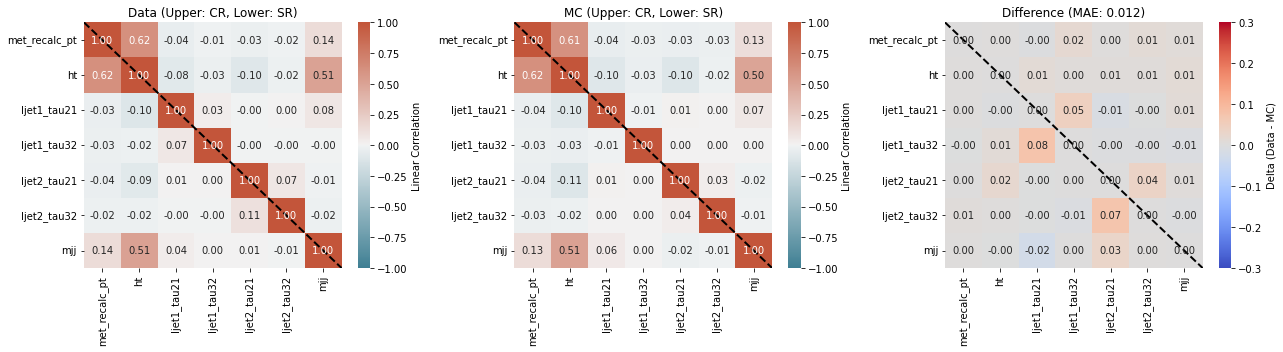

=== Square Joint Distribution Validation (Upper: CR, Lower: SR) ===
Mean Absolute Error of Correlations: 0.0120
Conclusion: Excellent structural fidelity.


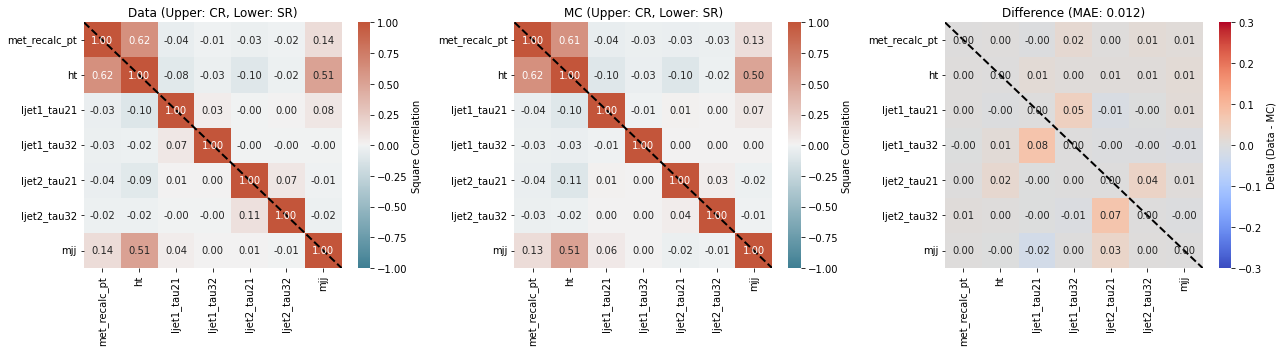

=== Cubic Joint Distribution Validation (Upper: CR, Lower: SR) ===
Mean Absolute Error of Correlations: 0.0120
Conclusion: Excellent structural fidelity.


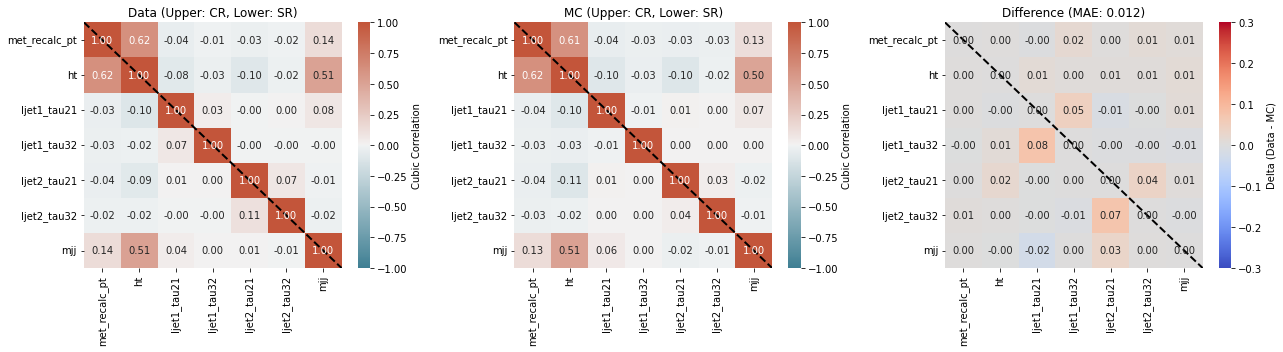

In [ ]:
all_vars = context_vars + features_vars

# Linear correlation (Standard Pearson)
evaluate_merged_correlations(df_data_cr, df_data_sr, df_mc_gen_cr, df_mc_gen_sr, all_vars, GEN_WEIGHT_COL, order=1)

# Square correlation (Checks if Y ~ X^2)
evaluate_merged_correlations(df_data_cr, df_data_sr, df_mc_gen_cr, df_mc_gen_sr, all_vars, GEN_WEIGHT_COL, order=2)

# Cubic correlation (Checks if Y ~ X^3)
evaluate_merged_correlations(df_data_cr, df_data_sr, df_mc_gen_cr, df_mc_gen_sr, all_vars, GEN_WEIGHT_COL, order=3)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_weighted_mutual_information(df, features, weight_col=None, bins=20):
    """
    Computes a Normalized Mutual Information (NMI) matrix using 2D histograms.
    NMI scales the output between 0 (independent) and 1 (perfectly dependent).
    """
    n = len(features)
    mi_matrix = np.zeros((n, n))
    w = df[weight_col].values if weight_col else np.ones(len(df))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                mi_matrix[i, j] = 1.0
                continue
                
            x = df[features[i]].values
            y = df[features[j]].values
            
            # 1. Create a 2D weighted histogram
            # We use bins=20 as a default. For larger datasets, this can be increased.
            hist2d, _, _ = np.histogram2d(x, y, bins=bins, weights=w)
            
            # Physics MC often has negative weights, which can create negative bins.
            # Probabilities cannot be negative, so we clip them to 0.
            hist2d = np.clip(hist2d, a_min=0, a_max=None)
            
            # 2. Convert counts to joint probability distribution P(X, Y)
            sum_hist = np.sum(hist2d)
            if sum_hist == 0:
                continue
            pxy = hist2d / sum_hist
            
            # 3. Get marginal probabilities P(X) and P(Y)
            px = np.sum(pxy, axis=1)
            py = np.sum(pxy, axis=0)
            
            # 4. Calculate Mutual Information: Sum[ P(X,Y) * log(P(X,Y) / (P(X)P(Y))) ]
            # We only compute over non-zero bins to avoid log(0)
            nz = pxy > 0
            pxy_nz = pxy[nz]
            
            # Outer product gives the P(X)P(Y) expectation for independent variables
            px_py_outer = np.outer(px, py)
            px_py_nz = px_py_outer[nz]
            
            mi = np.sum(pxy_nz * np.log(pxy_nz / px_py_nz))
            
            # 5. Normalize the MI so it behaves like a correlation metric [0, 1]
            # We use the geometric mean of entropies: NMI = MI / sqrt(H(X) * H(Y))
            px_nz = px[px > 0]
            hx = -np.sum(px_nz * np.log(px_nz))
            
            py_nz = py[py > 0]
            hy = -np.sum(py_nz * np.log(py_nz))
            
            if hx > 0 and hy > 0:
                nmi = mi / np.sqrt(hx * hy)
            else:
                nmi = 0.0
                
            mi_matrix[i, j] = nmi
            
    return pd.DataFrame(mi_matrix, index=features, columns=features)


def evaluate_merged_mutual_information(df_data_cr, df_data_sr, df_mc_cr, df_mc_sr, features, weight_col, bins=20):
    """
    Plots a merged NMI matrix: Upper triangle is CR, Lower triangle is SR.
    """
    # 1. Compute all four MI matrices
    mi_data_cr = get_weighted_mutual_information(df_data_cr, features, weight_col=None, bins=bins).values
    mi_data_sr = get_weighted_mutual_information(df_data_sr, features, weight_col=None, bins=bins).values
    
    mi_mc_cr = get_weighted_mutual_information(df_mc_cr, features, weight_col=weight_col, bins=bins).values
    mi_mc_sr = get_weighted_mutual_information(df_mc_sr, features, weight_col=weight_col, bins=bins).values
    
    n = len(features)
    
    # 2. Merge Upper (CR) and Lower (SR)
    merged_data = np.triu(mi_data_cr, k=1) + np.tril(mi_data_sr, k=-1) + np.eye(n)
    merged_mc = np.triu(mi_mc_cr, k=1) + np.tril(mi_mc_sr, k=-1) + np.eye(n)
    
    df_merged_data = pd.DataFrame(merged_data, index=features, columns=features)
    df_merged_mc = pd.DataFrame(merged_mc, index=features, columns=features)
    
    # 3. Compute Difference Matrix
    df_delta = df_merged_data - df_merged_mc
    
    # 4. Calculate Quantitative Metric (MAE of off-diagonal elements)
    np_delta = df_delta.values
    off_diagonal_mask = ~np.eye(n, dtype=bool)
    mae_diff = np.mean(np.abs(np_delta[off_diagonal_mask]))
    
    print("=== Mutual Information Joint Validation (Upper: CR, Lower: SR) ===")
    print(f"Mean Absolute Error of NMI: {mae_diff:.4f}")
    if mae_diff < 0.05:
        print("Conclusion: Excellent non-linear structural fidelity.")
    elif mae_diff < 0.10:
        print("Conclusion: Minor dependency degradation, generally acceptable.")
    else:
        print("Conclusion: WARNING - Severe joint probability breakdown detected.")
        
    # 5. Plot Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Use a sequential colormap for Data/MC because NMI is strictly positive [0, 1]
    cmap_seq = "Blues"
    
    sns.heatmap(df_merged_data, annot=True, fmt=".2f", cmap=cmap_seq, vmin=0, vmax=1, 
                ax=axes[0], cbar_kws={'label': 'Normalized MI'})
    axes[0].set_title("Data (Upper: CR, Lower: SR)")
    
    sns.heatmap(df_merged_mc, annot=True, fmt=".2f", cmap=cmap_seq, vmin=0, vmax=1, 
                ax=axes[1], cbar_kws={'label': 'Normalized MI'})
    axes[1].set_title("MC (Upper: CR, Lower: SR)")
    
    # Difference matrix can still be negative, so we keep the diverging colormap
    sns.heatmap(df_delta, annot=True, fmt=".2f", cmap="coolwarm", vmin=-0.3, vmax=0.3, 
                ax=axes[2], cbar_kws={'label': 'Delta (Data - MC)'})
    axes[2].set_title(f"Difference (MAE: {mae_diff:.3f})")
    
    for ax in axes:
        ax.plot([0, n], [0, n], color='black', lw=2, linestyle='--')
        
    plt.tight_layout()
    plt.show()

=== Mutual Information Joint Validation (Upper: CR, Lower: SR) ===
Mean Absolute Error of NMI: 0.0044
Conclusion: Excellent non-linear structural fidelity.


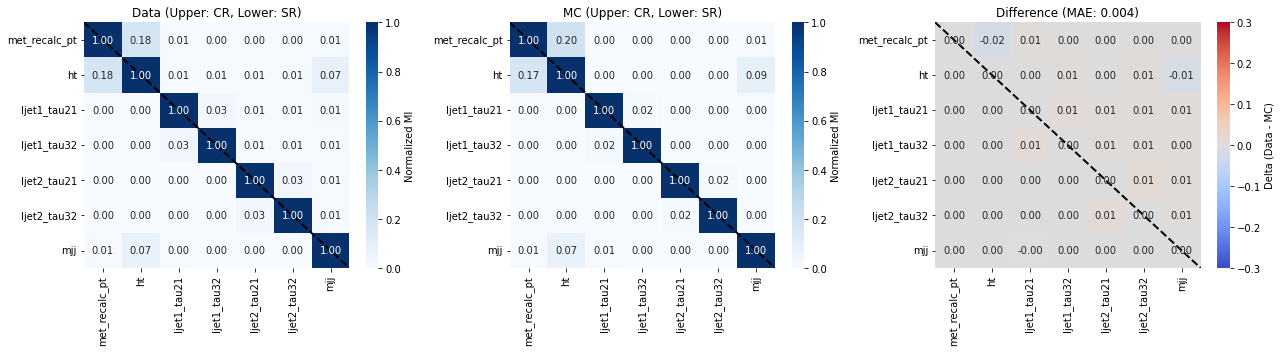

=== Mutual Information Joint Validation (Upper: CR, Lower: SR) ===
Mean Absolute Error of NMI: 0.0022
Conclusion: Excellent non-linear structural fidelity.


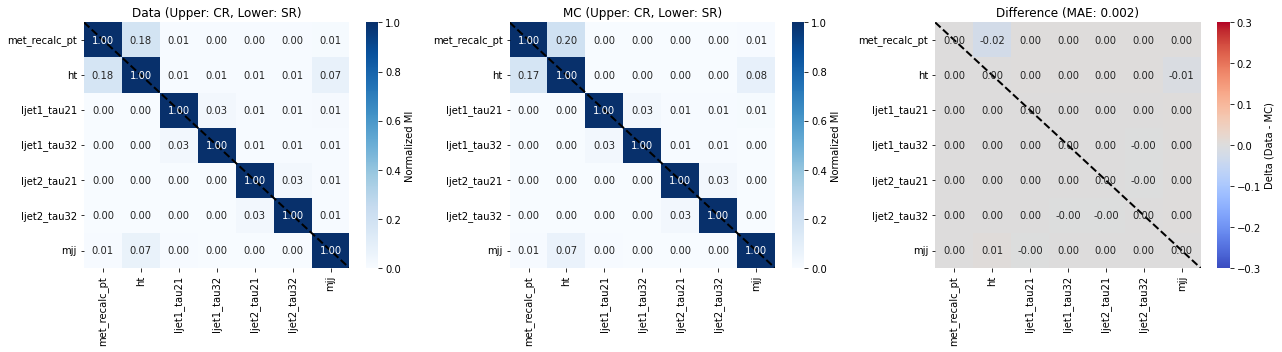

In [ ]:
all_vars = context_vars + features_vars

evaluate_merged_mutual_information(
    df_data_cr, 
    df_data_sr, 
    df_mc_gen_cr, 
    df_mc_gen_sr, 
    all_vars, 
    GEN_WEIGHT_COL, 
    bins=30  # Adjust bins based on your statistics
)

evaluate_merged_mutual_information(
    df_data_cr, 
    df_data_sr, 
    df_mc_rw_cr, 
    df_mc_rw_sr, 
    all_vars, 
    RW_WEIGHT_COL, 
    bins=30  # Adjust bins based on your statistics
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def weighted_pearson_1d(x, y, w):
    """Helper to calculate weighted Pearson correlation for a single pair of variables."""
    mean_x = np.average(x, weights=w)
    mean_y = np.average(y, weights=w)
    cov = np.average((x - mean_x) * (y - mean_y), weights=w)
    var_x = np.average((x - mean_x)**2, weights=w)
    var_y = np.average((y - mean_y)**2, weights=w)
    
    # Protect against zero variance
    if var_x == 0 or var_y == 0:
        return 0.0
    return cov / np.sqrt(var_x * var_y)

def plot_diagnostic_hexbin(df_data, df_mc, var_x, var_y, weight_col_mc, weight_col_data=None, gridsize=50):
    """
    Plots side-by-side hexbins of Data vs MC for a specific variable pair.
    """
    # 1. Extract data
    x_data = df_data[var_x].values
    y_data = df_data[var_y].values
    w_data = df_data[weight_col_data].values if weight_col_data else np.ones(len(df_data))
    
    x_mc = df_mc[var_x].values
    y_mc = df_mc[var_y].values
    w_mc = df_mc[weight_col_mc].values
    
    # 2. Calculate local weighted correlations for the title
    corr_data = weighted_pearson_1d(x_data, y_data, w_data)
    corr_mc = weighted_pearson_1d(x_mc, y_mc, w_mc)
    
    # 3. Determine robust shared axis limits (1st to 99th percentile to ignore extreme outliers)
    # This ensures both plots are on the exact same scale
    x_min = min(np.percentile(x_data, 1), np.percentile(x_mc, 1))
    x_max = max(np.percentile(x_data, 99), np.percentile(x_mc, 99))
    y_min = min(np.percentile(y_data, 1), np.percentile(y_mc, 1))
    y_max = max(np.percentile(y_data, 99), np.percentile(y_mc, 99))
    extent = [x_min, x_max, y_min, y_max]

    # 4. Create Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Common hexbin arguments: 
    # - C handles the weights
    # - reduce_C_function=np.sum sums the weights in each hex
    # - bins='log' is crucial for physics data to see both the core and the tails
    hex_kwargs = {
        'gridsize': gridsize,
        'extent': extent,
        'cmap': 'viridis',
        'mincnt': 1e-5, # Minimum weight to draw a hex
        'reduce_C_function': np.sum,
        'bins': 'log' 
    }
    
    # Plot Data
    hb_data = axes[0].hexbin(x_data, y_data, C=w_data, **hex_kwargs)
    axes[0].set_title(f"Data\nPearson: {corr_data:.3f}")
    axes[0].set_xlabel(var_x)
    axes[0].set_ylabel(var_y)
    fig.colorbar(hb_data, ax=axes[0], label='Log(Sum of Weights)')
    
    # Plot MC
    hb_mc = axes[1].hexbin(x_mc, y_mc, C=w_mc, **hex_kwargs)
    axes[1].set_title(f"MC Generated\nPearson: {corr_mc:.3f}")
    axes[1].set_xlabel(var_x)
    
    # Draw a subtle grid to help compare shapes
    for ax in axes:
        ax.grid(True, linestyle=':', alpha=0.6)
        
    plt.suptitle(f"Diagnostic Check: {var_y} vs {var_x}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

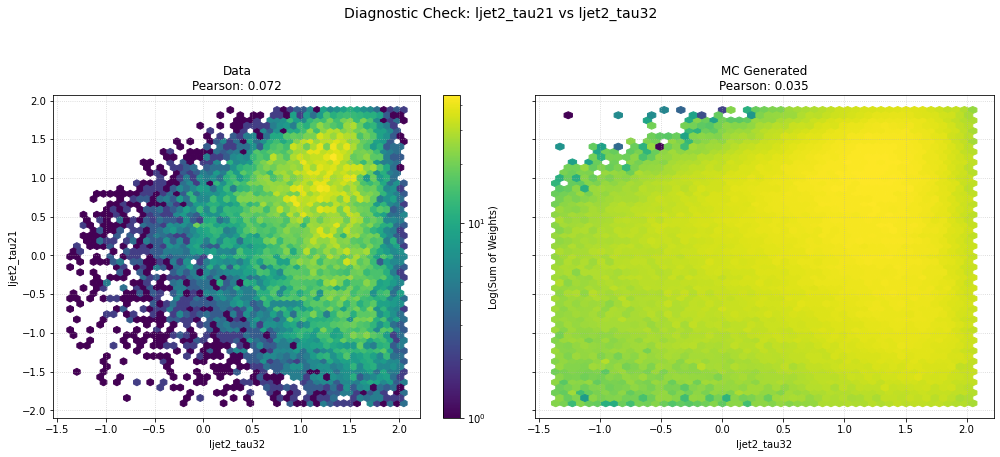

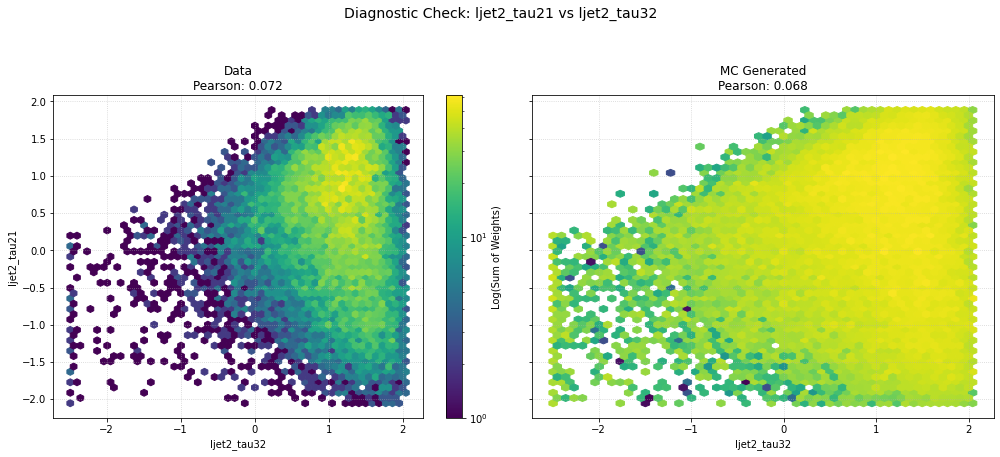

In [ ]:
# Replace 'pt_1' and 'eta_1' with the features causing the discrepancy
plot_diagnostic_hexbin(df_data_cr, df_mc_gen_cr, var_x='ljet2_tau32', var_y='ljet2_tau21', weight_col_mc=GEN_WEIGHT_COL)
plot_diagnostic_hexbin(df_data_cr, df_mc_rw_cr, var_x='ljet2_tau32', var_y='ljet2_tau21', weight_col_mc=RW_WEIGHT_COL)

### CWOLA AUC

In [ ]:
# Load AUC scores
import numpy as np
cr_auc_path = "/home/aegis/aslan/NRAD_Project/NRAD_OpenData/Eval_CWoLa_CR_ATLAS_ver2/auc_scores"
sr_auc_path = "/home/aegis/aslan/NRAD_Project/NRAD_OpenData/Eval_CWoLa_SR_ATLAS_ver2/auc_scores"

nom_auc_cr = np.load(f"{cr_auc_path}/auc_Data_vs_Nom_ATLAS.npz")
rw_auc_cr = np.load(f"{cr_auc_path}/auc_Data_vs_Reweight_ATLAS.npz")
gen_auc_cr = np.load(f"{cr_auc_path}/auc_Data_vs_Generate_ATLAS.npz")

nom_auc_sr = np.load(f"{sr_auc_path}/auc_Data_vs_Nom_ATLAS.npz")
rw_auc_sr = np.load(f"{sr_auc_path}/auc_Data_vs_Reweight_Median_ATLAS.npz")
gen_auc_sr = np.load(f"{sr_auc_path}/auc_Data_vs_Generate_Combined_ATLAS.npz")

In [ ]:
import numpy as np

# =====================================================================
# 1. HELPER FUNCTION
# =====================================================================
def get_auc_stats(npz_path):
    """Extracts the mean and std dev of AUC arrays from the .npz file."""
    try:
        data = np.load(npz_path)
        keys = data.files
        key = "auc_scores" if "auc_scores" in keys else keys[0]
        return np.mean(data[key]), np.std(data[key])
    except Exception as e:
        print(f"Error loading {npz_path}: {e}")
        return 0.5, 0.0 

# =====================================================================
# 2. FILE PATHS
# =====================================================================
cr_path = "/home/aegis/aslan/NRAD_Project/NRAD_OpenData/Eval_CWoLa_CR_ATLAS_ver2/auc_scores"
sr_path = "/home/aegis/aslan/NRAD_Project/NRAD_OpenData/Eval_CWoLa_SR_ATLAS_ver2/auc_scores"

# =====================================================================
# 3. EXTRACT STATISTICS
# =====================================================================
# Control Region (CR)
auc_nom_cr, std_nom_cr = get_auc_stats(f"{cr_path}/auc_Data_vs_Nom_ATLAS.npz")
auc_rw_cr, std_rw_cr   = get_auc_stats(f"{cr_path}/auc_Data_vs_Reweight_Median_ATLAS.npz")
auc_gen_cr, std_gen_cr = get_auc_stats(f"{cr_path}/auc_Data_vs_Generate_Combined_ATLAS.npz")

# Signal Region (SR)
auc_nom_sr, std_nom_sr = get_auc_stats(f"{sr_path}/auc_Data_vs_Nom_ATLAS.npz")
auc_rw_sr, std_rw_sr   = get_auc_stats(f"{sr_path}/auc_Data_vs_Reweight_Median_ATLAS.npz")
auc_gen_sr, std_gen_sr = get_auc_stats(f"{sr_path}/auc_Data_vs_Generate_Combined_ATLAS.npz")

# =====================================================================
# 4. CALCULATE PHYSICS METRICS
# =====================================================================
# Nominal mismodeling gap (how far is nominal from 0.5)
gap_nom_cr = abs(auc_nom_cr - 0.5)
gap_rw_cr  = abs(auc_rw_cr - 0.5)
gap_gen_cr = abs(auc_gen_cr - 0.5)

# Fraction of mismodeling resolved by the ML algorithms
resolved_rw_cr  = 1.0 - (gap_rw_cr / gap_nom_cr)
resolved_gen_cr = 1.0 - (gap_gen_cr / gap_nom_cr)

# Flat systematic shape uncertainty (2 * deviation from 0.5)
sys_unc_rw_cr  = 2.0 * gap_rw_cr
sys_unc_gen_cr = 2.0 * gap_gen_cr

# =====================================================================
# 5. GENERATE THE REPORT
# =====================================================================
print("="*60)
print("              BACKGROUND MODEL VALIDATION REPORT")
print("="*60)
print("\n--- Control Region (CR) Baseline & Closure ---")
print(f"Nominal CR AUC:     {auc_nom_cr:.4f} ± {std_nom_cr:.4f}")
print(f"Reweight CR AUC:    {auc_rw_cr:.4f} ± {std_rw_cr:.4f}")
print(f"Generate CR AUC:    {auc_gen_cr:.4f} ± {std_gen_cr:.4f}")

print("\n--- Resolution of Kinematic Mismodeling ---")
print(f"Reweight Model:     Resolved {resolved_rw_cr:.1%} of baseline mismodeling.")
print(f"Generate Model:     Resolved {resolved_gen_cr:.1%} of baseline mismodeling.")

print("\n--- Derived Systematic Uncertainties ---")
print("Based on residual non-closure (2 * |AUC - 0.5|):")
print(f"Reweight Sys Unc:   {sys_unc_rw_cr:.1%} flat shape uncertainty")
print(f"Generate Sys Unc:   {sys_unc_gen_cr:.1%} flat shape uncertainty")

print("\n--- Signal Region (SR) Evaluation ---")
print(f"Nominal SR AUC:     {auc_nom_sr:.4f} ± {std_nom_sr:.4f}")
print(f"Reweight SR AUC:    {auc_rw_sr:.4f} ± {std_rw_sr:.4f}")
print(f"Generate SR AUC:    {auc_gen_sr:.4f} ± {std_gen_sr:.4f}")
print("="*60)

              BACKGROUND MODEL VALIDATION REPORT

--- Control Region (CR) Baseline & Closure ---
Nominal CR AUC:     0.5561 ± 0.0045
Reweight CR AUC:    0.5166 ± 0.0033
Generate CR AUC:    0.5132 ± 0.0054

--- Resolution of Kinematic Mismodeling ---
Reweight Model:     Resolved 70.5% of baseline mismodeling.
Generate Model:     Resolved 76.4% of baseline mismodeling.

--- Derived Systematic Uncertainties ---
Based on residual non-closure (2 * |AUC - 0.5|):
Reweight Sys Unc:   3.3% flat shape uncertainty
Generate Sys Unc:   2.6% flat shape uncertainty

--- Signal Region (SR) Evaluation ---
Nominal SR AUC:     0.5619 ± 0.0013
Reweight SR AUC:    0.5242 ± 0.0012
Generate SR AUC:    0.5285 ± 0.0016


/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


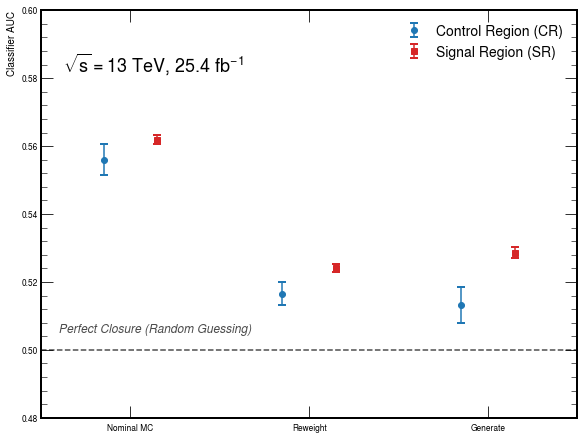

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplhep as hep

# =====================================================================
# 1. PUBLICATION-READY STYLING (The "HEP" Look via mplhep)
# =====================================================================
# This single line handles all the ticks, fonts, and borders perfectly.
hep.style.use(hep.style.ROOT)

# =====================================================================
# 2. DATA EXTRACTION
# =====================================================================
def get_auc_stats(npz_path):
    """Extracts the mean and std dev of AUC arrays from the .npz file."""
    try:
        data = np.load(npz_path)
        keys = data.files
        auc_array = data[keys[0]]
        return np.mean(auc_array), np.std(auc_array)
    except Exception as e:
        print(f"Error loading {npz_path}: {e}")
        # Return dummy data for testing if paths aren't found
        return 0.5, 0.0 

cr_path = "/home/aegis/aslan/NRAD_Project/NRAD_OpenData/Eval_CWoLa_CR_ATLAS_ver2/auc_scores"
sr_path = "/home/aegis/aslan/NRAD_Project/NRAD_OpenData/Eval_CWoLa_SR_ATLAS_ver2/auc_scores"

# Means and Errors for CR
mu_nom_cr, err_nom_cr = get_auc_stats(f"{cr_path}/auc_Data_vs_Nom_ATLAS.npz")
mu_rw_cr, err_rw_cr   = get_auc_stats(f"{cr_path}/auc_Data_vs_Reweight_Median_ATLAS.npz")
mu_gen_cr, err_gen_cr = get_auc_stats(f"{cr_path}/auc_Data_vs_Generate_Combined_ATLAS.npz")

# Means and Errors for SR
mu_nom_sr, err_nom_sr = get_auc_stats(f"{sr_path}/auc_Data_vs_Nom_ATLAS.npz")
mu_rw_sr, err_rw_sr   = get_auc_stats(f"{sr_path}/auc_Data_vs_Reweight_Median_ATLAS.npz")
mu_gen_sr, err_gen_sr = get_auc_stats(f"{sr_path}/auc_Data_vs_Generate_Combined_ATLAS.npz")

# Organize into lists for plotting
means_cr = [mu_nom_cr, mu_rw_cr, mu_gen_cr]
errs_cr  = [err_nom_cr, err_rw_cr, err_gen_cr]

means_sr = [mu_nom_sr, mu_rw_sr, mu_gen_sr]
errs_sr  = [err_nom_sr, err_rw_sr, err_gen_sr]

labels = ["Nominal MC", "Reweight", "Generate"]
x_pos = np.arange(len(labels))

# =====================================================================
# 3. PLOTTING
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# Offset for grouping CR and SR points side-by-side
offset = 0.15 

# Plot CR points (Blue Circles)
ax.errorbar(x_pos - offset, means_cr, yerr=errs_cr, fmt='o', 
            color='tab:blue', capsize=4, capthick=2, 
            label='Control Region (CR)')

# Plot SR points (Red Squares)
ax.errorbar(x_pos + offset, means_sr, yerr=errs_sr, fmt='s', 
            color='tab:red', capsize=4, capthick=2, 
            label='Signal Region (SR)')

# Perfect Closure Baseline
ax.axhline(0.5, linestyle='--', color='black', alpha=0.7, zorder=0)
ax.text(-0.4, 0.505, "Perfect Closure (Random Guessing)", 
        fontsize=12, style='italic', color='black', alpha=0.7)

# =====================================================================
# 4. HEP TEXT LABELS AND AESTHETICS
# =====================================================================
# Customize Axes
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel("Classifier AUC")
ax.set_ylim(0.48, 0.6) # Adjust this depending on your max nominal AUC
ax.set_xlim(-0.5, len(labels) - 0.5)

# Minor ticks for Y-axis only (X-axis is categorical)
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))

# Context Text Anchor (Energy and Luminosity)
ax.text(0.04, 0.85, "$\\sqrt{s} = 13$ TeV, $25.4$ fb$^{-1}$", 
        transform=ax.transAxes, fontsize=18)

# Legend positioning
ax.legend(loc='upper right', frameon=False, fontsize=14)

# Save the figure as a high-res PDF for the paper
plt.savefig("Results/AUC_results.pdf", format='pdf', dpi=300)
plt.show()